# Triagegeist: Auditing What the Triage Number Misses

Emergency department triage assigns an **acuity** number that indicates how urgently a patient should be seen. However, the triage number does not fully answer a different operational question: **what is likely to happen after triage?** A patient may share the same acuity category as many others, yet still differ substantially in their likelihood of admission, transfer, or prolonged ED stay.

Triagegeist investigates whether triage-time features provide outcome-relevant information beyond the assigned acuity label. Rather than treating the model as a deployed clinical system, this notebook frames the work as a **benchmark audit**: it tests whether the hackathon’s synthetic emergency department dataset preserves the same residual risk signal observed in real emergency department data.

The analysis applies one consistent modelling protocol to three datasets:

* the hackathon synthetic emergency department dataset;
* **NHAMCS 2022**, using IMMEDR as the closest available acuity analogue;
* **MIMIC-IV-ED**, processed locally under credentialed PhysioNet access.

The project focuses on two clinically and operationally relevant outcomes: **admission/transfer risk** and **long ED stay risk**, defined as length of stay of at least four hours. The central question is not only whether a model can predict these outcomes, but whether it adds meaningful signal beyond acuity-only baselines and whether that signal remains visible within middle-acuity groups such as ESI 3 and ESI 4.

**Author:** Ella Afonso

**Competition:** [Triagegeist (Kaggle)](https://kaggle.com/competitions/triagegeist) - Laitinen-Fredriksson Foundation hackathon, rubric-judged.

**Reproducibility:** Seeds are locked (`SEED = 42`) across `random`, `numpy`, and `PYTHONHASHSEED` via `src/config.py::seed_everything()`. Package versions are printed in Section 0 below. The notebook auto-detects Kaggle versus local execution and is designed to run end-to-end with zero errors.

---

## Submission notebook - reading guide

This is the judge-facing submission notebook. It mirrors the original working notebook (`triagegeist_main.ipynb`) but presents the analysis with clearer wording, polished figures loaded from `outputs/figures/`, aggregate tables from `outputs/tables/`, and a cleaner narrative for review.

The notebook should be read as a reproducible benchmark audit rather than as a clinical deployment demonstration. It first establishes baseline performance on the synthetic dataset, then tests whether the same conclusion replicates on NHAMCS 2022 and MIMIC-IV-ED. This structure allows the synthetic benchmark result to be compared against real-data evidence rather than interpreted in isolation.

**Implementation note.** Some internal Python variable names, such as `is_admitted`, `is_long_stay`, and `MODELS["adm"]`, are retained to preserve reproducibility and traceability. However, judge-facing markdown, figure titles, axis labels, and legends use clinical-outcome wording such as **admission/transfer** and **long ED stay**.

**Scope of claims.** The results provide evidence about benchmark behaviour and residual outcome signal in retrospective data. They do not constitute a clinically validated system. Triagegeist is not intended for patient care without prospective validation, local governance review, safety testing, and clinician oversight.


---
## Section 0 - Environment & Reproducibility

This section establishes the notebook environment before any modelling begins. It imports the required libraries, locks random seeds, configures display settings, reports package versions, detects whether the notebook is running on Kaggle or locally, and defines key constants used throughout the analysis.

This step is included to make the workflow reproducible and easier to audit. All downstream results should be traceable to the same environment, paths, and seed configuration.




In [1]:
import os
import sys
import json
import importlib.metadata as ilmd

import numpy as np
import pandas as pd
import sklearn
import lightgbm
import shap
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns


# --- Locate the project root (folder containing src/), add to path, and (when
# running locally) chdir into it so config's relative paths resolve regardless of
# where the kernel was launched. On Kaggle, paths are absolute so chdir is skipped. ---
def _find_repo_root():
    try:
        here = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        here = os.getcwd()
    candidates = [
        os.path.abspath(os.path.join(here, "..")),  # notebooks/ -> repo root
        here,
        os.getcwd(),
        os.path.abspath(os.path.join(os.getcwd(), "..")),
    ]
    for c in candidates:
        if os.path.isdir(os.path.join(c, "src")):
            return c
    return os.getcwd()


REPO_ROOT = _find_repo_root()
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
if not os.path.isdir("/kaggle/input"):
    os.chdir(REPO_ROOT)

from src import config
from src.config import seed_everything

# --- Lock all randomness ---
seed_everything(config.SEED)

# --- Display settings ---
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")
%matplotlib inline

# --- Path detection (Kaggle vs local) ---
print(f"Environment : {'Kaggle' if config.ON_KAGGLE else 'local'}")
print(f"DATA_DIR    : {config.DATA_DIR}")
print(f"OUT_DIR     : {config.OUT_DIR}")
print(f"DATA_NHAMCS : {config.DATA_NHAMCS}")

# --- Package versions vs required minimums ---
print("\nReproducibility - installed vs required (min) versions:")
print(f"  {'python':<14} {sys.version.split()[0]}")
for pkg, min_ver in config.REQUIRED_PACKAGES.items():
    try:
        installed = ilmd.version(pkg)
    except ilmd.PackageNotFoundError:
        installed = "NOT FOUND"
    print(f"  {pkg:<14} {installed:<12} (>= {min_ver})")

# --- Key constants ---
print("\nKey constants:")
print(f"  SEED                  = {config.SEED}")
print(f"  HOLDOUT_FRAC          = {config.HOLDOUT_FRAC}")
print(f"  CV_FOLDS              = {config.CV_FOLDS}")
print(f"  LONG_STAY_THRESHOLD_H = {config.LONG_STAY_THRESHOLD_H}")
print(f"  LEAKAGE_COLS          = {config.LEAKAGE_COLS}")
print(f"  MISSINGNESS_TRAP_COLS = {config.MISSINGNESS_TRAP_COLS}")

# --- Writable output directories (portable across Kaggle/local) ---
FIG_DIR = os.path.join(config.OUT_DIR, "figures")
TABLE_DIR = os.path.join(config.OUT_DIR, "tables")
PROCESSED_DIR = os.path.join("/kaggle/working" if config.ON_KAGGLE else "./data", "processed")
for _d in (FIG_DIR, TABLE_DIR, PROCESSED_DIR):
    os.makedirs(_d, exist_ok=True)
print(f"\nFIG_DIR       : {FIG_DIR}")
print(f"TABLE_DIR     : {TABLE_DIR}")
print(f"PROCESSED_DIR : {PROCESSED_DIR}")


Environment : local
DATA_DIR    : ./data/raw
OUT_DIR     : ./outputs
DATA_NHAMCS : ./data/nhamcs

Reproducibility - installed vs required (min) versions:
  python         3.13.5
  pandas         2.2.3        (>= 2.0)
  numpy          2.1.3        (>= 1.24)
  scikit-learn   1.6.1        (>= 1.3)
  lightgbm       4.6.0        (>= 4.0)
  shap           0.51.0       (>= 0.42)
  matplotlib     3.10.0       (>= 3.7)
  seaborn        0.13.2       (>= 0.12)

Key constants:
  SEED                  = 42
  HOLDOUT_FRAC          = 0.2
  CV_FOLDS              = 5
  LONG_STAY_THRESHOLD_H = 4.0
  LEAKAGE_COLS          = ['triage_acuity', 'disposition', 'ed_los_hours', 'is_admitted', 'is_long_stay', 'is_lwbs', 'is_lama']
  MISSINGNESS_TRAP_COLS = ['systolic_bp', 'respiratory_rate', 'pain_score']

FIG_DIR       : ./outputs\figures
TABLE_DIR     : ./outputs\tables
PROCESSED_DIR : ./data\processed


---

## Section 1 - Data Loading & Joining

This section loads the five competition CSV files and joins the auxiliary tables onto the main `train` and `test` datasets using `patient_id`. A join-integrity report is printed to verify row counts, missingness patterns, and whether the merge behaved as expected.

No preprocessing is fitted at this stage. The purpose of this section is limited to loading, joining, and inspecting the raw competition data before any modelling or feature transformation is introduced.



In [2]:
# --- Load the five competition CSVs from DATA_DIR ---
def _path(name):
    return os.path.join(config.DATA_DIR, name)

train = pd.read_csv(_path("train.csv"))
test = pd.read_csv(_path("test.csv"))
chief_complaints = pd.read_csv(_path("chief_complaints.csv"))
patient_history = pd.read_csv(_path("patient_history.csv"))
sample_submission = pd.read_csv(_path("sample_submission.csv"))

print("Raw shapes:")
for _nm, _df in [("train", train), ("test", test), ("chief_complaints", chief_complaints),
                 ("patient_history", patient_history), ("sample_submission", sample_submission)]:
    print(f"  {_nm:<18} {_df.shape}")

# --- Duplicate patient_id check (before merging) ---
print("\nDuplicate patient_id counts (expect 0 everywhere):")
for _nm, _df in [("train", train), ("test", test),
                 ("chief_complaints", chief_complaints), ("patient_history", patient_history)]:
    print(f"  {_nm:<18} {int(_df['patient_id'].duplicated().sum())}")

# --- Coverage: every train/test id must exist in complaints and history ---
def _missing(base, other):
    return int((~base["patient_id"].isin(other["patient_id"])).sum())

print("\nCoverage (expect missing=0 everywhere):")
_cov = 0
for _label, _base, _other in [
    ("train ids in chief_complaints", train, chief_complaints),
    ("train ids in patient_history", train, patient_history),
    ("test ids in chief_complaints", test, chief_complaints),
    ("test ids in patient_history", test, patient_history),
]:
    _m = _missing(_base, _other)
    print(f"  {_label:<34} missing={_m}")
    _cov += _m
assert _cov == 0, "Some patient_ids are missing from complaints/history - investigate before joining."

# --- Collision handling: chief_complaint_system exists in BOTH train/test and
# chief_complaints.csv. We keep the value from chief_complaints (the dedicated
# complaint file is the authoritative source) and drop the train/test copy so
# pandas does not create _x/_y suffixes. ---
DUP_COL = "chief_complaint_system"

def join_all(base, label):
    n0 = len(base)
    b = base.drop(columns=[DUP_COL]) if DUP_COL in base.columns else base
    step1 = b.merge(chief_complaints, on="patient_id", how="left", validate="one_to_one")
    assert len(step1) == n0, f"{label}: row count changed on chief_complaints join ({n0}->{len(step1)})"
    step2 = step1.merge(patient_history, on="patient_id", how="left", validate="one_to_one")
    assert len(step2) == n0, f"{label}: row count changed on patient_history join ({n0}->{len(step2)})"
    print(f"  {label:<11}: {n0} -> after cc {len(step1)} -> after ph {len(step2)}")
    return step2

print("\nJoin integrity (row counts must NOT change):")
train_full = join_all(train, "train_full")
test_full = join_all(test, "test_full")

print(f"\ntrain_full shape: {train_full.shape}")
print(f"test_full  shape: {test_full.shape}")
print(f"Collision handled: kept `{DUP_COL}` from chief_complaints.csv; dropped the train/test copy.")

# --- Schema audit: train_full vs test_full ---
_tr, _te = set(train_full.columns), set(test_full.columns)
only_train = sorted(_tr - _te)
only_test = sorted(_te - _tr)
shared = sorted(_tr & _te)
target_only = [c for c in only_train
               if c in (config.TARGET_ACUITY, config.TARGET_DISPOSITION, config.TARGET_LOS)]
print("\nSchema audit:")
print(f"  columns only in train_full ({len(only_train)}): {only_train}")
print(f"  columns only in test_full  ({len(only_test)}): {only_test}")
print(f"  shared candidate columns   ({len(shared)})")
print(f"  target columns present only in train: {target_only}")


Raw shapes:
  train              (80000, 40)
  test               (20000, 37)
  chief_complaints   (100000, 3)
  patient_history    (100000, 26)
  sample_submission  (20000, 2)

Duplicate patient_id counts (expect 0 everywhere):
  train              0
  test               0
  chief_complaints   0
  patient_history    0

Coverage (expect missing=0 everywhere):
  train ids in chief_complaints      missing=0
  train ids in patient_history       missing=0
  test ids in chief_complaints       missing=0
  test ids in patient_history        missing=0

Join integrity (row counts must NOT change):
  train_full : 80000 -> after cc 80000 -> after ph 80000
  test_full  : 20000 -> after cc 20000 -> after ph 20000

train_full shape: (80000, 66)
test_full  shape: (20000, 63)
Collision handled: kept `chief_complaint_system` from chief_complaints.csv; dropped the train/test copy.

Schema audit:
  columns only in train_full (3): ['disposition', 'ed_los_hours', 'triage_acuity']
  columns only in test_ful

---

## Section 2 - Targeted EDA, Data Verification & Derived Targets

This section performs targeted exploratory data analysis and verifies key dataset assumptions before modelling. It normalises `disposition`, derives the binary outcome targets, checks documented dataset facts, and produces publication-clean summary figures.

Derived outcome targets are computed only on the outcome-bearing training data (`train_full`). They are never created on `test_full`, because the test set does not contain the observed outcomes required for supervised evaluation. This keeps the exploratory and target-engineering steps aligned with the competition data structure.

In [3]:
# --- Normalise disposition before deriving targets ---
train_full[config.TARGET_DISPOSITION] = (
    train_full[config.TARGET_DISPOSITION].astype(str).str.strip().str.lower()
)
_disp_values = sorted(train_full[config.TARGET_DISPOSITION].unique())
print("Disposition unique values:", _disp_values)

EXPECTED_DISPOSITIONS = {
    "admitted", "transferred", "discharged", "observation", "lwbs", "lama", "deceased",
}
_unexpected = set(_disp_values) - EXPECTED_DISPOSITIONS
if _unexpected:
    print("WARNING - unexpected disposition categories:", sorted(_unexpected))
else:
    print("All disposition categories are expected.")

# --- Derive the four binary targets on train_full ---
# is_admitted: 'observation' is deliberately EXCLUDED - it is a short-stay hold/obs
# decision, not an inpatient admission decision, so counting it would overstate the
# admission outcome we want clinicians to prepare for. (writeup note)
_disp = train_full[config.TARGET_DISPOSITION]
train_full[config.TARGET_ADMIT] = _disp.isin(["admitted", "transferred"]).astype(int)
train_full[config.TARGET_LONG_STAY] = (
    train_full[config.TARGET_LOS] >= config.LONG_STAY_THRESHOLD_H
).astype(int)
train_full[config.TARGET_LWBS] = (_disp == "lwbs").astype(int)
train_full[config.TARGET_LAMA] = (_disp == "lama").astype(int)

# --- Base rates ---
_targets = [config.TARGET_ADMIT, config.TARGET_LONG_STAY, config.TARGET_LWBS, config.TARGET_LAMA]
base_rates = pd.DataFrame(
    {"target": _targets, "base_rate": [round(float(train_full[t].mean()), 4) for t in _targets]}
)
print("\nDerived-target base rates (is_admitted expected ~0.37):")
print(base_rates.to_string(index=False))
base_rates.to_csv(os.path.join(TABLE_DIR, "table_target_base_rates.csv"), index=False)


Disposition unique values: ['admitted', 'deceased', 'discharged', 'lama', 'lwbs', 'observation', 'transferred']
All disposition categories are expected.

Derived-target base rates (is_admitted expected ~0.37):
      target  base_rate
 is_admitted     0.3725
is_long_stay     0.3568
     is_lwbs     0.0457
     is_lama     0.0345


In [4]:
# --- Data-fact verification tables ---

# (a) triage_acuity distribution (expect ~ 4 / 17 / 36 / 29 / 14 %)
acuity_dist = (
    train_full[config.TARGET_ACUITY].value_counts(normalize=True).sort_index()
    .mul(100).round(1).rename("pct").reset_index()
)
acuity_dist.columns = ["triage_acuity", "pct"]

# (b) disposition distribution
disp_dist = (
    train_full[config.TARGET_DISPOSITION].value_counts(normalize=True)
    .mul(100).round(1).rename("pct").reset_index()
)
disp_dist.columns = ["disposition", "pct"]

# (c) median ed_los_hours by acuity (expect ~ 8 / 6 / 4 / 2 / 1)
median_los = (
    train_full.groupby(config.TARGET_ACUITY)[config.TARGET_LOS].median()
    .round(2).rename("median_ed_los_hours").reset_index()
)

# (d) circularity: Pearson corr of news2_score vs triage_acuity (expect ~ -0.82)
_cmask = train_full[["news2_score", config.TARGET_ACUITY]].notna().all(axis=1)
news2_corr = float(
    train_full.loc[_cmask, "news2_score"].corr(train_full.loc[_cmask, config.TARGET_ACUITY])
)

# (e) informative missingness by acuity (treat pain_score == -1 as missing)
def _miss_by_acuity(col, treat_neg1=False):
    s = train_full[col]
    miss = s.isna()
    if treat_neg1:
        miss = miss | (s == -1)
    return miss.groupby(train_full[config.TARGET_ACUITY]).mean().mul(100).round(1)

missingness = pd.DataFrame({
    "systolic_bp_misspct": _miss_by_acuity("systolic_bp"),
    "respiratory_rate_misspct": _miss_by_acuity("respiratory_rate"),
    "pain_score_misspct": _miss_by_acuity("pain_score", treat_neg1=True),
}).reset_index().rename(columns={config.TARGET_ACUITY: "triage_acuity"})
pain_missing_overall = round(
    float((train_full["pain_score"].isna() | (train_full["pain_score"] == -1)).mean()), 4
)

# (f) under-triage: is_admitted rate by acuity (expect ~ 87/77/46/13/3 %)
undertriage = (
    train_full.groupby(config.TARGET_ACUITY)[config.TARGET_ADMIT].mean()
    .mul(100).round(1).rename("admit_pct").reset_index()
)

# (g) deaths by acuity (expect 0 at acuity >= 3)
deaths = (
    train_full.assign(is_deceased=(_disp == "deceased").astype(int))
    .groupby(config.TARGET_ACUITY)["is_deceased"].sum().rename("deaths").reset_index()
)

print("=== Acuity distribution (%) ===");        print(acuity_dist.to_string(index=False))
print("\n=== Disposition distribution (%) ===");  print(disp_dist.to_string(index=False))
print("\n=== Median ED LOS (hours) by acuity ==="); print(median_los.to_string(index=False))
print(f"\n=== Circularity: Pearson corr(news2_score, triage_acuity) = {news2_corr:.3f} (expect ~ -0.82) ===")
print("\n=== Informative missingness by acuity (%) ==="); print(missingness.to_string(index=False))
print(f"  pain_score (==-1 or NaN) overall missing rate: {pain_missing_overall:.3f} (expect ~0.14)")
print("\n=== Under-triage: admission rate by acuity (%) ==="); print(undertriage.to_string(index=False))
print("\n=== Deaths by acuity (expect 0 at acuity >= 3) ==="); print(deaths.to_string(index=False))

# --- Persist verification tables ---
acuity_dist.to_csv(os.path.join(TABLE_DIR, "table_acuity_distribution.csv"), index=False)
disp_dist.to_csv(os.path.join(TABLE_DIR, "table_disposition_distribution.csv"), index=False)
undertriage.to_csv(os.path.join(TABLE_DIR, "table_undertriage_by_acuity.csv"), index=False)
missingness.to_csv(os.path.join(TABLE_DIR, "table_missingness_by_acuity.csv"), index=False)

# --- Automated sanity flags vs documented expectations ---
print("\n=== Sanity flags (PASS/CHECK) ===")
_admit_rate = float(train_full[config.TARGET_ADMIT].mean())
print(f"  is_admitted ~ 0.37        : {'PASS' if 0.32 <= _admit_rate <= 0.42 else 'CHECK'} ({_admit_rate:.3f})")
print(f"  NEWS2 corr ~ -0.82        : {'PASS' if news2_corr <= -0.70 else 'CHECK'} ({news2_corr:.3f})")
_deaths_high_acuity = int(deaths.loc[deaths['triage_acuity'] >= 3, 'deaths'].sum())
print(f"  0 deaths at acuity >= 3   : {'PASS' if _deaths_high_acuity == 0 else 'CHECK'} ({_deaths_high_acuity})")
print(f"  pain_score missing ~ 0.14 : {'PASS' if 0.10 <= pain_missing_overall <= 0.18 else 'CHECK'} ({pain_missing_overall:.3f})")


=== Acuity distribution (%) ===
 triage_acuity  pct
             1  4.0
             2 16.8
             3 36.2
             4 28.8
             5 14.2

=== Disposition distribution (%) ===
disposition  pct
 discharged 48.8
   admitted 30.8
transferred  6.5
observation  5.4
       lwbs  4.6
       lama  3.5
   deceased  0.5

=== Median ED LOS (hours) by acuity ===
 triage_acuity  median_ed_los_hours
             1                 7.96
             2                 6.02
             3                 3.99
             4                 2.00
             5                 1.00

=== Circularity: Pearson corr(news2_score, triage_acuity) = -0.815 (expect ~ -0.82) ===

=== Informative missingness by acuity (%) ===
 triage_acuity  systolic_bp_misspct  respiratory_rate_misspct  pain_score_misspct
             1                  0.0                       0.0                 0.0
             2                  0.0                       0.0                 0.0
             3                  0.0

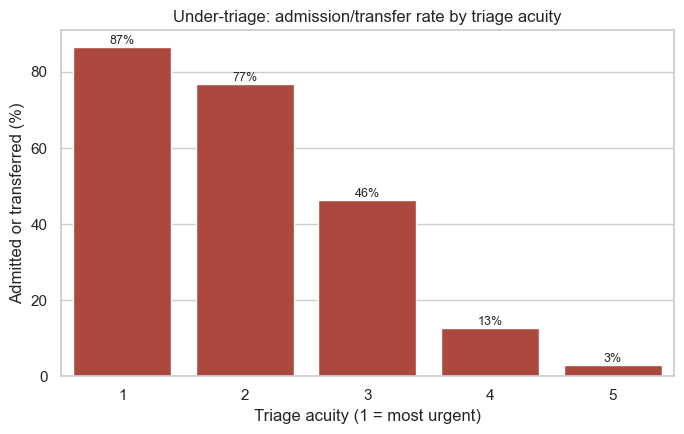

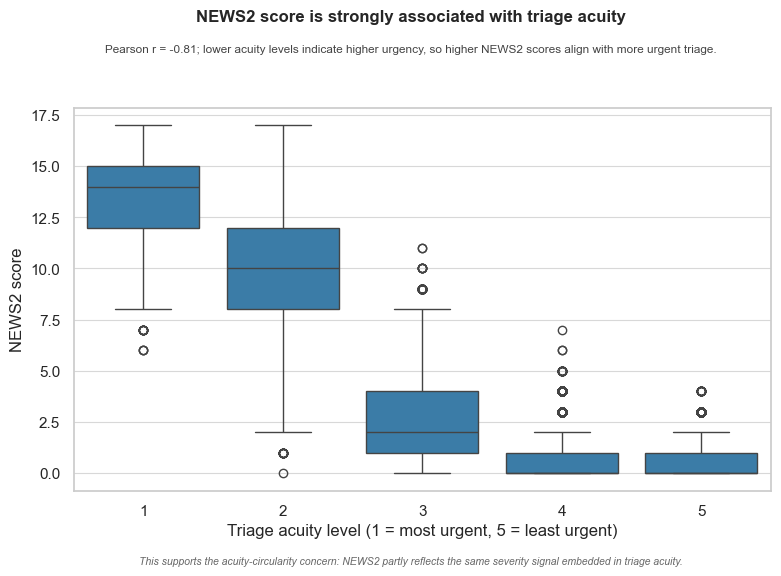

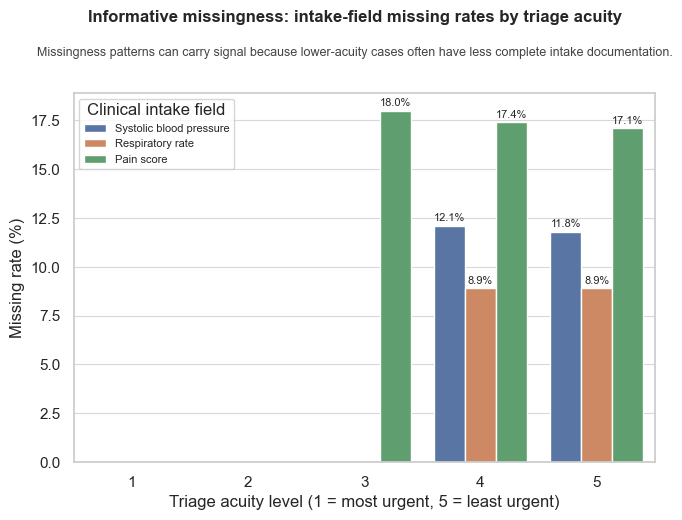

Saved: fig_undertriage.png, fig_circularity.png, fig_missingness.png -> ./outputs\figures


In [5]:
# --- Three publication-clean figures saved to FIG_DIR ---

# fig_undertriage: admission rate by acuity (bar)
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(data=undertriage, x="triage_acuity", y="admit_pct", color="#c0392b", ax=ax)
ax.set_title("Under-triage: admission/transfer rate by triage acuity")
ax.set_xlabel("Triage acuity (1 = most urgent)")
ax.set_ylabel("Admitted or transferred (%)")
for _p in ax.patches:
    ax.annotate(f"{_p.get_height():.0f}%", (_p.get_x() + _p.get_width() / 2, _p.get_height()),
                ha="center", va="bottom", fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig_undertriage.png"), dpi=150, bbox_inches="tight")
plt.show()

# fig_circularity: NEWS2 distribution by acuity (box)
_CIRCULARITY_PRESENTATION = dict(
    title="NEWS2 score is strongly associated with triage acuity",
    subtitle=(
        f"Pearson r = {news2_corr:.2f}; lower acuity levels indicate higher urgency, "
        "so higher NEWS2 scores align with more urgent triage."
    ),
    xlabel="Triage acuity level (1 = most urgent, 5 = least urgent)",
    ylabel="NEWS2 score",
    note=(
        "This supports the acuity-circularity concern: NEWS2 partly reflects the same "
        "severity signal embedded in triage acuity."
    ),
    figsize=(9, 5.8),
    top=0.80,
    subtitle_y=0.91,
)
_cp = _CIRCULARITY_PRESENTATION
fig, ax = plt.subplots(figsize=_cp["figsize"])
sns.boxplot(data=train_full, x=config.TARGET_ACUITY, y="news2_score", color="#2980b9", ax=ax)
ax.set_xlabel(_cp["xlabel"])
ax.set_ylabel(_cp["ylabel"])
ax.set_axisbelow(True)
ax.grid(True, axis="y", color="#cfcfcf", alpha=0.8, linewidth=0.8)
fig.suptitle(_cp["title"], fontsize=12, fontweight="bold", y=0.97)
fig.text(0.5, _cp["subtitle_y"], _cp["subtitle"], ha="center", va="top", fontsize=8.5, color="#444444")
fig.text(0.5, 0.01, _cp["note"], ha="center", va="bottom", fontsize=7.5, color="#666666", style="italic")
fig.subplots_adjust(top=_cp["top"], bottom=0.14)
fig.savefig(os.path.join(FIG_DIR, "fig_circularity.png"), dpi=150, bbox_inches="tight")
plt.show()

# fig_missingness: intake-field missingness rate by acuity (grouped bar)
_FIELD_LABELS = {
    "systolic_bp": "Systolic blood pressure",
    "respiratory_rate": "Respiratory rate",
    "pain_score": "Pain score",
}
_HUE_ORDER = ["systolic_bp", "respiratory_rate", "pain_score"]
_miss_long = missingness.melt(id_vars="triage_acuity", var_name="vital", value_name="miss_pct")
_miss_long["vital"] = _miss_long["vital"].str.replace("_misspct", "", regex=False)
fig, ax = plt.subplots(figsize=(7.5, 5.2))
sns.barplot(data=_miss_long, x="triage_acuity", y="miss_pct", hue="vital", hue_order=_HUE_ORDER, ax=ax)
fig.suptitle(
    "Informative missingness: intake-field missing rates by triage acuity",
    fontsize=12, fontweight="bold", y=0.98,
)
fig.text(
    0.5, 0.91,
    "Missingness patterns can carry signal because lower-acuity cases often have "
    "less complete intake documentation.",
    ha="center", va="top", fontsize=9, color="#444444",
)
ax.set_xlabel("Triage acuity level (1 = most urgent, 5 = least urgent)")
ax.set_ylabel("Missing rate (%)")
ax.set_axisbelow(True)
ax.grid(True, axis="y", color="#cfcfcf", alpha=0.8, linewidth=0.8)
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{p.get_height():.1f}%" if p.get_height() > 0 else "" for p in container],
        padding=2,
        fontsize=8,
    )
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, [_FIELD_LABELS[v] for v in _HUE_ORDER], title="Clinical intake field", fontsize=8)
fig.subplots_adjust(top=0.82)
fig.savefig(os.path.join(FIG_DIR, "fig_missingness.png"), dpi=150, bbox_inches="tight")
plt.show()

print("Saved: fig_undertriage.png, fig_circularity.png, fig_missingness.png ->", FIG_DIR)


**Figure:** Synthetic under-triage: admission/transfer rate by triage acuity.

![Synthetic under-triage: admission/transfer rate by triage acuity](../outputs/figures/fig_undertriage.png)


**Figure:** NEWS2 score versus triage acuity (acuity circularity exhibit).

![NEWS2 score versus triage acuity (acuity circularity exhibit)](../outputs/figures/fig_circularity.png)


**Figure:** Informative missingness of intake fields by triage acuity.

![Informative missingness of intake fields by triage acuity](../outputs/figures/fig_missingness.png)



## Section 3 - Leakage-Safe Split

This section creates the leakage-safe modelling split. The feature list is constructed by excluding all target variables, identifiers, and outcome-adjacent fields, then a keyword-based leakage scan is run to flag suspicious column names before modelling.

The split is performed before any preprocessing is fitted. A single stratified train/holdout split is created using `disposition` to preserve outcome structure across partitions. No imputer, scaler, encoder, vectorizer, or model component is fitted in this section. All preprocessing is defined later and fitted only on the appropriate training folds.

This design ensures that the holdout set remains genuinely unseen and that reported performance is not inflated by preprocessing leakage.


---
### Evaluation universe - read before modelling

All outcome evaluation in this notebook is performed on **`train.csv` only**, because it is the only competition file containing observed outcome columns: `disposition` and `ed_los_hours`.

To support leakage-safe model development and final evaluation, `train.csv` is split once into two fixed partitions:

* **`train_df`** - used for model development, feature selection, calibration, threshold selection, and five-fold stratified cross-validation (`CV_FOLDS = 5`);
* **`holdout_df`** - reserved for final evaluation only and not used during model selection.

The competition **`test.csv` does not contain outcome columns**, so it is not used for outcome evaluation. It may only be used for non-outcome exploratory checks or optional triage-acuity exhibits where labels are not required.

After the split is created, the resulting partitions are saved as `train_df.parquet` and `holdout_df.parquet`. All later modelling sections load these saved files directly. The notebook does not re-split the data, ensuring that every reported result is evaluated against the same fixed development and holdout structure.


In [6]:
# --- Build the feature column list ---
# Exclude (a) all targets/derived targets (LEAKAGE_COLS, which includes triage_acuity)
# and (b) identifier columns. patient_id/triage_nurse_id/site_id are identifiers, not
# clinical signal; the dataset is documented to contain no nurse/site effect, so keeping
# them would only invite memorisation. triage_acuity is excluded from features so the
# project proves value BEYOND the existing acuity label - but it is retained in
# train_df/holdout_df for under-triage analysis, acuity-only baselines, and the Gap Index.
EXCLUDE_IDS = ["patient_id", "triage_nurse_id", "site_id"]

# --- Leakage keyword scan ---
LEAK_KEYWORDS = ["disposition", "admit", "transfer", "los", "stay", "outcome",
                 "target", "death", "deceased", "lwbs", "lama"]
flagged = [c for c in train_full.columns if any(k in c.lower() for k in LEAK_KEYWORDS)]
print("Leakage-keyword scan flagged columns:")
for c in flagged:
    print(f"  - {c}")

feature_cols = [c for c in train_full.columns
                if c not in config.LEAKAGE_COLS and c not in EXCLUDE_IDS]

# Confirm every flagged column is excluded (or document the exception).
_still_in = [c for c in flagged if c in feature_cols]
print(f"\nFlagged columns still in feature_cols (should be []): {_still_in}")
assert not _still_in, f"Leakage risk: {_still_in} flagged but kept as features."

print(f"\nFinal feature_cols length: {len(feature_cols)}")
print("Final feature list:")
print(feature_cols)


Leakage-keyword scan flagged columns:
  - disposition
  - ed_los_hours
  - is_admitted
  - is_long_stay
  - is_lwbs
  - is_lama

Flagged columns still in feature_cols (should be []): []

Final feature_cols length: 60
Final feature list:
['arrival_mode', 'arrival_hour', 'arrival_day', 'arrival_month', 'arrival_season', 'shift', 'age', 'age_group', 'sex', 'language', 'insurance_type', 'transport_origin', 'pain_location', 'mental_status_triage', 'num_prior_ed_visits_12m', 'num_prior_admissions_12m', 'num_active_medications', 'num_comorbidities', 'systolic_bp', 'diastolic_bp', 'mean_arterial_pressure', 'pulse_pressure', 'heart_rate', 'respiratory_rate', 'temperature_c', 'spo2', 'gcs_total', 'pain_score', 'weight_kg', 'height_cm', 'bmi', 'shock_index', 'news2_score', 'chief_complaint_raw', 'chief_complaint_system', 'hx_hypertension', 'hx_diabetes_type2', 'hx_diabetes_type1', 'hx_asthma', 'hx_copd', 'hx_heart_failure', 'hx_atrial_fibrillation', 'hx_ckd', 'hx_liver_disease', 'hx_malignancy', 

In [7]:
# --- Single stratified train/holdout split (keyed on disposition) ---
from sklearn.model_selection import train_test_split

train_df, holdout_df = train_test_split(
    train_full,
    test_size=config.HOLDOUT_FRAC,
    stratify=train_full[config.TARGET_DISPOSITION],
    random_state=config.SEED,
)
print(f"Split sizes (expect ~64k / 16k): train_df={len(train_df)}, holdout_df={len(holdout_df)}")

# --- Verify disposition distribution preserved across the split ---
split_dist = pd.DataFrame({
    "full_pct": train_full[config.TARGET_DISPOSITION].value_counts(normalize=True).mul(100).round(2),
    "train_pct": train_df[config.TARGET_DISPOSITION].value_counts(normalize=True).mul(100).round(2),
    "holdout_pct": holdout_df[config.TARGET_DISPOSITION].value_counts(normalize=True).mul(100).round(2),
}).fillna(0.0)
print("\nDisposition distribution preserved across split (%):")
print(split_dist.to_string())
split_dist.reset_index(names="disposition").to_csv(
    os.path.join(TABLE_DIR, "table_split_distribution.csv"), index=False
)

# --- Derived-target base rates in each split (for the manifest) ---
_targets = [config.TARGET_ADMIT, config.TARGET_LONG_STAY, config.TARGET_LWBS, config.TARGET_LAMA]
train_rates = {t: round(float(train_df[t].mean()), 4) for t in _targets}
holdout_rates = {t: round(float(holdout_df[t].mean()), 4) for t in _targets}
print("\nDerived-target base rates  train vs holdout:")
for t in _targets:
    print(f"  {t:<14} train={train_rates[t]:.4f}  holdout={holdout_rates[t]:.4f}")


Split sizes (expect ~64k / 16k): train_df=64000, holdout_df=16000

Disposition distribution preserved across split (%):
             full_pct  train_pct  holdout_pct
disposition                                  
discharged      48.78      48.78        48.79
admitted        30.75      30.75        30.75
transferred      6.50       6.50         6.51
observation      5.42       5.42         5.42
lwbs             4.57       4.57         4.57
lama             3.45       3.45         3.46
deceased         0.51       0.51         0.51

Derived-target base rates  train vs holdout:
  is_admitted    train=0.3725  holdout=0.3726
  is_long_stay   train=0.3566  holdout=0.3579
  is_lwbs        train=0.0457  holdout=0.0457
  is_lama        train=0.0345  holdout=0.0346


In [8]:
# --- Persist the split + a reproducibility manifest ---
train_path = os.path.join(PROCESSED_DIR, "train_df.parquet")
holdout_path = os.path.join(PROCESSED_DIR, "holdout_df.parquet")
train_df.to_parquet(train_path, index=False)
holdout_df.to_parquet(holdout_path, index=False)
print(f"Saved: {train_path}")
print(f"Saved: {holdout_path}")

manifest = {
    "seed": config.SEED,
    "holdout_frac": config.HOLDOUT_FRAC,
    "stratify_col": config.TARGET_DISPOSITION,
    "n_train": int(len(train_df)),
    "n_holdout": int(len(holdout_df)),
    "n_features": int(len(feature_cols)),
    "feature_cols": feature_cols,
    "disposition_distribution": {
        "train": train_df[config.TARGET_DISPOSITION].value_counts(normalize=True).round(4).to_dict(),
        "holdout": holdout_df[config.TARGET_DISPOSITION].value_counts(normalize=True).round(4).to_dict(),
    },
    "target_base_rates": {"train": train_rates, "holdout": holdout_rates},
    "no_preprocessing_fit_before_split": True,
}
manifest_path = os.path.join(PROCESSED_DIR, "split_manifest.json")
with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)
print(f"Saved: {manifest_path}")

print("\nNo preprocessing fit in this step - split is raw.")


Saved: ./data\processed\train_df.parquet
Saved: ./data\processed\holdout_df.parquet
Saved: ./data\processed\split_manifest.json

No preprocessing fit in this step - split is raw.


---
## Section 4 - Baseline Suite

This section establishes the honest reference bar before any full outcome modelling is introduced. The aim is to test how much predictive signal is already available from simple, transparent rules before comparing against more flexible machine-learning models.

No full feature model is trained in this section. Logistic regression, LightGBM outcome modelling, SHAP interpretation, and richer feature-based comparisons are introduced later, after the baseline performance bar has been fixed.

The two primary binary outcomes are evaluated:

1. **Admission/transfer outcome**
2. **Long-stay outcome**, defined as ED length of stay of at least four hours

For each target, three transparent baselines are used:

1. **Majority-class baseline** - always predicts the most frequent class and provides the minimum performance floor.
2. **NEWS2-rule baseline** - uses a single threshold on `news2_score`, representing a simple severity-score rule.
3. **Acuity-only baseline** - predicts outcome risk using `triage_acuity` alone. This is the key comparator for the project, because the outcome model must outperform acuity alone to support the claim that triage-time features contain additional outcome-relevant signal.

All thresholds and the acuity-to-outcome rate lookup are selected using `train_df` only and then applied unchanged to `holdout_df`. No threshold, lookup, or model component is fitted on the holdout set.

The headline metrics are **balanced accuracy**, **ROC-AUC**, and **average precision (AP)**. Plain accuracy is reported for completeness but is not used as the main performance criterion, because class imbalance can make a weak majority-class predictor appear misleadingly strong.


In [9]:
# --- Baseline suite: load the saved split (never re-split, never read raw CSVs) ---
import numpy as np
from sklearn.metrics import (
    balanced_accuracy_score, roc_auc_score, average_precision_score,
    accuracy_score, confusion_matrix,
)

train_df = pd.read_parquet(os.path.join(PROCESSED_DIR, "train_df.parquet"))
holdout_df = pd.read_parquet(os.path.join(PROCESSED_DIR, "holdout_df.parquet"))
print(f"Loaded train_df={train_df.shape}, holdout_df={holdout_df.shape}")

BASELINE_TARGETS = [config.TARGET_ADMIT, config.TARGET_LONG_STAY]

# --- Safety assertions: both classes must be present in train AND holdout ---
for _tgt in BASELINE_TARGETS:
    for _nm, _d in [("train_df", train_df), ("holdout_df", holdout_df)]:
        _vals = set(np.unique(_d[_tgt].values))
        assert {0, 1}.issubset(_vals), f"{_tgt} in {_nm} is missing a class: {_vals}"
print("Safety check passed: both targets contain 0 and 1 in train and holdout.")


def eval_baseline(y_true, y_pred_label, y_score):
    """Compute the full metric block for a baseline on the holdout."""
    bacc = balanced_accuracy_score(y_true, y_pred_label)
    acc = accuracy_score(y_true, y_pred_label)
    try:
        roc = roc_auc_score(y_true, y_score)
    except ValueError:
        roc = 0.5  # degenerate (constant) score -> no discrimination
    pr = average_precision_score(y_true, y_score)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_label, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
    spec = tn / (tn + fp) if (tn + fp) > 0 else float("nan")
    prec = tp / (tp + fp) if (tp + fp) > 0 else float("nan")
    return {
        "balanced_accuracy": float(bacc), "roc_auc": float(roc), "pr_auc": float(pr),
        "accuracy": float(acc), "sensitivity": float(sens), "specificity": float(spec),
        "precision": float(prec), "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }


def pick_threshold(scores, y, candidates, rule):
    """Pick the threshold maximising balanced accuracy on TRAIN.

    Tie-breaking (documented): if several thresholds tie on train balanced
    accuracy, prefer the one with higher sensitivity; if still tied, prefer the
    more conservative threshold (the one that predicts fewer positives).
    `rule="ge"` -> predict 1 if score >= t (high score = positive).
    `rule="le"` -> predict 1 if score <= t (low value = positive, e.g. acuity).
    """
    rows = []
    for t in candidates:
        pred = (scores >= t).astype(int) if rule == "ge" else (scores <= t).astype(int)
        bacc = balanced_accuracy_score(y, pred)
        tp = int(((pred == 1) & (y == 1)).sum())
        fn = int(((pred == 0) & (y == 1)).sum())
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        rows.append((float(t), float(bacc), float(sens)))
    best_b = max(r[1] for r in rows)
    tied = [r for r in rows if abs(r[1] - best_b) < 1e-12]
    best_s = max(r[2] for r in tied)
    tied = [r for r in tied if abs(r[2] - best_s) < 1e-12]
    # conservative = fewer positives: higher t for "ge", lower t for "le"
    chosen = max(tied, key=lambda r: r[0]) if rule == "ge" else min(tied, key=lambda r: r[0])
    return chosen[0], chosen[1]  # (threshold, train_balanced_accuracy)


Loaded train_df=(64000, 70), holdout_df=(16000, 70)
Safety check passed: both targets contain 0 and 1 in train and holdout.


In [10]:
# --- Run the three baselines for both targets ---
results_rows, threshold_rows, bar_rows = [], [], []

for tgt in BASELINE_TARGETS:
    y_tr = train_df[tgt].values
    y_ho = holdout_df[tgt].values
    base_rate_train = float(train_df[tgt].mean())
    pos_base_rate = float(holdout_df[tgt].mean())  # PR-AUC random reference line

    # (1) MAJORITY-CLASS ----------------------------------------------------
    maj_class = int(base_rate_train >= 0.5)  # 0 for these targets
    pred = np.full(len(y_ho), maj_class)
    score = np.full(len(y_ho), base_rate_train)  # constant prob = train base rate
    m = eval_baseline(y_ho, pred, score)
    m.update(target=tgt, baseline="majority_class", positive_base_rate=round(pos_base_rate, 4),
             notes=f"always predict class {maj_class}; constant score = train base rate {base_rate_train:.3f}")
    results_rows.append(m)
    threshold_rows.append(dict(target=tgt, baseline="majority_class", selected_threshold=np.nan,
        selection_metric="none", train_balanced_accuracy=0.5,
        holdout_balanced_accuracy=round(m["balanced_accuracy"], 4),
        direction=f"predict majority class {maj_class}", notes="absolute floor baseline"))

    # (2) NEWS2-RULE --------------------------------------------------------
    cand = np.unique(train_df["news2_score"].values)
    t_news, tr_bacc_news = pick_threshold(train_df["news2_score"].values, y_tr, cand, "ge")
    pred = (holdout_df["news2_score"].values >= t_news).astype(int)
    nmin, nmax = float(train_df["news2_score"].min()), float(train_df["news2_score"].max())
    score = (holdout_df["news2_score"].values - nmin) / (nmax - nmin if nmax > nmin else 1.0)
    m = eval_baseline(y_ho, pred, score)
    m.update(target=tgt, baseline="news2_rule", positive_base_rate=round(pos_base_rate, 4),
             notes=f"predict 1 if news2_score >= {t_news:g}; ROC/PR use min-max news2 (threshold-free)")
    results_rows.append(m)
    threshold_rows.append(dict(target=tgt, baseline="news2_rule", selected_threshold=float(t_news),
        selection_metric="train_balanced_accuracy", train_balanced_accuracy=round(tr_bacc_news, 4),
        holdout_balanced_accuracy=round(m["balanced_accuracy"], 4),
        direction="news2_score >= threshold -> positive",
        notes="chosen on train; ties -> higher sensitivity -> more conservative (higher) threshold"))

    # (3) ACUITY-ONLY (the bar to beat) ------------------------------------
    rate_map = train_df.groupby(config.TARGET_ACUITY)[tgt].mean()  # train-only lookup
    missing = set(np.unique(holdout_df[config.TARGET_ACUITY].values)) - set(rate_map.index)
    if missing:
        print(f"WARNING [{tgt}]: holdout acuity levels {sorted(missing)} absent from train "
              f"lookup; falling back to train base rate {base_rate_train:.3f} for those rows.")
    score = holdout_df[config.TARGET_ACUITY].map(rate_map).fillna(base_rate_train).values
    cand_ac = np.unique(train_df[config.TARGET_ACUITY].values)
    k_ac, tr_bacc_ac = pick_threshold(train_df[config.TARGET_ACUITY].values, y_tr, cand_ac, "le")
    pred = (holdout_df[config.TARGET_ACUITY].values <= k_ac).astype(int)
    m = eval_baseline(y_ho, pred, score)
    m.update(target=tgt, baseline="acuity_only", positive_base_rate=round(pos_base_rate, 4),
             notes=f"rate-lookup (train-only) for ROC/PR; hard label acuity <= {k_ac:g}; THE BAR TO BEAT")
    results_rows.append(m)
    threshold_rows.append(dict(target=tgt, baseline="acuity_only", selected_threshold=float(k_ac),
        selection_metric="train_balanced_accuracy", train_balanced_accuracy=round(tr_bacc_ac, 4),
        holdout_balanced_accuracy=round(m["balanced_accuracy"], 4),
        direction="triage_acuity <= threshold -> positive",
        notes="rate-lookup + threshold both computed on train only"))
    bar_rows.append(dict(target=tgt,
        acuity_only_balanced_accuracy=round(m["balanced_accuracy"], 4),
        acuity_only_roc_auc=round(m["roc_auc"], 4),
        acuity_only_pr_auc=round(m["pr_auc"], 4),
        acuity_threshold=float(k_ac), positive_base_rate=round(pos_base_rate, 4)))

# --- Assemble + persist tables ---
col_order = ["target", "baseline", "balanced_accuracy", "roc_auc", "pr_auc", "accuracy",
             "sensitivity", "specificity", "precision", "tn", "fp", "fn", "tp",
             "positive_base_rate", "notes"]
results_df = pd.DataFrame(results_rows)[col_order].round(4)
thresholds_df = pd.DataFrame(threshold_rows)
bar_df = pd.DataFrame(bar_rows)

results_df.to_csv(os.path.join(TABLE_DIR, "table_baselines.csv"), index=False)
thresholds_df.to_csv(os.path.join(TABLE_DIR, "table_baseline_thresholds.csv"), index=False)
bar_df.to_csv(os.path.join(TABLE_DIR, "table_bar_to_beat.csv"), index=False)

pd.set_option("display.float_format", lambda v: f"{v:.4f}")
print("=== Consolidated baseline results (holdout) - headline: balanced_accuracy / roc_auc / pr_auc ===")
print(results_df[["target", "baseline", "balanced_accuracy", "roc_auc", "pr_auc",
                  "accuracy", "sensitivity", "specificity", "positive_base_rate"]].to_string(index=False))
print("\n=== Threshold audit ===")
print(thresholds_df.to_string(index=False))
print("\n=== BAR TO BEAT (acuity-only) - Outcome model must exceed these ===")
print(bar_df.to_string(index=False))
pd.reset_option("display.float_format")


=== Consolidated baseline results (holdout) - headline: balanced_accuracy / roc_auc / pr_auc ===
      target       baseline  balanced_accuracy  roc_auc  pr_auc  accuracy  sensitivity  specificity  positive_base_rate
 is_admitted majority_class             0.5000   0.5000  0.3726    0.6274       0.0000       1.0000              0.3726
 is_admitted     news2_rule             0.7077   0.7724  0.6531    0.7201       0.6589       0.7564              0.3726
 is_admitted    acuity_only             0.7520   0.8159  0.6606    0.7168       0.8903       0.6138              0.3726
is_long_stay majority_class             0.5000   0.5000  0.3579    0.6421       0.0000       1.0000              0.3579
is_long_stay     news2_rule             0.7526   0.8250  0.7057    0.7611       0.7227       0.7824              0.3579
is_long_stay    acuity_only             0.8177   0.8726  0.7102    0.7711       0.9820       0.6535              0.3579

=== Threshold audit ===
      target       baseline  selected_

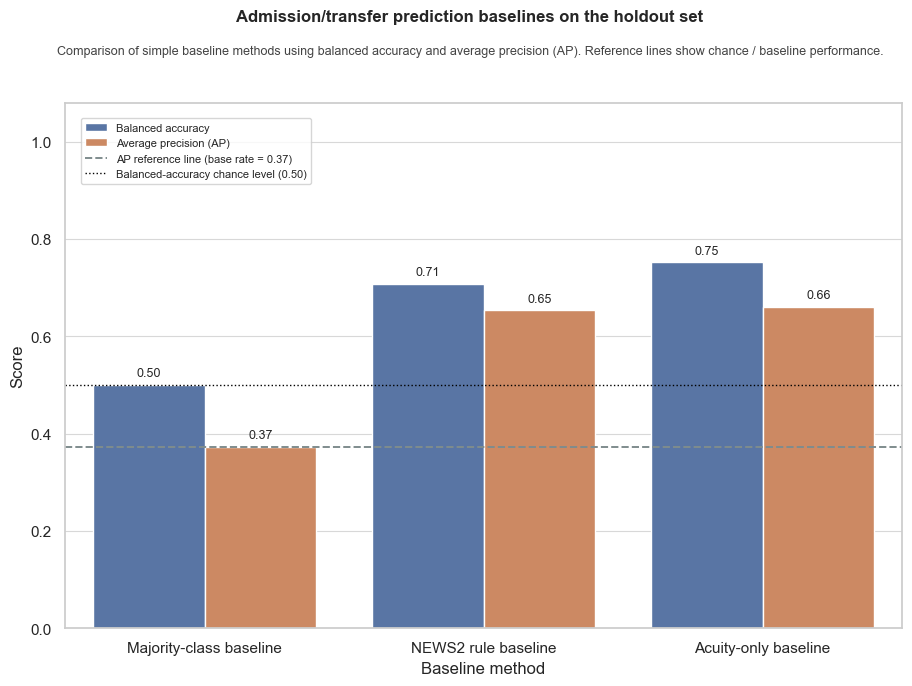

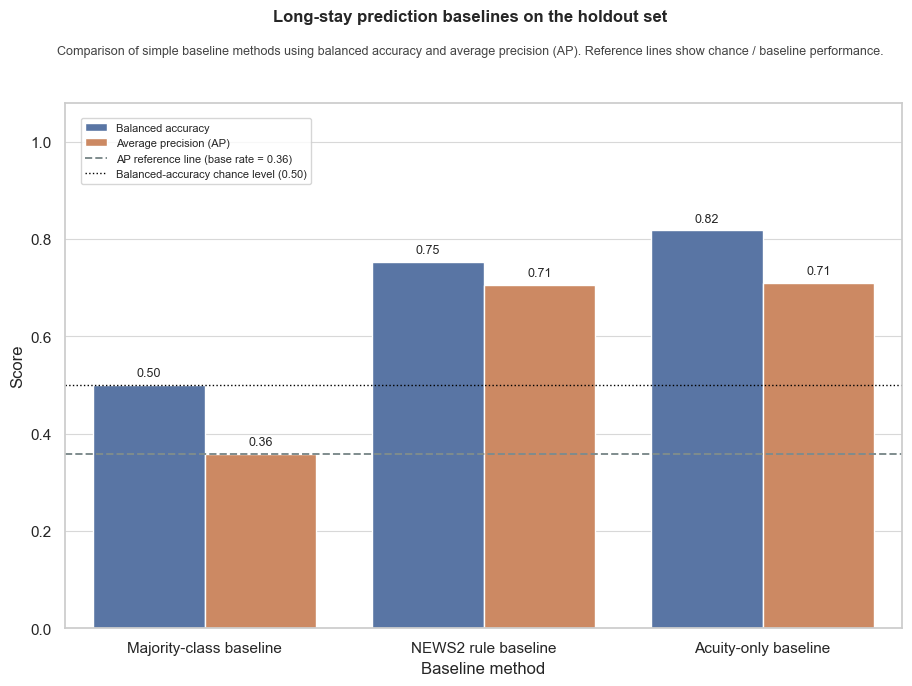

Saved: ./outputs\figures\fig_baseline_admitted.png
Saved: ./outputs\figures\fig_baseline_longstay.png


In [11]:
# --- Two baseline comparison figures (balanced accuracy vs AP), saved to FIG_DIR ---
_BASELINE_PRESENTATION = dict(
    titles={
        config.TARGET_ADMIT:     "Admission/transfer prediction baselines on the holdout set",
        config.TARGET_LONG_STAY: "Long-stay prediction baselines on the holdout set",
    },
    subtitle=(
        "Comparison of simple baseline methods using balanced accuracy and average "
        "precision (AP). Reference lines show chance / baseline performance."
    ),
    baseline_labels={
        "majority_class": "Majority-class baseline",
        "news2_rule":     "NEWS2 rule baseline",
        "acuity_only":    "Acuity-only baseline",
    },
    baseline_order=["majority_class", "news2_rule", "acuity_only"],
    metric_labels={
        "balanced_accuracy": "Balanced accuracy",
        "pr_auc":            "Average precision (AP)",
    },
    metric_order=["balanced_accuracy", "pr_auc"],
    figsize=(10.8, 7.2),
    top=0.84,
    subtitle_y=0.92,
    y_max=1.08,
    legend_loc="upper left",
)

_fig_map = [(config.TARGET_ADMIT, "fig_baseline_admitted.png"),
            (config.TARGET_LONG_STAY, "fig_baseline_longstay.png")]

for tgt, fname in _fig_map:
    sub = results_df[results_df["target"] == tgt]
    plot_df = sub.melt(id_vars="baseline", value_vars=["balanced_accuracy", "pr_auc"],
                       var_name="metric", value_name="value")
    base_rate = float(holdout_df[tgt].mean())
    pres = _BASELINE_PRESENTATION
    plot_df["baseline"] = pd.Categorical(
        plot_df["baseline"].map(pres["baseline_labels"]),
        categories=[pres["baseline_labels"][k] for k in pres["baseline_order"]],
        ordered=True,
    )
    plot_df["metric"] = pd.Categorical(
        plot_df["metric"].map(pres["metric_labels"]),
        categories=[pres["metric_labels"][k] for k in pres["metric_order"]],
        ordered=True,
    )

    fig, ax = plt.subplots(figsize=pres["figsize"])
    sns.barplot(data=plot_df, x="baseline", y="value", hue="metric", ax=ax)
    ax.axhline(base_rate, ls="--", color="#7f8c8d", lw=1.4,
               label=f"AP reference line (base rate = {base_rate:.2f})")
    ax.axhline(0.5, ls=":", color="black", lw=1.0,
               label="Balanced-accuracy chance level (0.50)")
    ax.set_ylim(0, pres["y_max"])
    ax.set_xlabel("Baseline method")
    ax.set_ylabel("Score")
    ax.set_axisbelow(True)
    ax.grid(True, axis="y", color="#cfcfcf", alpha=0.8, linewidth=0.8)
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f"{p.get_height():.2f}",
                        (p.get_x() + p.get_width() / 2, p.get_height()),
                        xytext=(0, 4), textcoords="offset points",
                        ha="center", va="bottom", fontsize=9)
    fig.suptitle(pres["titles"][tgt], fontsize=12, fontweight="bold", y=0.97)
    fig.text(0.5, pres["subtitle_y"], pres["subtitle"],
             ha="center", va="top", fontsize=9, color="#444444")
    fig.subplots_adjust(top=pres["top"])
    ax.legend(fontsize=8, loc=pres["legend_loc"], ncol=1, frameon=True,
              borderaxespad=1.4)
    fig.savefig(os.path.join(FIG_DIR, fname), dpi=150, bbox_inches="tight")
    plt.show()

print("Saved:", os.path.join(FIG_DIR, "fig_baseline_admitted.png"))
print("Saved:", os.path.join(FIG_DIR, "fig_baseline_longstay.png"))


**Figure:** Admission/transfer prediction baselines on the holdout set.

![Admission/transfer prediction baselines on the holdout set](../outputs/figures/fig_baseline_admitted.png)


**Figure:** Long-stay prediction baselines on the holdout set.

![Long-stay prediction baselines on the holdout set](../outputs/figures/fig_baseline_longstay.png)


### Interpretation - the bar to beat

The strongest baseline for both targets is the **triage acuity-only baseline**. On the holdout set, predicting outcomes using only `triage_acuity` outperforms both the majority-class floor and the NEWS2 single-threshold rule across every headline metric. This is expected and is central to the audit: acuity already carries substantial outcome signal, so any outcome-aware model must clear a genuinely demanding reference bar.

The holdout performance that the outcome models must beat is:

| Target                     | Balanced accuracy |   ROC-AUC | Average precision (AP) | Random AP reference = base rate |
| -------------------------- | ----------------: | --------: | ---------------------: | ------------------------------: |
| Admission/transfer outcome |         **0.752** | **0.816** |              **0.661** |                           0.373 |
| Long-stay outcome          |         **0.818** | **0.873** |              **0.710** |                           0.358 |

For context, the NEWS2 rule performs slightly below acuity-only modelling. For admission/transfer, it reaches balanced accuracy **0.708**, ROC-AUC **0.772**, and AP **0.653**. For long stay, it reaches balanced accuracy **0.753**, ROC-AUC **0.825**, and AP **0.706**. The majority-class baseline sits at balanced accuracy **0.50**, ROC-AUC **0.50**, and AP equal to the outcome base rate. This confirms why plain accuracy is not treated as a headline metric: the majority-class floor would appear deceptively reasonable under accuracy alone, reaching **0.63** for admission/transfer and **0.64** for long stay.

Both single-number baselines, acuity and NEWS2, selected threshold **3** on `train_df` and applied it unchanged to `holdout_df`. Train-to-holdout balanced accuracy was very similar, for example **0.756** versus **0.752** for acuity-only admission/transfer prediction. This suggests that the split is stable and that the baseline comparison is not being driven by holdout overfitting.

These results define the falsifiable bar for the next stage of the project. If the outcome models outperform the triage acuity-only baseline by a meaningful margin, especially on balanced accuracy and AP, this would support the claim that triage-time features contain additional outcome-relevant signal beyond the acuity label. If the models only match or underperform this bar, the honest interpretation is that the synthetic benchmark has collapsed much of the outcome signal into acuity, leaving limited residual structure for outcome modelling to recover.

These are synthetic-data baselines only. They do not support clinical claims and are used here solely to establish a transparent reference point before any full machine-learning outcome model is trained.

---

## Section 5 - Acuity Circularity Exhibit

This section is a deliberately small diagnostic, not a competitive acuity-prediction task. Its purpose is to quantify how much of `triage_acuity` can be reconstructed from the severity information available in the synthetic dataset, especially `news2_score`.

This matters because the synthetic acuity label is partly derived from NEWS2. If acuity can be reconstructed almost entirely from `news2_score`, then later outcome comparisons against an acuity-only baseline should be interpreted as comparisons against an already compressed severity signal.

To test this, one fixed, untuned LightGBM acuity-reconstruction model is trained on three escalating feature sets:

1. **NEWS2-only** - the single feature `news2_score`;
2. **Core vitals** - `news2_score` plus physiological vital signs;
3. **All structured features** - all numeric structured features from the Step 2 feature list, excluding text.

The aim is not to maximise predictive performance, so no hyperparameter tuning or NLP features are introduced here. Keeping the diagnostic small makes the result easier to interpret and prevents this section from becoming a separate acuity-modelling task.

Performance is reported using **accuracy**, **balanced accuracy**, **Quadratic Weighted Kappa (QWK)**, and **MAE**. QWK is included because it is commonly used for ordinal acuity-style evaluation and allows comparison with the organiser baseline of **QWK 0.712**.

The key quantity is the QWK difference between the NEWS2-only model and the all-structured model. A small gap would suggest that the acuity label is largely reconstructed from NEWS2 alone. A larger gap would suggest that additional structured features contribute meaningfully to the acuity label. Because this is synthetic data and the acuity label is partly defined by construction, this section is framed as a circularity diagnostic rather than as a discovery of a new clinical relationship.


In [12]:
# --- Acuity Circularity Exhibit: small fixed model, three feature sets ---
import lightgbm as lgb
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             cohen_kappa_score, mean_absolute_error, confusion_matrix)

train_df = pd.read_parquet(os.path.join(PROCESSED_DIR, "train_df.parquet"))
holdout_df = pd.read_parquet(os.path.join(PROCESSED_DIR, "holdout_df.parquet"))

ORG_BASELINE_QWK = 0.712  # organizer's LightGBM acuity baseline, for context

# Feature sets (structured/numeric only; targets, IDs, and text already excluded
# via feature_cols from Section 3).
NEWS2_ONLY = ["news2_score"]
CORE_VITALS = ["news2_score", "systolic_bp", "diastolic_bp", "mean_arterial_pressure",
               "pulse_pressure", "heart_rate", "respiratory_rate", "temperature_c",
               "spo2", "gcs_total", "shock_index"]
ALL_STRUCTURED = [c for c in feature_cols if pd.api.types.is_numeric_dtype(train_df[c])]
print(f"NEWS2_ONLY     : {len(NEWS2_ONLY)} feature")
print(f"CORE_VITALS    : {len(CORE_VITALS)} features")
print(f"ALL_STRUCTURED : {len(ALL_STRUCTURED)} numeric structured features (no text/IDs/targets)")

y_tr = train_df[config.TARGET_ACUITY].values
y_ho = holdout_df[config.TARGET_ACUITY].values
ACUITY_LABELS = [1, 2, 3, 4, 5]


def run_feature_set(name, cols):
    """Train the fixed LightGBM on `cols` (train only), evaluate on holdout.

    `pain_score == -1` is a sentinel for "not recorded" -> recoded to NaN (a fixed,
    non-fitted transform). LightGBM handles NaN natively, so no imputer is fit.
    """
    Xtr, Xho = train_df[cols].copy(), holdout_df[cols].copy()
    if "pain_score" in cols:
        Xtr["pain_score"] = Xtr["pain_score"].replace(-1, np.nan)
        Xho["pain_score"] = Xho["pain_score"].replace(-1, np.nan)
    model = lgb.LGBMClassifier(random_state=config.SEED, n_jobs=-1, verbose=-1)
    model.fit(Xtr, y_tr)
    p_tr, p_ho = model.predict(Xtr), model.predict(Xho)
    train_qwk = cohen_kappa_score(y_tr, p_tr, weights="quadratic")
    holdout_qwk = cohen_kappa_score(y_ho, p_ho, weights="quadratic")
    row = {
        "feature_set": name, "n_features": len(cols),
        "train_qwk": round(float(train_qwk), 4),
        "holdout_qwk": round(float(holdout_qwk), 4),
        "qwk_generalization_gap": round(float(train_qwk - holdout_qwk), 4),
        "holdout_accuracy": round(float(accuracy_score(y_ho, p_ho)), 4),
        "holdout_balanced_accuracy": round(float(balanced_accuracy_score(y_ho, p_ho)), 4),
        "holdout_mae": round(float(mean_absolute_error(y_ho, p_ho)), 4),
    }
    return row, p_ho


NEWS2_ONLY     : 1 feature
CORE_VITALS    : 11 features
ALL_STRUCTURED : 47 numeric structured features (no text/IDs/targets)


In [13]:
# --- Run the three escalating feature sets ---
rows, preds = [], {}
for _name, _cols in [("news2_only", NEWS2_ONLY),
                     ("core_vitals", CORE_VITALS),
                     ("all_structured", ALL_STRUCTURED)]:
    _row, _pho = run_feature_set(_name, _cols)
    rows.append(_row)
    preds[_name] = _pho

circ_df = pd.DataFrame(rows)
circ_df.to_csv(os.path.join(TABLE_DIR, "table_acuity_circularity.csv"), index=False)

# --- Circularity delta: NEWS2-only vs all-structured ---
news2_qwk = float(circ_df.loc[circ_df.feature_set == "news2_only", "holdout_qwk"].iloc[0])
full_qwk = float(circ_df.loc[circ_df.feature_set == "all_structured", "holdout_qwk"].iloc[0])
qwk_delta = round(full_qwk - news2_qwk, 4)
news2_pct = round(100.0 * news2_qwk / full_qwk, 1) if full_qwk != 0 else float("nan")

if qwk_delta <= 0.05:
    verdict = ("CIRCULAR: NEWS2 alone reproduces nearly all of acuity's predictability; "
               "the full structured feature set adds little, so acuity carries little "
               "information beyond the severity score it is built on.")
else:
    verdict = ("NOT FULLY CIRCULAR: acuity contains additional structured signal beyond "
               "NEWS2; later outcome models must prove value beyond BOTH severity and acuity.")

delta_df = pd.DataFrame([{
    "news2_only_qwk": news2_qwk,
    "all_structured_qwk": full_qwk,
    "qwk_delta": qwk_delta,
    "news2_pct_of_full_qwk": news2_pct,
    "interpretation": verdict,
}])
delta_df.to_csv(os.path.join(TABLE_DIR, "table_acuity_circularity_delta.csv"), index=False)

print("=== Acuity circularity: feature set x metrics (holdout) ===")
print(circ_df.to_string(index=False))
print(f"\nOrganizer baseline QWK (reference): {ORG_BASELINE_QWK}")
print(f"\nNEWS2-only holdout QWK   : {news2_qwk}")
print(f"All-structured holdout QWK: {full_qwk}")
print(f"QWK delta (full - news2) : {qwk_delta}")
print(f"NEWS2-only is {news2_pct}% of the full-model QWK")
print(f"\nVERDICT: {verdict}")


=== Acuity circularity: feature set x metrics (holdout) ===
   feature_set  n_features  train_qwk  holdout_qwk  qwk_generalization_gap  holdout_accuracy  holdout_balanced_accuracy  holdout_mae
    news2_only           1     0.7869       0.7893                 -0.0024            0.6525                     0.5596       0.3574
   core_vitals          11     0.9072       0.8888                  0.0184            0.7802                     0.7997       0.2271
all_structured          47     0.9477       0.9284                  0.0193            0.8476                     0.8630       0.1540

Organizer baseline QWK (reference): 0.712

NEWS2-only holdout QWK   : 0.7893
All-structured holdout QWK: 0.9284
QWK delta (full - news2) : 0.1391
NEWS2-only is 85.0% of the full-model QWK

VERDICT: NOT FULLY CIRCULAR: acuity contains additional structured signal beyond NEWS2; later outcome models must prove value beyond BOTH severity and acuity.


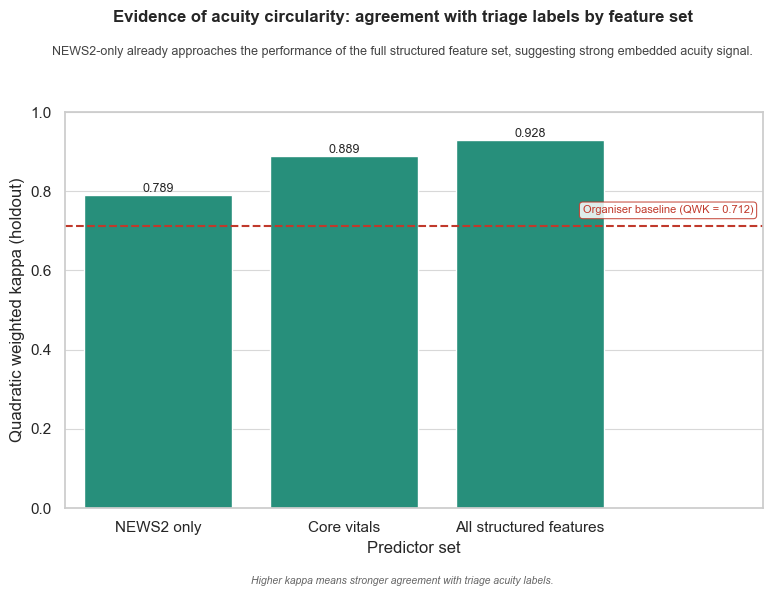

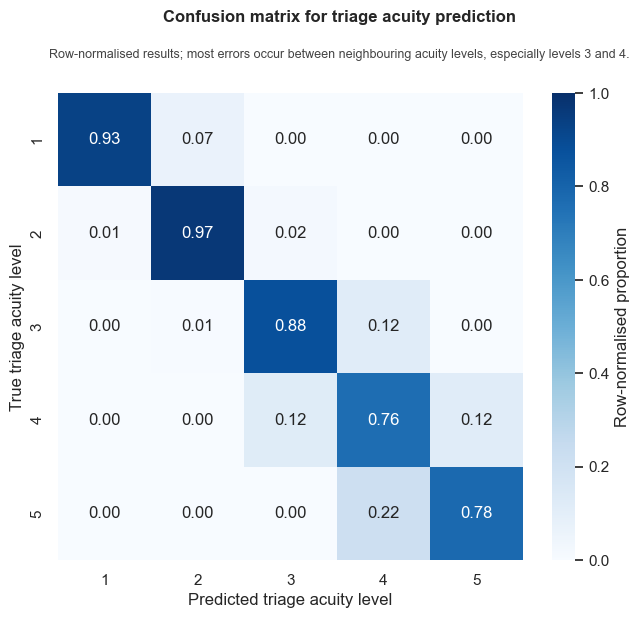

Saved: fig_circularity_exhibit.png, fig_acuity_confusion.png -> ./outputs\figures


In [14]:
# --- Figure 1: QWK across the three feature sets, with organizer baseline reference ---
_CIRC_EXHIBIT_PRESENTATION = dict(
    title="Evidence of acuity circularity: agreement with triage labels by feature set",
    subtitle=(
        "NEWS2-only already approaches the performance of the full structured feature set, "
        "suggesting strong embedded acuity signal."
    ),
    note="Higher kappa means stronger agreement with triage acuity labels.",
    tick_labels={
        "news2_only": "NEWS2 only",
        "core_vitals": "Core vitals",
        "all_structured": "All structured features",
    },
    xlabel="Predictor set",
    ylabel="Quadratic weighted kappa (holdout)",
    baseline_label=f"Organiser baseline (QWK = {ORG_BASELINE_QWK})",
    figsize=(9, 6.0),
    top=0.80,
    subtitle_y=0.91,
)
_order = ["news2_only", "core_vitals", "all_structured"]
_cep = _CIRC_EXHIBIT_PRESENTATION
_plot = circ_df.set_index("feature_set").loc[_order].reset_index()
_plot["feature_label"] = _plot["feature_set"].map(_cep["tick_labels"])
fig, ax = plt.subplots(figsize=_cep["figsize"])
sns.barplot(data=_plot, x="feature_label", y="holdout_qwk", color="#16a085", ax=ax)
ax.axhline(ORG_BASELINE_QWK, ls="--", color="#c0392b", lw=1.5)
ax.set_ylim(0, 1)
# Add right-side margin so the baseline annotation has clear empty space
_x0, _x1 = ax.get_xlim()
_right_margin = 0.75
ax.set_xlim(_x0, _x1 + _right_margin)
_label_x = _x1 + _right_margin - 0.05
ax.text(
    _label_x, ORG_BASELINE_QWK + 0.027,
    _cep["baseline_label"],
    ha="right", va="bottom",
    fontsize=8, color="#c0392b",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
              edgecolor="#c0392b", alpha=0.85, linewidth=0.8),
)
ax.set_xlabel(_cep["xlabel"])
ax.set_ylabel(_cep["ylabel"])
ax.set_axisbelow(True)
ax.grid(True, axis="y", color="#cfcfcf", alpha=0.8, linewidth=0.8)
fig.suptitle(_cep["title"], fontsize=12, fontweight="bold", y=0.97)
fig.text(0.5, _cep["subtitle_y"], _cep["subtitle"],
         ha="center", va="top", fontsize=9, color="#444444")
fig.text(0.5, 0.01, _cep["note"],
         ha="center", va="bottom", fontsize=7.5, color="#666666", style="italic")
fig.subplots_adjust(top=_cep["top"], bottom=0.14)
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=9)
fig.savefig(os.path.join(FIG_DIR, "fig_circularity_exhibit.png"), dpi=150, bbox_inches="tight")
plt.show()

# --- Figure 2: row-normalised confusion matrix (all-structured = strongest acuity model) ---
_ACUITY_CONFUSION_PRESENTATION = dict(
    title="Confusion matrix for triage acuity prediction",
    subtitle=(
        "Row-normalised results; most errors occur between neighbouring acuity levels, "
        "especially levels 3 and 4."
    ),
    xlabel="Predicted triage acuity level",
    ylabel="True triage acuity level",
    cbar_label="Row-normalised proportion",
    figsize=(7.5, 6.4),
    top=0.84,
    subtitle_y=0.91,
)
cm = confusion_matrix(y_ho, preds["all_structured"], labels=ACUITY_LABELS)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
_acp = _ACUITY_CONFUSION_PRESENTATION
fig, ax = plt.subplots(figsize=_acp["figsize"])
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            xticklabels=ACUITY_LABELS, yticklabels=ACUITY_LABELS, ax=ax,
            cbar_kws={"label": _acp["cbar_label"]})
ax.set_xlabel(_acp["xlabel"])
ax.set_ylabel(_acp["ylabel"])
fig.suptitle(_acp["title"], fontsize=12, fontweight="bold", y=0.97)
fig.text(0.5, _acp["subtitle_y"], _acp["subtitle"],
         ha="center", va="top", fontsize=9, color="#444444")
fig.subplots_adjust(top=_acp["top"])
fig.savefig(os.path.join(FIG_DIR, "fig_acuity_confusion.png"), dpi=150, bbox_inches="tight")
# Save matrix for fast presentation-only regen
np.savez(
    os.path.join(PROCESSED_DIR, "acuity_confusion_cache.npz"),
    cm_norm=cm_norm,
    acuity_labels=np.array(ACUITY_LABELS),
)
plt.show()

print("Saved: fig_circularity_exhibit.png, fig_acuity_confusion.png ->", FIG_DIR)


**Figure:** Evidence of acuity circularity: agreement with triage labels by feature set.

![Evidence of acuity circularity: agreement with triage labels by feature set](../outputs/figures/fig_circularity_exhibit.png)


**Figure:** Confusion matrix for triage acuity prediction (row-normalised).

![Confusion matrix for triage acuity prediction (row-normalised)](../outputs/figures/fig_acuity_confusion.png)


### Interpretation - acuity is strongly severity-driven, but not fully circular

The holdout QWK results increase across the three feature sets: **0.789** for NEWS2-only, **0.889** for core vitals, and **0.928** for all structured features. The QWK gap between NEWS2-only and all-structured modelling is **0.139**, meaning that a single severity score already achieves approximately **85%** of the full structured model’s QWK.

This provides evidence that `triage_acuity` is substantially severity-driven. A single feature, `news2_score`, reconstructs the acuity label with QWK **0.789**, which is already above the organiser reference QWK of **0.712**. This indicates that much of the synthetic acuity label is recoverable from the severity score it is partly based on.

However, the result does **not** support a claim of pure circularity. The improvement from NEWS2-only to core vitals, **0.789 → 0.889**, shows that physiological variables add meaningful information. The further increase to **0.928** with all structured features suggests that the acuity label retains some additional structured signal beyond NEWS2 alone. Therefore, the honest interpretation is that synthetic acuity is largely severity-score-driven, but not completely reducible to one variable.

This matters for the rest of the notebook. If acuity is already a compressed severity signal, then outcome models must demonstrate value beyond both severity and acuity. The baseline suite has already fixed this bar: the relevant question is not whether a model can reconstruct acuity, but whether it can predict downstream outcomes that acuity does not fully encode, especially admission/transfer and long ED stay.

The error pattern supports this interpretation. Residual mistakes are adjacent-class rather than severe off-by-two errors, with most confusion concentrated in the mid- and lower-acuity bands. Acuity 1 and 2 are reconstructed with high accuracy, while acuity 3, 4, and 5 are more confusable. This suggests that the synthetic label captures broad severity ordering well, but may be less informative for distinguishing outcome risk within the middle bands where operational uncertainty is greatest.

This exhibit is based on synthetic data, and the acuity–NEWS2 relationship is partly present by construction. It is therefore framed as a circularity diagnostic rather than as a new clinical discovery. The model is intentionally small and untuned; its purpose is to quantify the structure of the benchmark label, not to compete as an acuity-prediction system.

---


## Section 6 - Outcome Prediction Models

This section contains the core synthetic-dataset modelling experiment. Two LightGBM outcome models are trained at triage time to predict:

1. **Admission/transfer outcome**
2. **Long ED stay**, defined as ED length of stay of at least four hours

The purpose of these models is not simply to achieve high predictive performance. Their role is to test whether triage-time features contain outcome-relevant signal beyond the acuity label. For that reason, the primary models must be compared against the **triage acuity-only baseline** established in Section 4.

### Anti-leakage protocol

The modelling protocol is designed to prevent the outcome models from winning through leakage, hidden outcome proxies, or holdout tuning.

* **Acuity is excluded from the primary models.**
  `triage_acuity` is removed from the primary feature set so that the models must compete against the acuity-only baseline without directly using the acuity label. A secondary `+ acuity` companion model is reported separately to show how much performance changes when the acuity number is added back as a feature.

* **Missingness is handled explicitly.**
  For `systolic_bp`, `respiratory_rate`, and `pain_score`, sentinel values of `-1` are converted to `NaN` and paired with binary missingness indicators. LightGBM then handles the missing values natively. This avoids mean or median imputation and makes missingness patterns explicit rather than allowing them to enter the model as undocumented preprocessing artefacts.

* **Model selection is confined to `train_df`.**
  All model selection, threshold tuning, and calibration decisions are made using five-fold stratified cross-validation within `train_df`. Out-of-fold predictions are used for these decisions so that the final holdout set remains protected.

* **The holdout is reserved for final evaluation.**
  `holdout_df` is evaluated only after the modelling decisions have been fixed. No threshold, calibration choice, or feature-processing decision is selected using holdout performance.

* **The baseline bar is loaded from saved outputs.**
  The triage acuity-only reference values are loaded from `table_bar_to_beat.csv` rather than hardcoded. This keeps the comparison traceable to the baseline section and reduces the risk of reporting inconsistent numbers.

This section therefore tests the central synthetic-data question under a falsifiable setup: can outcome models trained without `triage_acuity` outperform the acuity-only baseline, or does the synthetic benchmark leave little residual signal beyond the triage number?


In [15]:
# --- Shared setup + helpers ---
from sklearn.model_selection import StratifiedKFold
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import (roc_auc_score, average_precision_score, balanced_accuracy_score,
                             confusion_matrix, brier_score_loss)
import lightgbm as lgb

train_df = pd.read_parquet(os.path.join(PROCESSED_DIR, "train_df.parquet"))
holdout_df = pd.read_parquet(os.path.join(PROCESSED_DIR, "holdout_df.parquet"))

# --- Load the Step-3 acuity-only bar (do NOT hardcode) ---
_bar_path = os.path.join(TABLE_DIR, "table_bar_to_beat.csv")
_base_path = os.path.join(TABLE_DIR, "table_baselines.csv")
if not (os.path.exists(_bar_path) and os.path.exists(_base_path)):
    raise FileNotFoundError("Missing Step-3 baseline tables (table_bar_to_beat.csv / "
                            "table_baselines.csv). Run Section 4 first.")
bar_to_beat = pd.read_csv(_bar_path).set_index("target")
baselines_tbl = pd.read_csv(_base_path)
acuity_only = baselines_tbl[baselines_tbl.baseline == "acuity_only"].set_index("target")
print("Acuity-only bar loaded from table_bar_to_beat.csv:")
print(bar_to_beat[["acuity_only_balanced_accuracy", "acuity_only_roc_auc",
                   "acuity_only_pr_auc", "positive_base_rate"]])

# --- Feature construction (primary excludes triage_acuity; text excluded) ---
TRAP = ["systolic_bp", "respiratory_rate", "pain_score"]
IND_COLS = [f"{t}_missing" for t in TRAP]
PRIMARY_BASE = [c for c in feature_cols if c != "chief_complaint_raw"]  # feature_cols already drops acuity
assert config.TARGET_ACUITY not in PRIMARY_BASE, "triage_acuity must NOT be a primary feature!"
CAT_COLS = [c for c in PRIMARY_BASE if train_df[c].dtype == object]
CAT_LEVELS = {c: list(pd.Series(train_df[c].dropna().unique()).sort_values()) for c in CAT_COLS}

FEATURES_PRIMARY = PRIMARY_BASE + IND_COLS
FEATURES_SECONDARY = PRIMARY_BASE + [config.TARGET_ACUITY] + IND_COLS
print(f"\nPrimary feature count (NO acuity): {len(FEATURES_PRIMARY)}  | categoricals: {len(CAT_COLS)}")
print(f"Missing-indicator features: {IND_COLS}")
print(f"Secondary model adds: {config.TARGET_ACUITY}")


def build_X(df, features):
    base = [f for f in features if f not in IND_COLS]
    X = df[base].copy()
    if "pain_score" in X.columns:
        X["pain_score"] = X["pain_score"].replace(-1, np.nan)
    for t in TRAP:
        col = df[t].replace(-1, np.nan) if t == "pain_score" else df[t]
        X[f"{t}_missing"] = col.isna().astype(int)
    for c in CAT_COLS:
        if c in X.columns:
            X[c] = pd.Categorical(X[c], categories=CAT_LEVELS[c])
    return X[features]


LGB_PARAMS = dict(n_estimators=300, learning_rate=0.05, num_leaves=31, max_depth=-1,
                  subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
                  min_child_samples=50, reg_lambda=1.0,
                  random_state=config.SEED, n_jobs=-1, verbose=-1)
# Modest, fixed params (no leaderboard-style tuning): shallow-ish trees + row/col subsampling
# + min_child_samples=50 to curb overfitting on 64k rows; documented and frozen.


def metrics_at(y, p, thr):
    pred = (p >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return {
        "balanced_accuracy": float(balanced_accuracy_score(y, pred)),
        "sensitivity": float(tp / (tp + fn)) if (tp + fn) else float("nan"),
        "specificity": float(tn / (tn + fp)) if (tn + fp) else float("nan"),
        "precision": float(tp / (tp + fp)) if (tp + fp) else float("nan"),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }


def thr_max_balacc(y, p):
    best_t, best_b, best_s = 0.5, -1.0, -1.0
    for t in np.unique(np.round(p, 4)):
        pred = (p >= t).astype(int)
        b = balanced_accuracy_score(y, pred)
        tp = int(((pred == 1) & (y == 1)).sum()); fn = int(((pred == 0) & (y == 1)).sum())
        s = tp / (tp + fn) if (tp + fn) else 0.0
        if (b > best_b) or (b == best_b and s > best_s):
            best_t, best_b, best_s = float(t), b, s
    return best_t


def thr_match_sens(y, p, target_sens):
    eligible = []
    for t in np.unique(np.round(p, 4)):
        pred = (p >= t).astype(int)
        tp = int(((pred == 1) & (y == 1)).sum()); fn = int(((pred == 0) & (y == 1)).sum())
        s = tp / (tp + fn) if (tp + fn) else 0.0
        if s >= target_sens:
            eligible.append(t)
    if eligible:
        return float(max(eligible)), True          # max threshold -> max specificity
    return float(np.min(np.round(p, 4))), False     # cannot match: most sensitive threshold


def run_model(target, features, label, target_sens):
    """5-fold OOF -> calibration decision -> two thresholds -> single refit; holdout used once."""
    Xtr, Xho = build_X(train_df, features), build_X(holdout_df, features)
    y_tr, y_ho = train_df[target].values, holdout_df[target].values
    skf = StratifiedKFold(n_splits=config.CV_FOLDS, shuffle=True, random_state=config.SEED)
    oof = np.zeros(len(y_tr)); roc, pr = [], []
    for tri, vai in skf.split(Xtr, y_tr):
        m = lgb.LGBMClassifier(**LGB_PARAMS)
        m.fit(Xtr.iloc[tri], y_tr[tri])
        p = m.predict_proba(Xtr.iloc[vai])[:, 1]
        oof[vai] = p
        roc.append(roc_auc_score(y_tr[vai], p))
        pr.append(average_precision_score(y_tr[vai], p))
    # calibration decided on train-only OOF
    iso = IsotonicRegression(out_of_bounds="clip").fit(oof, y_tr)
    oof_cal = iso.predict(oof)
    brier_raw = brier_score_loss(y_tr, oof); brier_cal = brier_score_loss(y_tr, oof_cal)
    calibrated = bool(brier_cal < brier_raw - 1e-4)
    oof_used = oof_cal if calibrated else oof
    thr_b = thr_max_balacc(y_tr, oof_used)
    thr_s, matched_ok = thr_match_sens(y_tr, oof_used, target_sens)
    # single refit on full train, holdout scored ONCE
    final = lgb.LGBMClassifier(**LGB_PARAMS).fit(Xtr, y_tr)
    raw_ho = final.predict_proba(Xho)[:, 1]
    ho_used = iso.predict(raw_ho) if calibrated else raw_ho
    return dict(label=label, target=target, features=features, model=final,
                cv_roc=roc, cv_pr=pr, oof=oof_used, oof_raw=oof, y_tr=y_tr, iso=iso,
                calibrated=calibrated, brier_raw=brier_raw, brier_cal=brier_cal,
                thr_b=thr_b, thr_s=thr_s, matched_ok=matched_ok,
                Xho=Xho, y_ho=y_ho, ho=ho_used, raw_ho=raw_ho,
                holdout_roc=float(roc_auc_score(y_ho, ho_used)),
                holdout_pr=float(average_precision_score(y_ho, ho_used)))

MODELS = {}
print("\nSetup complete.")


Acuity-only bar loaded from table_bar_to_beat.csv:
              acuity_only_balanced_accuracy  acuity_only_roc_auc  acuity_only_pr_auc  positive_base_rate
target                                                                                                  
is_admitted                          0.7520               0.8159              0.6606              0.3726
is_long_stay                         0.8177               0.8726              0.7102              0.3579

Primary feature count (NO acuity): 62  | categoricals: 12
Missing-indicator features: ['systolic_bp_missing', 'respiratory_rate_missing', 'pain_score_missing']
Secondary model adds: triage_acuity

Setup complete.


---
### 6a - Admission/Transfer Classifier (`admission/transfer outcome`)

In [16]:
# --- 6a: admission models (primary no-acuity + secondary +acuity) ---
SENS_ADMIT = float(acuity_only.loc[config.TARGET_ADMIT, "sensitivity"])  # 0.890 from Step 3
MODELS["adm"] = run_model(config.TARGET_ADMIT, FEATURES_PRIMARY, "stageH_no_acuity", SENS_ADMIT)
MODELS["adm_ac"] = run_model(config.TARGET_ADMIT, FEATURES_SECONDARY, "stageH_with_acuity", SENS_ADMIT)
R = MODELS["adm"]

print("=== 6a Admission - 5-fold CV (train OOF) ===")
print(f"  ROC-AUC : {np.mean(R['cv_roc']):.4f} +/- {np.std(R['cv_roc']):.4f}")
print(f"  PR-AUC  : {np.mean(R['cv_pr']):.4f} +/- {np.std(R['cv_pr']):.4f}")
print(f"  Calibration: Brier raw={R['brier_raw']:.4f} -> cal={R['brier_cal']:.4f} "
      f"=> {'APPLIED isotonic' if R['calibrated'] else 'NOT needed (kept raw)'}")
print(f"  Thresholds (chosen on OOF): balanced-acc={R['thr_b']:.4f}, "
      f"matched-sens(>= {SENS_ADMIT:.3f})={R['thr_s']:.4f} (achievable={R['matched_ok']})")

# Holdout evaluation (ONCE) at the balanced-accuracy operating point
hb = metrics_at(R["y_ho"], R["ho"], R["thr_b"])
print("\n=== 6a Admission - HOLDOUT @ balanced-acc threshold ===")
print(f"  balanced_accuracy={hb['balanced_accuracy']:.4f}  ROC-AUC={R['holdout_roc']:.4f}  "
      f"PR-AUC={R['holdout_pr']:.4f}")
print(f"  sensitivity={hb['sensitivity']:.4f}  specificity={hb['specificity']:.4f}  "
      f"precision={hb['precision']:.4f}")
print(f"  confusion [tn,fp,fn,tp]=[{hb['tn']},{hb['fp']},{hb['fn']},{hb['tp']}]")

# Head-to-head vs acuity-only
acc_b = float(bar_to_beat.loc[config.TARGET_ADMIT, "acuity_only_balanced_accuracy"])
acc_roc = float(bar_to_beat.loc[config.TARGET_ADMIT, "acuity_only_roc_auc"])
acc_pr = float(bar_to_beat.loc[config.TARGET_ADMIT, "acuity_only_pr_auc"])
print("\n=== 6a Admission - HEAD-TO-HEAD (Outcome model no-acuity vs acuity-only) ===")
print(f"  balanced_accuracy: {hb['balanced_accuracy']:.4f} vs {acc_b:.4f}  "
      f"(delta {hb['balanced_accuracy']-acc_b:+.4f})")
print(f"  ROC-AUC          : {R['holdout_roc']:.4f} vs {acc_roc:.4f}  (delta {R['holdout_roc']-acc_roc:+.4f})")
print(f"  PR-AUC           : {R['holdout_pr']:.4f} vs {acc_pr:.4f}  (delta {R['holdout_pr']-acc_pr:+.4f})")
print(f"  [secondary +acuity ROC-AUC={MODELS['adm_ac']['holdout_roc']:.4f}, "
      f"PR-AUC={MODELS['adm_ac']['holdout_pr']:.4f}]")

# --- Under-triage recovery: acuity-only FNs are admitted patients with acuity 4-5 ---
acu = holdout_df[config.TARGET_ACUITY].values
true_admit = holdout_df[config.TARGET_ADMIT].values == 1
buried = true_admit & (acu >= 4)            # acuity-only (admit if acuity<=3) misses these
n_buried = int(buried.sum())
stageH_pos = (R["ho"] >= R["thr_b"]).astype(int)
recovered = int((buried & (stageH_pos == 1)).sum())
stageH_fp = int(((stageH_pos == 1) & (~true_admit)).sum())
acuity_pos = (acu <= 3).astype(int)
acuity_fp = int(((acuity_pos == 1) & (~true_admit)).sum())
RECOVERY = dict(n_buried_admissions=n_buried, recovered_by_stageH=recovered,
                recovery_rate=round(recovered / n_buried, 4) if n_buried else float("nan"),
                stageH_total_false_positives=stageH_fp, acuity_only_false_positives=acuity_fp,
                extra_fp_vs_acuity=stageH_fp - acuity_fp)
print("\n=== 6a Admission - UNDER-TRIAGE RECOVERY (acuity 4-5 admitted patients) ===")
print(f"  buried admissions (acuity-only FNs): {n_buried}")
print(f"  recovered by Outcome model              : {recovered} ({RECOVERY['recovery_rate']*100:.1f}%)")
print(f"  Outcome model false positives: {stageH_fp}  vs acuity-only false positives: {acuity_fp} "
      f"(delta {RECOVERY['extra_fp_vs_acuity']:+d})")

# --- Matched-sensitivity comparison (Outcome model at matched-sens thr vs acuity-only) ---
hs = metrics_at(R["y_ho"], R["ho"], R["thr_s"])
adm_match = dict(target=config.TARGET_ADMIT, matched_sensitivity_target=round(SENS_ADMIT, 4),
                 stageH_sensitivity=round(hs["sensitivity"], 4), stageH_specificity=round(hs["specificity"], 4),
                 stageH_precision=round(hs["precision"], 4), stageH_fp=hs["fp"], stageH_fn=hs["fn"],
                 acuity_sensitivity=round(float(acuity_only.loc[config.TARGET_ADMIT, "sensitivity"]), 4),
                 acuity_specificity=round(float(acuity_only.loc[config.TARGET_ADMIT, "specificity"]), 4),
                 acuity_fp=int(acuity_only.loc[config.TARGET_ADMIT, "fp"]),
                 acuity_fn=int(acuity_only.loc[config.TARGET_ADMIT, "fn"]),
                 matched_achievable=R["matched_ok"])
print("\n=== 6a Admission - matched-sensitivity vs acuity-only ===")
print(f"  @ sens>={SENS_ADMIT:.3f}: Outcome model sens={hs['sensitivity']:.3f} spec={hs['specificity']:.3f} "
      f"fp={hs['fp']} | acuity spec={adm_match['acuity_specificity']:.3f} fp={adm_match['acuity_fp']}")


=== 6a Admission - 5-fold CV (train OOF) ===
  ROC-AUC : 0.8060 +/- 0.0041
  PR-AUC  : 0.6997 +/- 0.0058
  Calibration: Brier raw=0.1695 -> cal=0.1686 => APPLIED isotonic
  Thresholds (chosen on OOF): balanced-acc=0.3750, matched-sens(>= 0.890)=0.2093 (achievable=True)

=== 6a Admission - HOLDOUT @ balanced-acc threshold ===
  balanced_accuracy=0.7280  ROC-AUC=0.8041  PR-AUC=0.6884
  sensitivity=0.8099  specificity=0.6460  precision=0.5760
  confusion [tn,fp,fn,tp]=[6485,3554,1133,4828]

=== 6a Admission - HEAD-TO-HEAD (Outcome model no-acuity vs acuity-only) ===
  balanced_accuracy: 0.7280 vs 0.7520  (delta -0.0240)
  ROC-AUC          : 0.8041 vs 0.8159  (delta -0.0118)
  PR-AUC           : 0.6884 vs 0.6606  (delta +0.0278)
  [secondary +acuity ROC-AUC=0.8151, PR-AUC=0.6708]

=== 6a Admission - UNDER-TRIAGE RECOVERY (acuity 4-5 admitted patients) ===
  buried admissions (acuity-only FNs): 654
  recovered by Outcome model              : 46 (7.0%)
  Outcome model false positives: 3554  

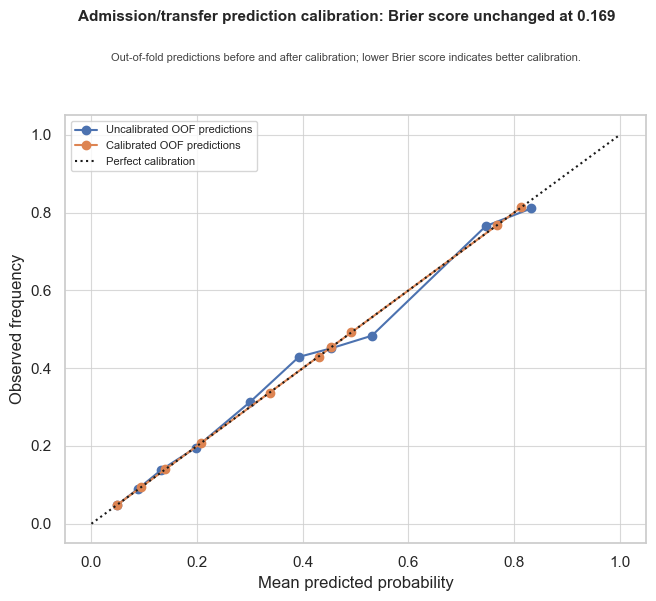

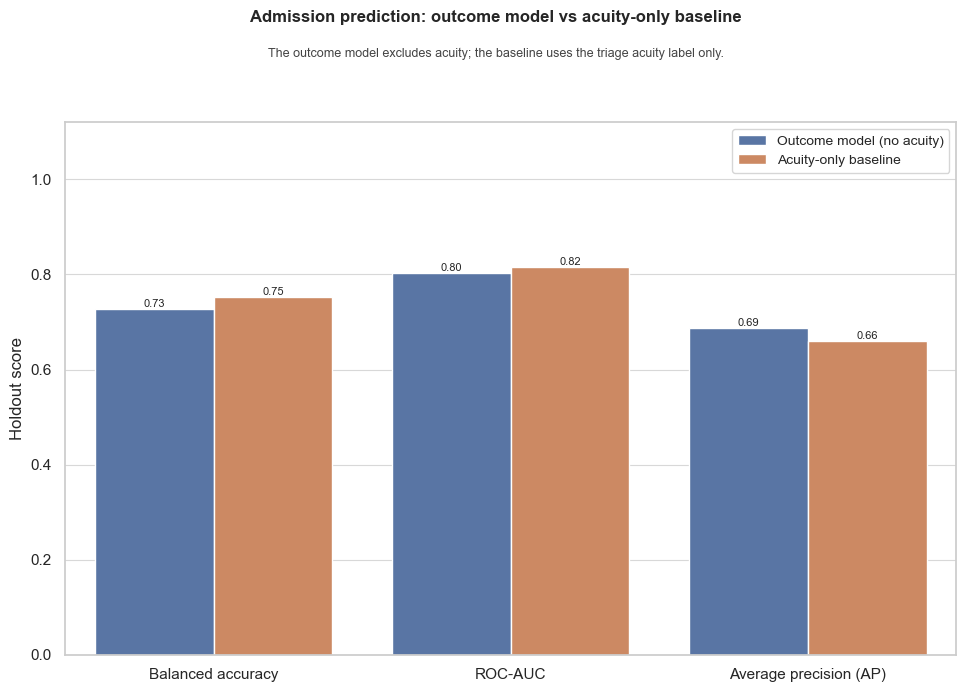

Saved admission figures.


In [17]:
# --- 6a figures: calibration curve + head-to-head bar ---
R = MODELS["adm"]
# calibration (OOF raw vs calibrated)
_CAL_ADM_PRESENTATION = dict(
    label_raw="Uncalibrated OOF predictions",
    label_cal="Calibrated OOF predictions",
    label_perfect="Perfect calibration",
    subtitle="Out-of-fold predictions before and after calibration; lower Brier score indicates better calibration.",
    figsize=(7.5, 6.2),
    top=0.80,
    subtitle_y=0.90,
)
_cap = _CAL_ADM_PRESENTATION
_cal_curves_adm = {}
fig, ax = plt.subplots(figsize=_cap["figsize"])
for probs, lab, tag in [
    (R["oof_raw"], _cap["label_raw"], "raw"),
    (R["oof"], _cap["label_cal"] if R["calibrated"] else "OOF (kept raw)", "cal"),
]:
    frac_pos, mean_pred = calibration_curve(R["y_tr"], probs, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", label=lab)
    _cal_curves_adm[f"frac_pos_{tag}"] = frac_pos
    _cal_curves_adm[f"mean_pred_{tag}"] = mean_pred
ax.plot([0, 1], [0, 1], "k:", label=_cap["label_perfect"])
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed frequency")
ax.set_axisbelow(True)
ax.grid(True, axis="both", color="#cfcfcf", alpha=0.8, linewidth=0.8)
ax.legend(fontsize=8, loc="upper left")
# Dynamic title: "unchanged at X" if rounded values match, else "A -> B"
_br_raw_s = f"{R['brier_raw']:.3f}"
_br_cal_s = f"{R['brier_cal']:.3f}"
if _br_raw_s == _br_cal_s:
    _cal_title_adm = f"Admission/transfer prediction calibration: Brier score unchanged at {_br_raw_s}"
else:
    _cal_title_adm = (
        f"Admission/transfer prediction calibration: "
        f"Brier score {_br_raw_s} \u2192 {_br_cal_s}"
    )
fig.suptitle(_cal_title_adm, fontsize=11, fontweight="bold", y=0.97)
fig.text(0.5, _cap["subtitle_y"], _cap["subtitle"],
         ha="center", va="top", fontsize=8, color="#444444")
fig.subplots_adjust(top=_cap["top"])
fig.savefig(os.path.join(FIG_DIR, "fig_calibration_admitted.png"), dpi=150, bbox_inches="tight")
# Save calibration-curve data for fast presentation-only regen
np.savez(
    os.path.join(PROCESSED_DIR, "calibration_admitted_cache.npz"),
    brier_raw=np.array([R["brier_raw"]]),
    brier_cal=np.array([R["brier_cal"]]),
    calibrated=np.array([int(R["calibrated"])]),
    **_cal_curves_adm,
)
plt.show()

# head-to-head bar
_H2H_ADMITTED_PRESENTATION = dict(
    title="Admission prediction: outcome model vs acuity-only baseline",
    subtitle=(
        "The outcome model excludes acuity; the baseline uses the triage acuity label only."
    ),
    model_labels={
        "Outcome model (no acuity)": "Outcome model (no acuity)",
        "acuity-only": "Acuity-only baseline",
    },
    metric_labels={
        "balanced_accuracy": "Balanced accuracy",
        "roc_auc": "ROC-AUC",
        "pr_auc": "Average precision (AP)",
    },
    metric_order=["balanced_accuracy", "roc_auc", "pr_auc"],
    figsize=(11.5, 7.5),
    top=0.82,
    subtitle_y=0.92,
)

hb = metrics_at(R["y_ho"], R["ho"], R["thr_b"])
_h2h = pd.DataFrame({
    "metric": ["balanced_accuracy", "roc_auc", "pr_auc"] * 2,
    "model": ["Outcome model (no acuity)"] * 3 + ["acuity-only"] * 3,
    "value": [hb["balanced_accuracy"], R["holdout_roc"], R["holdout_pr"],
              float(bar_to_beat.loc[config.TARGET_ADMIT, "acuity_only_balanced_accuracy"]),
              float(bar_to_beat.loc[config.TARGET_ADMIT, "acuity_only_roc_auc"]),
              float(bar_to_beat.loc[config.TARGET_ADMIT, "acuity_only_pr_auc"])],
})
pres = _H2H_ADMITTED_PRESENTATION
_h2h_plot = _h2h.copy()
_h2h_plot["metric"] = pd.Categorical(
    _h2h_plot["metric"].map(pres["metric_labels"]),
    categories=[pres["metric_labels"][k] for k in pres["metric_order"]],
    ordered=True,
)
_h2h_plot["model"] = _h2h_plot["model"].map(pres["model_labels"])
fig, ax = plt.subplots(figsize=pres["figsize"])
sns.barplot(data=_h2h_plot, x="metric", y="value", hue="model", ax=ax)
ax.set_ylim(0, 1.12)
ax.set_xlabel("")
ax.set_ylabel("Holdout score")
fig.suptitle(pres["title"], fontsize=12, fontweight="bold", y=0.97)
fig.text(0.5, pres["subtitle_y"], pres["subtitle"],
         ha="center", va="top", fontsize=9, color="#444444")
fig.subplots_adjust(top=pres["top"])
ax.set_axisbelow(True)
ax.grid(True, axis="y", color="#cfcfcf", alpha=0.8, linewidth=0.8)
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=8)
ax.legend(loc="upper right", frameon=True, fontsize=10)
fig.savefig(os.path.join(FIG_DIR, "fig_h2h_admitted.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved admission figures.")


**Figure:** Admission/transfer prediction calibration on out-of-fold predictions.

![Admission/transfer prediction calibration on out-of-fold predictions](../outputs/figures/fig_calibration_admitted.png)


**Figure:** Head-to-head: admission/transfer outcome model vs triage acuity-only baseline.

![Head-to-head: admission/transfer outcome model vs triage acuity-only baseline](../outputs/figures/fig_h2h_admitted.png)


### 6b - Long-Stay Classifier (`long-stay outcome`)

This section applies the same modelling pipeline used in Section 6a to the long-stay outcome, defined as ED length of stay of at least four hours.

The triage acuity-only baseline is especially strong for this target, with holdout balanced accuracy **0.818** and sensitivity **0.982**. This creates a demanding reference bar for the outcome model. Therefore, any improvement should be interpreted carefully: a modest gain may still be meaningful, while matching or underperforming the acuity-only baseline would indicate that the synthetic benchmark leaves limited residual signal beyond acuity for this outcome.

Two leakage controls are enforced for this target. First, `ed_los_hours` is excluded because it directly defines the long-stay label and would therefore leak the answer. Second, `triage_acuity` is excluded from the primary model feature set so that the model is tested against the acuity-only baseline rather than being allowed to use the same acuity label directly.

The goal of this section is therefore to test whether triage-time features can predict long ED stay beyond the already strong acuity-only signal, under the same leakage-safe evaluation protocol used for the admission/transfer outcome.


In [18]:
# --- 6b: long-stay models (primary + secondary) ---
SENS_LS = float(acuity_only.loc[config.TARGET_LONG_STAY, "sensitivity"])  # 0.982 from Step 3
MODELS["ls"] = run_model(config.TARGET_LONG_STAY, FEATURES_PRIMARY, "stageH_no_acuity", SENS_LS)
MODELS["ls_ac"] = run_model(config.TARGET_LONG_STAY, FEATURES_SECONDARY, "stageH_with_acuity", SENS_LS)
R = MODELS["ls"]

print("=== 6b Long-stay - 5-fold CV (train OOF) ===")
print(f"  ROC-AUC : {np.mean(R['cv_roc']):.4f} +/- {np.std(R['cv_roc']):.4f}")
print(f"  PR-AUC  : {np.mean(R['cv_pr']):.4f} +/- {np.std(R['cv_pr']):.4f}")
print(f"  Calibration: Brier raw={R['brier_raw']:.4f} -> cal={R['brier_cal']:.4f} "
      f"=> {'APPLIED isotonic' if R['calibrated'] else 'NOT needed (kept raw)'}")
print(f"  Thresholds: balanced-acc={R['thr_b']:.4f}, matched-sens(>= {SENS_LS:.3f})={R['thr_s']:.4f} "
      f"(achievable={R['matched_ok']})")

hb = metrics_at(R["y_ho"], R["ho"], R["thr_b"])
print("\n=== 6b Long-stay - HOLDOUT @ balanced-acc threshold ===")
print(f"  balanced_accuracy={hb['balanced_accuracy']:.4f}  ROC-AUC={R['holdout_roc']:.4f}  "
      f"PR-AUC={R['holdout_pr']:.4f}")
print(f"  sensitivity={hb['sensitivity']:.4f}  specificity={hb['specificity']:.4f}  "
      f"precision={hb['precision']:.4f}")
print(f"  confusion [tn,fp,fn,tp]=[{hb['tn']},{hb['fp']},{hb['fn']},{hb['tp']}]")

acc_b = float(bar_to_beat.loc[config.TARGET_LONG_STAY, "acuity_only_balanced_accuracy"])
acc_roc = float(bar_to_beat.loc[config.TARGET_LONG_STAY, "acuity_only_roc_auc"])
acc_pr = float(bar_to_beat.loc[config.TARGET_LONG_STAY, "acuity_only_pr_auc"])
print("\n=== 6b Long-stay - HEAD-TO-HEAD (Outcome model no-acuity vs acuity-only) ===")
print(f"  balanced_accuracy: {hb['balanced_accuracy']:.4f} vs {acc_b:.4f}  "
      f"(delta {hb['balanced_accuracy']-acc_b:+.4f})")
print(f"  ROC-AUC          : {R['holdout_roc']:.4f} vs {acc_roc:.4f}  (delta {R['holdout_roc']-acc_roc:+.4f})")
print(f"  PR-AUC           : {R['holdout_pr']:.4f} vs {acc_pr:.4f}  (delta {R['holdout_pr']-acc_pr:+.4f})")
print(f"  [secondary +acuity ROC-AUC={MODELS['ls_ac']['holdout_roc']:.4f}, "
      f"PR-AUC={MODELS['ls_ac']['holdout_pr']:.4f}]")

hs = metrics_at(R["y_ho"], R["ho"], R["thr_s"])
ls_match = dict(target=config.TARGET_LONG_STAY, matched_sensitivity_target=round(SENS_LS, 4),
                stageH_sensitivity=round(hs["sensitivity"], 4), stageH_specificity=round(hs["specificity"], 4),
                stageH_precision=round(hs["precision"], 4), stageH_fp=hs["fp"], stageH_fn=hs["fn"],
                acuity_sensitivity=round(float(acuity_only.loc[config.TARGET_LONG_STAY, "sensitivity"]), 4),
                acuity_specificity=round(float(acuity_only.loc[config.TARGET_LONG_STAY, "specificity"]), 4),
                acuity_fp=int(acuity_only.loc[config.TARGET_LONG_STAY, "fp"]),
                acuity_fn=int(acuity_only.loc[config.TARGET_LONG_STAY, "fn"]),
                matched_achievable=R["matched_ok"])
print("\n=== 6b Long-stay - matched-sensitivity vs acuity-only ===")
print(f"  @ sens>={SENS_LS:.3f}: achievable={R['matched_ok']}; Outcome model sens={hs['sensitivity']:.3f} "
      f"spec={hs['specificity']:.3f} fp={hs['fp']} | acuity spec={ls_match['acuity_specificity']:.3f} "
      f"fp={ls_match['acuity_fp']}")


=== 6b Long-stay - 5-fold CV (train OOF) ===
  ROC-AUC : 0.8645 +/- 0.0020
  PR-AUC  : 0.7515 +/- 0.0060
  Calibration: Brier raw=0.1416 -> cal=0.1406 => APPLIED isotonic
  Thresholds: balanced-acc=0.3627, matched-sens(>= 0.982)=0.0654 (achievable=True)

=== 6b Long-stay - HOLDOUT @ balanced-acc threshold ===
  balanced_accuracy=0.7834  ROC-AUC=0.8626  PR-AUC=0.7333
  sensitivity=0.8905  specificity=0.6762  precision=0.6053
  confusion [tn,fp,fn,tp]=[6947,3326,627,5100]

=== 6b Long-stay - HEAD-TO-HEAD (Outcome model no-acuity vs acuity-only) ===
  balanced_accuracy: 0.7834 vs 0.8177  (delta -0.0343)
  ROC-AUC          : 0.8626 vs 0.8726  (delta -0.0100)
  PR-AUC           : 0.7333 vs 0.7102  (delta +0.0231)
  [secondary +acuity ROC-AUC=0.8721, PR-AUC=0.7370]

=== 6b Long-stay - matched-sensitivity vs acuity-only ===
  @ sens>=0.982: achievable=True; Outcome model sens=0.985 spec=0.457 fp=5583 | acuity spec=0.653 fp=3560


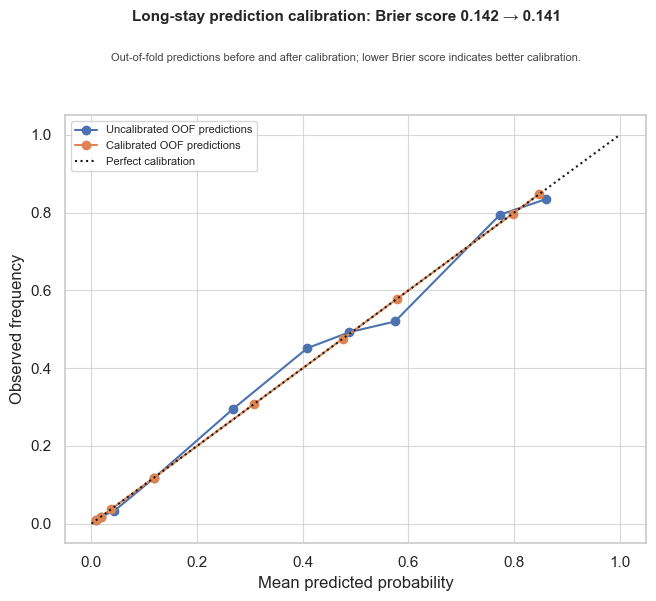

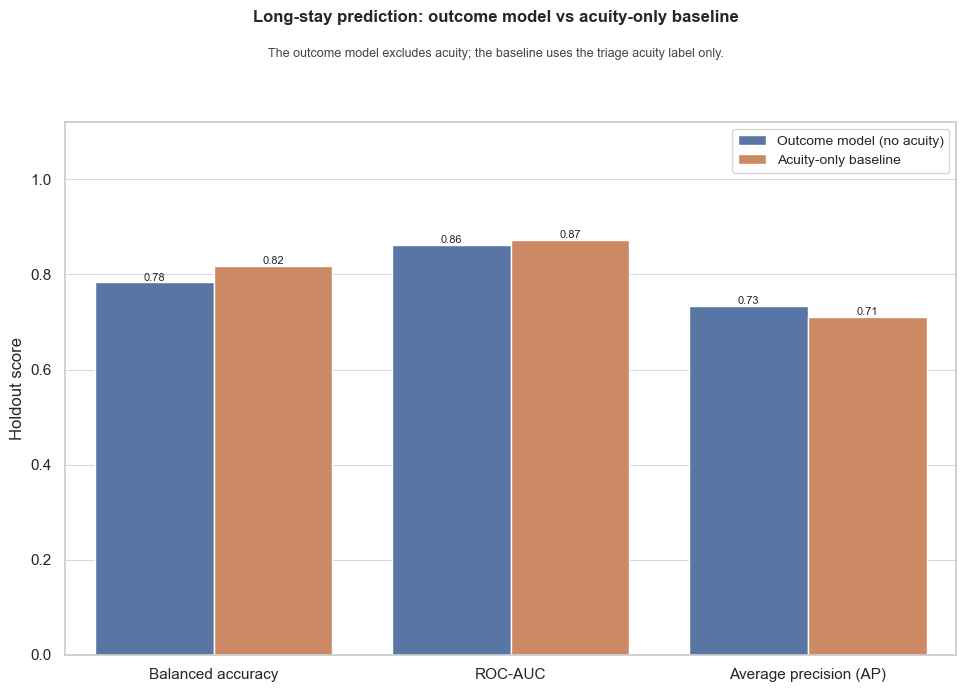

=== Within-acuity-band risk separation (acuity 3 & 4) - preview for Step 6 ===
      target  acuity    n  mean_pred_risk  observed_rate
 is_admitted       3 1209          0.2720         0.4797
 is_admitted       3 1819          0.4304         0.4546
 is_admitted       3 1549          0.4541         0.4519
 is_admitted       3  497          0.4561         0.4608
 is_admitted       3  755          0.5013         0.4464
 is_admitted       4 1033          0.0791         0.1355
 is_admitted       4 1112          0.1282         0.1313
 is_admitted       4  773          0.1628         0.1061
 is_admitted       4  690          0.2026         0.1348
 is_admitted       4  897          0.3300         0.1427
is_long_stay       3 1213          0.2418         0.5070
is_long_stay       3 1121          0.4405         0.4764
is_long_stay       3 2850          0.4866         0.5018
is_long_stay       3  645          0.5550         0.5163
is_long_stay       4 1658          0.0162         0.0241
is_long_s

In [19]:
# --- 6b figures: calibration + head-to-head bar ---
R = MODELS["ls"]
_CAL_LS_PRESENTATION = dict(
    label_raw="Uncalibrated OOF predictions",
    label_cal="Calibrated OOF predictions",
    label_perfect="Perfect calibration",
    subtitle="Out-of-fold predictions before and after calibration; lower Brier score indicates better calibration.",
    figsize=(7.5, 6.2),
    top=0.80,
    subtitle_y=0.90,
)
_clp = _CAL_LS_PRESENTATION
_cal_curves = {}
fig, ax = plt.subplots(figsize=_clp["figsize"])
for probs, lab, tag in [
    (R["oof_raw"], _clp["label_raw"], "raw"),
    (R["oof"], _clp["label_cal"] if R["calibrated"] else "OOF (kept raw)", "cal"),
]:
    frac_pos, mean_pred = calibration_curve(R["y_tr"], probs, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", label=lab)
    _cal_curves[f"frac_pos_{tag}"] = frac_pos
    _cal_curves[f"mean_pred_{tag}"] = mean_pred
ax.plot([0, 1], [0, 1], "k:", label=_clp["label_perfect"])
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed frequency")
ax.set_axisbelow(True)
ax.grid(True, axis="both", color="#cfcfcf", alpha=0.8, linewidth=0.8)
ax.legend(fontsize=8, loc="upper left")
_cal_title = (
    f"Long-stay prediction calibration: "
    f"Brier score {R['brier_raw']:.3f} \u2192 {R['brier_cal']:.3f}"
)
fig.suptitle(_cal_title, fontsize=11, fontweight="bold", y=0.97)
fig.text(0.5, _clp["subtitle_y"], _clp["subtitle"],
         ha="center", va="top", fontsize=8, color="#444444")
fig.subplots_adjust(top=_clp["top"])
fig.savefig(os.path.join(FIG_DIR, "fig_calibration_longstay.png"), dpi=150, bbox_inches="tight")
# Save calibration-curve data for fast presentation-only regen
np.savez(
    os.path.join(PROCESSED_DIR, "calibration_longstay_cache.npz"),
    brier_raw=np.array([R["brier_raw"]]),
    brier_cal=np.array([R["brier_cal"]]),
    calibrated=np.array([int(R["calibrated"])]),
    **_cal_curves,
)
plt.show()

_H2H_LONGSTAY_PRESENTATION = dict(
    title="Long-stay prediction: outcome model vs acuity-only baseline",
    subtitle=(
        "The outcome model excludes acuity; the baseline uses the triage acuity label only."
    ),
    model_labels={
        "Outcome model (no acuity)": "Outcome model (no acuity)",
        "acuity-only": "Acuity-only baseline",
    },
    metric_labels={
        "balanced_accuracy": "Balanced accuracy",
        "roc_auc": "ROC-AUC",
        "pr_auc": "Average precision (AP)",
    },
    metric_order=["balanced_accuracy", "roc_auc", "pr_auc"],
    figsize=(11.5, 7.5),
    top=0.82,
    subtitle_y=0.92,
)

hb = metrics_at(R["y_ho"], R["ho"], R["thr_b"])
_h2h = pd.DataFrame({
    "metric": ["balanced_accuracy", "roc_auc", "pr_auc"] * 2,
    "model": ["Outcome model (no acuity)"] * 3 + ["acuity-only"] * 3,
    "value": [hb["balanced_accuracy"], R["holdout_roc"], R["holdout_pr"],
              float(bar_to_beat.loc[config.TARGET_LONG_STAY, "acuity_only_balanced_accuracy"]),
              float(bar_to_beat.loc[config.TARGET_LONG_STAY, "acuity_only_roc_auc"]),
              float(bar_to_beat.loc[config.TARGET_LONG_STAY, "acuity_only_pr_auc"])],
})
pres = _H2H_LONGSTAY_PRESENTATION
_h2h_plot = _h2h.copy()
_h2h_plot["metric"] = pd.Categorical(
    _h2h_plot["metric"].map(pres["metric_labels"]),
    categories=[pres["metric_labels"][k] for k in pres["metric_order"]],
    ordered=True,
)
_h2h_plot["model"] = _h2h_plot["model"].map(pres["model_labels"])
fig, ax = plt.subplots(figsize=pres["figsize"])
sns.barplot(data=_h2h_plot, x="metric", y="value", hue="model", ax=ax)
ax.set_ylim(0, 1.12)
ax.set_xlabel("")
ax.set_ylabel("Holdout score")
fig.suptitle(pres["title"], fontsize=12, fontweight="bold", y=0.97)
fig.text(0.5, pres["subtitle_y"], pres["subtitle"],
         ha="center", va="top", fontsize=9, color="#444444")
fig.subplots_adjust(top=pres["top"])
ax.set_axisbelow(True)
ax.grid(True, axis="y", color="#cfcfcf", alpha=0.8, linewidth=0.8)
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=8)
ax.legend(
    loc="upper right",
    frameon=True,
    fontsize=10,
)
fig.savefig(os.path.join(FIG_DIR, "fig_h2h_longstay.png"), dpi=150, bbox_inches="tight")
plt.show()

# --- within-acuity-band risk separation (diagnostic preview for Step 6) ---
def within_band(model_key, target, level, q=5):
    R = MODELS[model_key]
    mask = holdout_df[config.TARGET_ACUITY].values == level
    sub_p = R["ho"][mask]; sub_y = holdout_df[target].values[mask]
    bins = pd.qcut(pd.Series(sub_p), q, duplicates="drop")
    d = pd.DataFrame({"p": sub_p, "y": sub_y, "bin": bins.values})
    g = d.groupby("bin", observed=True).agg(n=("y", "size"), mean_pred_risk=("p", "mean"),
                                            observed_rate=("y", "mean")).reset_index(drop=True)
    g.insert(0, "acuity", level); g.insert(0, "target", target)
    return g.round(4)

WITHIN = pd.concat([
    within_band("adm", config.TARGET_ADMIT, 3), within_band("adm", config.TARGET_ADMIT, 4),
    within_band("ls", config.TARGET_LONG_STAY, 3), within_band("ls", config.TARGET_LONG_STAY, 4),
], ignore_index=True)
print("=== Within-acuity-band risk separation (acuity 3 & 4) - preview for Step 6 ===")
print(WITHIN.to_string(index=False))


**Figure:** Long-stay prediction calibration on out-of-fold predictions.

![Long-stay prediction calibration on out-of-fold predictions](../outputs/figures/fig_calibration_longstay.png)


**Figure:** Head-to-head: long-stay outcome model vs triage acuity-only baseline.

![Head-to-head: long-stay outcome model vs triage acuity-only baseline](../outputs/figures/fig_h2h_longstay.png)


### 6c - SHAP Interpretability

In [20]:
# --- 6c: SHAP for both primary models (holdout sample) ---
import shap

SHAP_N = min(2000, len(holdout_df))
_idx = np.random.RandomState(config.SEED).choice(len(holdout_df), SHAP_N, replace=False)

def shap_top(model_key, fname, title, figsize=None, show_grid=False):
    R = MODELS[model_key]
    Xs = R["Xho"].iloc[_idx]
    expl = shap.TreeExplainer(R["model"])
    sv = expl.shap_values(Xs)
    if isinstance(sv, list):
        sv = sv[1]
    sv = np.asarray(sv)
    if sv.ndim == 3:
        sv = sv[..., 1]
    Xplot = Xs.copy()
    for c in Xplot.columns:
        if str(Xplot[c].dtype) == "category":
            Xplot[c] = Xplot[c].cat.codes
    if figsize:
        plt.figure(figsize=figsize)
    else:
        plt.figure()
    shap.summary_plot(sv, Xplot, max_display=15, show=False)
    if show_grid:
        ax = plt.gca()
        ax.set_axisbelow(True)
        ax.grid(True, axis="both", color="#bdbdbd", alpha=0.7, linewidth=0.8)
    plt.title(title)
    plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, fname), dpi=150, bbox_inches="tight"); plt.close()
    top = (pd.DataFrame({"model": R["label"] + f" [{R['target']}]", "feature": list(Xs.columns),
                         "mean_abs_shap": np.abs(sv).mean(axis=0)})
           .sort_values("mean_abs_shap", ascending=False).reset_index(drop=True))
    top["rank"] = top.index + 1
    return top

top_adm = shap_top(
    "adm",
    "fig_shap_admitted.png",
    "SHAP feature effects: admission/transfer prediction without acuity",
    show_grid=True,
)
top_ls = shap_top(
    "ls",
    "fig_shap_longstay.png",
    "SHAP feature effects: long-stay prediction without acuity",
    figsize=(11, 10),
    show_grid=True,
)
shap_top_features = pd.concat([top_adm.head(15), top_ls.head(15)], ignore_index=True)
shap_top_features.to_csv(os.path.join(TABLE_DIR, "table_shap_top_features.csv"), index=False)

print("=== Top 8 SHAP drivers - ADMISSION ===")
print(top_adm.head(8)[["rank", "feature", "mean_abs_shap"]].to_string(index=False))
print("\n=== Top 8 SHAP drivers - LONG-STAY ===")
print(top_ls.head(8)[["rank", "feature", "mean_abs_shap"]].to_string(index=False))

# --- missingness-trap verdict: are *_missing indicators among top drivers? ---
def trap_check(top, name):
    hits = top[top.feature.isin(IND_COLS)][["feature", "rank", "mean_abs_shap"]]
    flagged = bool((hits["rank"] <= 8).any())
    print(f"\n[{name}] missing-indicator ranks: "
          + (", ".join(f"{r.feature}=#{int(r['rank'])}" for _, r in hits.iterrows()) or "none in list"))
    print(f"  VERDICT: {'RED FLAG - indicator in top 8 (informative-missingness exploitation risk)' if flagged else 'OK - no missing-indicator in top 8'}")
    return flagged

trap_adm = trap_check(top_adm, "admission")
trap_ls = trap_check(top_ls, "long-stay")
print("Saved SHAP beeswarms + table_shap_top_features.csv")


c:\Users\ellab\anaconda3\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
C:\Users\ellab\AppData\Local\Temp\ipykernel_8356\2366615539.py:25: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, Xplot, max_display=15, show=False)
c:\Users\ellab\anaconda3\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
C:\Users\ellab\AppData\Local\Temp\ipykernel_8356\2366615539.py:25: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to t

=== Top 8 SHAP drivers - ADMISSION ===
 rank                 feature  mean_abs_shap
    1             news2_score       0.494473
    2              pain_score       0.260483
    3               gcs_total       0.222356
    4        respiratory_rate       0.164812
    5           temperature_c       0.144284
    6                    spo2       0.138368
    7    mental_status_triage       0.127995
    8 num_prior_ed_visits_12m       0.099128

=== Top 8 SHAP drivers - LONG-STAY ===
 rank                 feature  mean_abs_shap
    1             news2_score       0.635018
    2              pain_score       0.601679
    3               gcs_total       0.256141
    4        respiratory_rate       0.221333
    5           temperature_c       0.199057
    6                    spo2       0.196505
    7 num_prior_ed_visits_12m       0.179797
    8    mental_status_triage       0.172309

[admission] missing-indicator ranks: respiratory_rate_missing=#33, pain_score_missing=#61, systolic_bp_missing

**Figure:** Top features driving admission/transfer outcome predictions (SHAP).

![Top features driving admission/transfer outcome predictions (SHAP)](../outputs/figures/fig_shap_admitted.png)


**Figure:** Top features driving long-stay outcome predictions (SHAP).

![Top features driving long-stay outcome predictions (SHAP)](../outputs/figures/fig_shap_longstay.png)


In [21]:
# --- Consolidate Outcome model tables + save predictions for later steps ---
def result_row(R, variant):
    hb = metrics_at(R["y_ho"], R["ho"], R["thr_b"])
    tgt = R["target"]
    ab = float(bar_to_beat.loc[tgt, "acuity_only_balanced_accuracy"])
    ar = float(bar_to_beat.loc[tgt, "acuity_only_roc_auc"])
    ap = float(bar_to_beat.loc[tgt, "acuity_only_pr_auc"])
    return dict(target=tgt, model_variant=variant,
                cv_roc_mean=round(np.mean(R["cv_roc"]), 4), cv_roc_std=round(np.std(R["cv_roc"]), 4),
                cv_pr_mean=round(np.mean(R["cv_pr"]), 4), cv_pr_std=round(np.std(R["cv_pr"]), 4),
                holdout_balanced_accuracy=round(hb["balanced_accuracy"], 4),
                holdout_roc_auc=round(R["holdout_roc"], 4), holdout_pr_auc=round(R["holdout_pr"], 4),
                holdout_sensitivity=round(hb["sensitivity"], 4), holdout_specificity=round(hb["specificity"], 4),
                threshold=round(R["thr_b"], 4), calibrated=R["calibrated"],
                tn=hb["tn"], fp=hb["fp"], fn=hb["fn"], tp=hb["tp"],
                delta_balacc_vs_acuity=round(hb["balanced_accuracy"] - ab, 4),
                delta_roc_vs_acuity=round(R["holdout_roc"] - ar, 4),
                delta_pr_vs_acuity=round(R["holdout_pr"] - ap, 4))

def acuity_row(tgt):
    a = acuity_only.loc[tgt]
    return dict(target=tgt, model_variant="acuity_only_baseline",
                cv_roc_mean=np.nan, cv_roc_std=np.nan, cv_pr_mean=np.nan, cv_pr_std=np.nan,
                holdout_balanced_accuracy=round(float(a["balanced_accuracy"]), 4),
                holdout_roc_auc=round(float(a["roc_auc"]), 4), holdout_pr_auc=round(float(a["pr_auc"]), 4),
                holdout_sensitivity=round(float(a["sensitivity"]), 4),
                holdout_specificity=round(float(a["specificity"]), 4),
                threshold=3.0, calibrated=False,
                tn=int(a["tn"]), fp=int(a["fp"]), fn=int(a["fn"]), tp=int(a["tp"]),
                delta_balacc_vs_acuity=0.0, delta_roc_vs_acuity=0.0, delta_pr_vs_acuity=0.0)

stageH_results = pd.DataFrame([
    result_row(MODELS["adm"], "stageH_no_acuity"), result_row(MODELS["adm_ac"], "stageH_with_acuity"),
    acuity_row(config.TARGET_ADMIT),
    result_row(MODELS["ls"], "stageH_no_acuity"), result_row(MODELS["ls_ac"], "stageH_with_acuity"),
    acuity_row(config.TARGET_LONG_STAY),
])
stageH_results.to_csv(os.path.join(TABLE_DIR, "table_stageH_results.csv"), index=False)

pd.DataFrame([RECOVERY]).to_csv(os.path.join(TABLE_DIR, "table_undertriage_recovery.csv"), index=False)
pd.DataFrame([adm_match, ls_match]).to_csv(os.path.join(TABLE_DIR, "table_stageH_matched_sensitivity.csv"), index=False)
WITHIN.to_csv(os.path.join(TABLE_DIR, "table_within_acuity_risk_separation.csv"), index=False)

# --- Save predictions for Steps 6/8 ---
def preds_frame(df, key_adm, key_ls, which):
    A, L = MODELS[key_adm], MODELS[key_ls]
    pa = A["oof"] if which == "oof" else A["ho"]
    pl = L["oof"] if which == "oof" else L["ho"]
    out = pd.DataFrame({
        "patient_id": df["patient_id"].values,
        "triage_acuity": df[config.TARGET_ACUITY].values,
        "is_admitted": df[config.TARGET_ADMIT].values,
        "is_long_stay": df[config.TARGET_LONG_STAY].values,
        "prob_admit": pa, "prob_long_stay": pl,
        "admit_pred_balacc": (pa >= A["thr_b"]).astype(int),
        "admit_pred_matchsens": (pa >= A["thr_s"]).astype(int),
        "long_stay_pred_balacc": (pl >= L["thr_b"]).astype(int),
        "long_stay_pred_matchsens": (pl >= L["thr_s"]).astype(int),
    })
    return out

preds_frame(train_df, "adm", "ls", "oof").to_parquet(
    os.path.join(PROCESSED_DIR, "stageH_oof_predictions.parquet"), index=False)
preds_frame(holdout_df, "adm", "ls", "holdout").to_parquet(
    os.path.join(PROCESSED_DIR, "stageH_holdout_predictions.parquet"), index=False)

print("=== Consolidated Outcome model results ===")
print(stageH_results[["target", "model_variant", "holdout_balanced_accuracy", "holdout_roc_auc",
                      "holdout_pr_auc", "holdout_sensitivity", "holdout_specificity",
                      "delta_balacc_vs_acuity", "delta_roc_vs_acuity", "delta_pr_vs_acuity"]].to_string(index=False))
print("\nSaved: table_stageH_results.csv, table_undertriage_recovery.csv, "
      "table_stageH_matched_sensitivity.csv, table_within_acuity_risk_separation.csv")
print("Saved: stageH_oof_predictions.parquet, stageH_holdout_predictions.parquet")


=== Consolidated Outcome model results ===
      target        model_variant  holdout_balanced_accuracy  holdout_roc_auc  holdout_pr_auc  holdout_sensitivity  holdout_specificity  delta_balacc_vs_acuity  delta_roc_vs_acuity  delta_pr_vs_acuity
 is_admitted     stageH_no_acuity                     0.7280           0.8041          0.6884               0.8099               0.6460                 -0.0240              -0.0118              0.0278
 is_admitted   stageH_with_acuity                     0.7521           0.8151          0.6708               0.8898               0.6144                  0.0001              -0.0008              0.0102
 is_admitted acuity_only_baseline                     0.7520           0.8159          0.6606               0.8903               0.6138                  0.0000               0.0000              0.0000
is_long_stay     stageH_no_acuity                     0.7834           0.8626          0.7333               0.8905               0.6762                 -

### Interpretation - does the outcome model add value beyond acuity?

The result is mixed, and should be interpreted honestly. The primary outcome models, trained without `triage_acuity`, do **not** outperform the triage acuity-only baseline on balanced accuracy or ROC-AUC for either target. However, they do improve average precision for both outcomes, suggesting better retrieval of the positive, resource-requiring class.

| Target                     |                     Metric | Outcome model without acuity | Triage acuity-only | Difference |
| -------------------------- | -------------------------: | ---------------------------: | -----------------: | ---------: |
| Admission/transfer outcome |          Balanced accuracy |                        0.728 |              0.752 | **−0.024** |
| Admission/transfer outcome |                    ROC-AUC |                        0.804 |              0.816 | **−0.012** |
| Admission/transfer outcome | **Average precision (AP)** |                        0.688 |              0.661 | **+0.028** |
| Long-stay outcome          |          Balanced accuracy |                        0.783 |              0.818 | **−0.034** |
| Long-stay outcome          |                    ROC-AUC |                        0.863 |              0.873 | **−0.010** |
| Long-stay outcome          | **Average precision (AP)** |                        0.733 |              0.710 | **+0.023** |

This means the no-acuity outcome model does not decisively beat the acuity-only baseline on the synthetic dataset. It loses slightly on balanced accuracy and ROC-AUC, but gains on AP for both admission/transfer and long-stay prediction. The result is consistent with the earlier baseline analysis: `triage_acuity` is a strong severity proxy, and the raw triage-time intake features, especially `news2_score`, reproduce much of the same severity-driven signal.

The secondary `+ acuity` companion model provides an additional check. It essentially matches the acuity-only baseline on the thresholded and ROC-AUC metrics, with admission/transfer ROC-AUC **0.815** and balanced accuracy **0.752**, and long-stay ROC-AUC **0.872** and balanced accuracy **0.818**. This suggests that adding richer feature modelling on top of the acuity number gives limited additional discrimination in the synthetic benchmark, although AP improves.

#### Under-triage recovery

The under-triage recovery result is modest but clinically interpretable. Among the **654** admitted patients that the triage acuity-only baseline effectively buried in lower-acuity categories, acuity 4–5, the outcome model at the balanced-accuracy operating point correctly flags **46**, or **7.0%**. Importantly, this recovery occurs while producing fewer total false positives than the acuity-only baseline: **3,554** versus **3,877**, a reduction of **323** false positives.

This does not imply that the model solves under-triage. Rather, it suggests that the no-acuity model can recover a small subset of higher-risk admissions without increasing false-positive burden at this operating point. A more sensitive threshold recovers more cases, but at the cost of reduced specificity. This trade-off is reported separately in `table_stageH_matched_sensitivity.csv`, where the outcome model is less specific than acuity for both targets at matched sensitivity.

#### Calibration and within-acuity behaviour

Isotonic calibration was applied to both outcome models using train-only out-of-fold predictions. Brier loss improved slightly for admission/transfer, from **0.1695** to **0.1686**, and for long stay, from **0.1416** to **0.1406**. This suggests that calibration provides a small improvement in probability quality, although it does not change the broader conclusion about limited residual signal in the synthetic dataset.

The within-acuity preview in `table_within_acuity_risk_separation.csv` is an important warning. Inside acuity 4, the observed outcome rate remains approximately flat, around **0.13** for admission and **0.02** for long stay, even as predicted risk rises as high as **0.33**. Inside acuity 3, the ordering is also nearly flat or slightly inverted. This indicates that the model separates risk much better **across** acuity bands than **within** them. Any later within-band or triage-gap analysis must therefore treat the synthetic residual signal cautiously.

#### SHAP and missingness indicators

The SHAP summaries are clinically plausible. The strongest drivers include `news2_score`, `pain_score`, `gcs_total`, `respiratory_rate`, `temperature_c`, `spo2`, `mental_status_triage`, and `num_prior_ed_visits_12m`. These features are consistent with severity, physiology, and prior utilisation rather than arbitrary identifiers or obvious leakage fields.

The missingness indicators do not dominate the model. For admission/transfer, they rank approximately **#33**, **#61**, and **#62**; for long stay, they rank approximately **#19**, **#61**, and **#62**. No missingness indicator appears among the top eight drivers. This does not prove that missingness contains no signal, but it provides reassurance that the model is not primarily driven by the documented missingness-to-low-acuity pattern.

#### Synthetic-data caveat

All results in this section are based on the synthetic dataset. They do not support clinical claims. Their value is methodological: the section tests outcome modelling under a leakage-controlled protocol, excludes acuity from the primary feature set, handles missingness explicitly, uses train-only out-of-fold calibration and threshold selection, protects the holdout set, and compares directly against a strong acuity-only baseline.

**Bottom line:** on the synthetic benchmark, outcome modelling does not decisively outperform the acuity label. It improves AP for both targets and recovers a small subset of lower-acuity admissions without increasing false positives at the balanced-accuracy operating point, but it does not beat acuity-only modelling on balanced accuracy or ROC-AUC. This strengthens the benchmark-audit argument: in the synthetic data, much of the outcome signal appears compressed into acuity, leaving limited residual structure for no-acuity outcome models to recover.

---

### 6d - Outcome Model Diagnostics and Within-Band Signal Test

This section performs a diagnostic hardening pass before deciding whether a synthetic-data triage-gap analysis is justified. The aim is not to introduce a new model family or to build the Gap Index directly. Instead, this section tests whether the outcome models contain enough residual signal, after conditioning on acuity, to support any later within-band interpretation.

The diagnostic pass has three tasks:

1. **Within-band signal test**
   The key question is whether any triage-time feature can predict admission/transfer or long-stay outcome after patients are restricted to the same acuity band. This is the decisive test for whether a synthetic-data gap-index analysis is viable.

2. **ROC and PR overlay curves**
   The notebook reuses already-computed holdout predictions to compare the outcome model, acuity-only baseline, and relevant reference models. No refitting is performed for these overlays.

3. **Bounded hyperparameter check**
   A limited hyperparameter run is performed to test whether the weak residual signal can be improved. Model selection is judged primarily using **average precision (AP)** and within-band separation, rather than aggregate ROC-AUC alone, because the project is concerned with identifying outcome-relevant residual risk rather than only maximising broad discrimination.

This section reuses the existing Section 6 feature pipeline, including `build_X`, `LGB_PARAMS`, and `FEATURES_PRIMARY`. The primary models continue to exclude `triage_acuity`, so the diagnostic remains a test of residual triage-time signal rather than a re-use of the acuity label itself.

The Gap Index is not built in this section regardless of the result. If the within-band test shows signal, a later section may proceed with a cautious gap-index interpretation. If it does not, the correct conclusion is that the synthetic benchmark does not provide enough within-band residual structure to support that analysis.


In [22]:
# --- Task 1 (DECISIVE): within-band signal diagnostic ---
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from scipy.stats import spearmanr
import lightgbm as lgb

def within_band_signal(target, band):
    sub = train_df[train_df[config.TARGET_ACUITY] == band]
    X = build_X(sub, FEATURES_PRIMARY)
    y = sub[target].values
    skf = StratifiedKFold(n_splits=config.CV_FOLDS, shuffle=True, random_state=config.SEED)
    oof = np.zeros(len(y))
    for tri, vai in skf.split(X, y):
        m = lgb.LGBMClassifier(**LGB_PARAMS)
        m.fit(X.iloc[tri], y[tri])
        oof[vai] = m.predict_proba(X.iloc[vai])[:, 1]
    base = float(y.mean())
    roc = float(roc_auc_score(y, oof))
    pr = float(average_precision_score(y, oof))
    sp = float(spearmanr(oof, y).correlation)
    verdict = "SIGNAL" if (roc >= 0.58 and pr > base + 0.03) else "NO_SIGNAL"
    return dict(target=target, acuity_band=band, n=int(len(y)), base_rate=round(base, 4),
                oof_roc_auc=round(roc, 4), oof_pr_auc=round(pr, 4),
                spearman_pred_vs_obs=round(sp, 4), verdict=verdict)

within_band_rows = [within_band_signal(t, b)
                    for t in (config.TARGET_ADMIT, config.TARGET_LONG_STAY)
                    for b in (3, 4)]
within_band_signal_df = pd.DataFrame(within_band_rows)
within_band_signal_df.to_csv(os.path.join(TABLE_DIR, "table_within_band_signal.csv"), index=False)

print("=== Task 1: within-band signal (band-only models, train OOF) ===")
print(within_band_signal_df.to_string(index=False))
_any_signal = (within_band_signal_df["verdict"] == "SIGNAL").any()
_sig_rows = within_band_signal_df[within_band_signal_df["verdict"] == "SIGNAL"]
print(f"\nOVERALL: within-band signal exists for ANY target/band? -> {'YES' if _any_signal else 'NO'}")
if _any_signal:
    print("  SIGNAL in: " + ", ".join(f"{r.target}@acuity{r.acuity_band}" for _, r in _sig_rows.iterrows()))
print("  => Gap Index viability verdict is recorded; the Gap Index itself is NOT built in this pass.")


=== Task 1: within-band signal (band-only models, train OOF) ===
      target  acuity_band     n  base_rate  oof_roc_auc  oof_pr_auc  spearman_pred_vs_obs   verdict
 is_admitted            3 23092     0.4645       0.4961      0.4613               -0.0067 NO_SIGNAL
 is_admitted            4 18515     0.1275       0.4999      0.1264               -0.0001 NO_SIGNAL
is_long_stay            3 23092     0.4993       0.4938      0.4969               -0.0108 NO_SIGNAL
is_long_stay            4 18515     0.0227       0.4727      0.0207               -0.0141 NO_SIGNAL

OVERALL: within-band signal exists for ANY target/band? -> NO
  => Gap Index viability verdict is recorded; the Gap Index itself is NOT built in this pass.


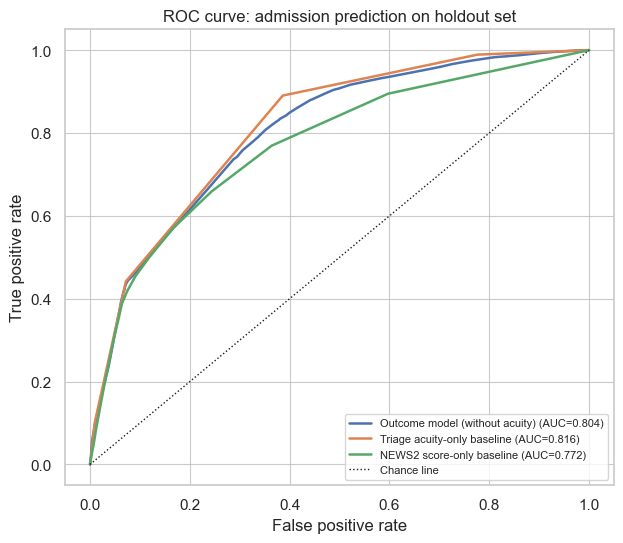

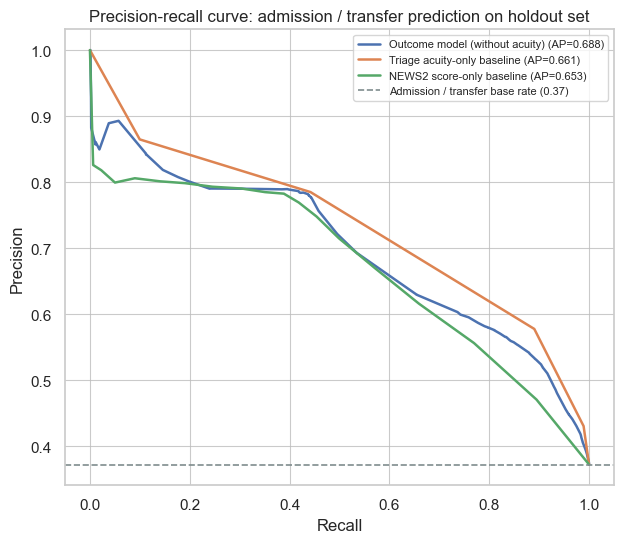

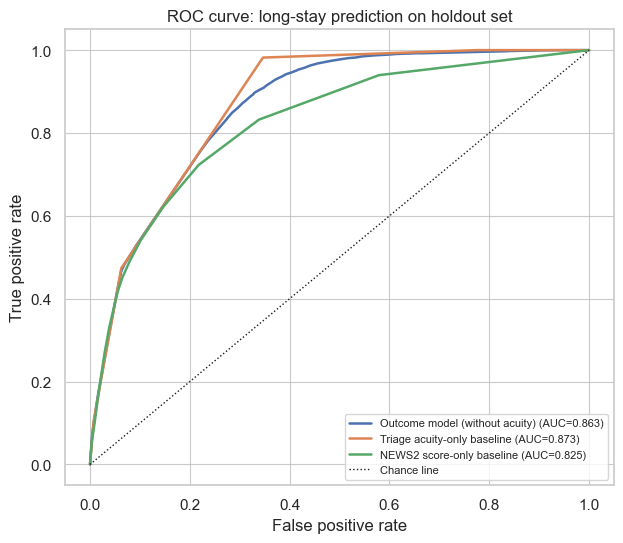

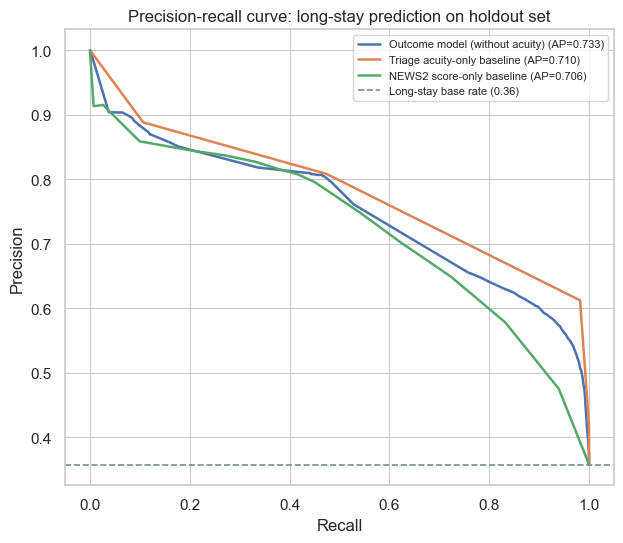

Saved: fig_roc_overlay_admitted/longstay.png, fig_pr_overlay_admitted/longstay.png


In [23]:
# --- Task 2: ROC + PR overlay curves (reuse already-computed holdout predictions) ---
stageH_ho = pd.read_parquet(os.path.join(PROCESSED_DIR, "stageH_holdout_predictions.parquet"))

def overlay_curves(
    target,
    prob_col,
    tag,
    roc_title=None,
    roc_label_map=None,
    roc_grid=False,
    pr_title=None,
    pr_label_map=None,
    pr_base_rate_label=None,
    pr_grid=False,
):
    y = holdout_df[target].values
    p_stageH = stageH_ho[prob_col].values
    rate_map = train_df.groupby(config.TARGET_ACUITY)[target].mean()
    p_acuity = holdout_df[config.TARGET_ACUITY].map(rate_map).values
    nmin, nmax = float(train_df["news2_score"].min()), float(train_df["news2_score"].max())
    p_news2 = (holdout_df["news2_score"].values - nmin) / (nmax - nmin)
    preds = [("Outcome model (no acuity)", p_stageH), ("acuity-only", p_acuity), ("NEWS2-only", p_news2)]
    base_rate = float(y.mean())
    roc_labels = roc_label_map or {}
    pr_labels = pr_label_map or {}

    fig, ax = plt.subplots(figsize=(6.4, 5.6))
    for name, p in preds:
        fpr, tpr, _ = roc_curve(y, p)
        disp = roc_labels.get(name, name)
        ax.plot(fpr, tpr, lw=1.8, label=f"{disp} (AUC={roc_auc_score(y, p):.3f})")
    ax.plot([0, 1], [0, 1], "k:", lw=1, label=roc_labels.get("chance", "chance"))
    ax.set_title(roc_title if roc_title else f"ROC overlay - {target} (holdout)")
    ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
    if roc_grid:
        ax.set_axisbelow(True)
        ax.grid(True, axis="both", color="#bdbdbd", alpha=0.8, linewidth=0.8)
    ax.legend(fontsize=8, loc="lower right")
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f"fig_roc_overlay_{tag}.png"), dpi=150, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(6.4, 5.6))
    for name, p in preds:
        prec, rec, _ = precision_recall_curve(y, p)
        disp = pr_labels.get(name, name)
        ax.plot(rec, prec, lw=1.8, label=f"{disp} (AP={average_precision_score(y, p):.3f})")
    base_lbl = pr_base_rate_label if pr_base_rate_label else "base rate"
    ax.axhline(base_rate, ls="--", color="#7f8c8d", lw=1.2, label=f"{base_lbl} ({base_rate:.2f})")
    ax.set_title(pr_title if pr_title else f"Precision-Recall overlay - {target} (holdout)")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    if pr_grid:
        ax.set_axisbelow(True)
        ax.grid(True, axis="both", color="#bdbdbd", alpha=0.8, linewidth=0.8)
    ax.legend(fontsize=8, loc="upper right")
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f"fig_pr_overlay_{tag}.png"), dpi=150, bbox_inches="tight")
    plt.show()

overlay_curves(
    config.TARGET_ADMIT,
    "prob_admit",
    "admitted",
    roc_title="ROC curve: admission prediction on holdout set",
    roc_label_map={
        "Outcome model (no acuity)": "Outcome model (without acuity)",
        "acuity-only": "Triage acuity-only baseline",
        "NEWS2-only": "NEWS2 score-only baseline",
        "chance": "Chance line",
    },
    roc_grid=True,
    pr_title="Precision-recall curve: admission / transfer prediction on holdout set",
    pr_label_map={
        "Outcome model (no acuity)": "Outcome model (without acuity)",
        "acuity-only": "Triage acuity-only baseline",
        "NEWS2-only": "NEWS2 score-only baseline",
    },
    pr_base_rate_label="Admission / transfer base rate",
    pr_grid=True,
)
overlay_curves(
    config.TARGET_LONG_STAY,
    "prob_long_stay",
    "longstay",
    roc_title="ROC curve: long-stay prediction on holdout set",
    roc_label_map={
        "Outcome model (no acuity)": "Outcome model (without acuity)",
        "acuity-only": "Triage acuity-only baseline",
        "NEWS2-only": "NEWS2 score-only baseline",
        "chance": "Chance line",
    },
    roc_grid=True,
    pr_title="Precision-recall curve: long-stay prediction on holdout set",
    pr_label_map={
        "Outcome model (no acuity)": "Outcome model (without acuity)",
        "acuity-only": "Triage acuity-only baseline",
        "NEWS2-only": "NEWS2 score-only baseline",
    },
    pr_base_rate_label="Long-stay base rate",
    pr_grid=True,
)
print("Saved: fig_roc_overlay_admitted/longstay.png, fig_pr_overlay_admitted/longstay.png")


**Figure:** Synthetic admission/transfer outcome ROC overlay.

![Synthetic admission/transfer outcome ROC overlay](../outputs/figures/fig_roc_overlay_admitted.png)


**Figure:** Synthetic long-stay outcome ROC overlay.

![Synthetic long-stay outcome ROC overlay](../outputs/figures/fig_roc_overlay_longstay.png)


**Figure:** Synthetic admission/transfer outcome precision-recall overlay.

![Synthetic admission/transfer outcome precision-recall overlay](../outputs/figures/fig_pr_overlay_admitted.png)


**Figure:** Synthetic long-stay outcome precision-recall overlay.

![Synthetic long-stay outcome precision-recall overlay](../outputs/figures/fig_pr_overlay_longstay.png)


In [24]:
# --- Task 3: one bounded hyperparameter run, judged on PR-AUC + within-band separation ---
# Composite score = overall CV PR-AUC + 0.5*(within-band OOF ROC for acuity 3 & 4).
# Selection is NOT aggregate ROC-AUC. Within-band separation = the deployed (full-data) model's
# OOF ROC restricted to each band - exactly what the Gap Index would rely on.
N_ITER = 10
rng = np.random.RandomState(config.SEED)
SPACE = dict(num_leaves=[15, 31, 63, 127], min_child_samples=[20, 50, 100, 200],
             learning_rate=[0.03, 0.05, 0.1], n_estimators=[200, 300, 400],
             reg_lambda=[0.0, 1.0, 5.0], colsample_bytree=[0.7, 0.8, 1.0])

def sample_params():
    p = {k: rng.choice(v) for k, v in SPACE.items()}
    return dict(num_leaves=int(p["num_leaves"]), min_child_samples=int(p["min_child_samples"]),
                learning_rate=float(p["learning_rate"]), n_estimators=int(p["n_estimators"]),
                reg_lambda=float(p["reg_lambda"]), colsample_bytree=float(p["colsample_bytree"]),
                subsample=0.8, subsample_freq=1, max_depth=-1,
                random_state=config.SEED, n_jobs=-1, verbose=-1)

def oof_eval(target, params):
    X = build_X(train_df, FEATURES_PRIMARY); y = train_df[target].values
    acu = train_df[config.TARGET_ACUITY].values
    skf = StratifiedKFold(n_splits=config.CV_FOLDS, shuffle=True, random_state=config.SEED)
    oof = np.zeros(len(y))
    for tri, vai in skf.split(X, y):
        m = lgb.LGBMClassifier(**params); m.fit(X.iloc[tri], y[tri])
        oof[vai] = m.predict_proba(X.iloc[vai])[:, 1]
    pr = float(average_precision_score(y, oof)); roc = float(roc_auc_score(y, oof))
    wb = {}
    for b in (3, 4):
        mask = acu == b
        wb[b] = float(roc_auc_score(y[mask], oof[mask])) if len(np.unique(y[mask])) > 1 else 0.5
    composite = pr + 0.5 * (wb[3] + wb[4])
    return dict(pr=pr, roc=roc, wb3=wb[3], wb4=wb[4], composite=composite)

tuning_rows = []
for target in (config.TARGET_ADMIT, config.TARGET_LONG_STAY):
    base = oof_eval(target, LGB_PARAMS)
    best, best_params = None, None
    for _ in range(N_ITER):
        params = sample_params()
        res = oof_eval(target, params)
        if best is None or res["composite"] > best["composite"]:
            best, best_params = res, params
    improved_pr = best["pr"] > base["pr"] + 0.005
    improved_wb = (0.5 * (best["wb3"] + best["wb4"])) > (0.5 * (base["wb3"] + base["wb4"])) + 0.02
    if improved_pr or improved_wb:
        decision = "ADOPT (tuned improves PR-AUC and/or within-band separation)"
    else:
        decision = ("REJECT (keep Step-5 model): tuning did not improve within-band separation; "
                    "the ceiling is in the data, not the model")
    tuning_rows.append(dict(
        target=target,
        chosen_params={k: best_params[k] for k in ("num_leaves", "min_child_samples",
                       "learning_rate", "n_estimators", "reg_lambda", "colsample_bytree")},
        base_cv_pr_auc=round(base["pr"], 4), tuned_cv_pr_auc=round(best["pr"], 4),
        base_cv_roc_auc=round(base["roc"], 4), tuned_cv_roc_auc=round(best["roc"], 4),
        base_wb_roc_b3=round(base["wb3"], 4), tuned_wb_roc_b3=round(best["wb3"], 4),
        base_wb_roc_b4=round(base["wb4"], 4), tuned_wb_roc_b4=round(best["wb4"], 4),
        decision=decision))

tuning_result_df = pd.DataFrame(tuning_rows)
tuning_result_df.to_csv(os.path.join(TABLE_DIR, "table_tuning_result.csv"), index=False)

print("=== Task 3: bounded tuning (CV only; holdout NOT touched) ===")
for r in tuning_rows:
    print(f"\n[{r['target']}]")
    print(f"  chosen params: {r['chosen_params']}")
    print(f"  PR-AUC : {r['base_cv_pr_auc']} -> {r['tuned_cv_pr_auc']}  (delta {r['tuned_cv_pr_auc']-r['base_cv_pr_auc']:+.4f})")
    print(f"  ROC-AUC: {r['base_cv_roc_auc']} -> {r['tuned_cv_roc_auc']}  (delta {r['tuned_cv_roc_auc']-r['base_cv_roc_auc']:+.4f})")
    print(f"  within-band ROC b3: {r['base_wb_roc_b3']} -> {r['tuned_wb_roc_b3']}  | b4: {r['base_wb_roc_b4']} -> {r['tuned_wb_roc_b4']}")
    print(f"  DECISION: {r['decision']}")


=== Task 3: bounded tuning (CV only; holdout NOT touched) ===

[is_admitted]
  chosen params: {'num_leaves': 15, 'min_child_samples': 200, 'learning_rate': 0.05, 'n_estimators': 300, 'reg_lambda': 0.0, 'colsample_bytree': 0.7}
  PR-AUC : 0.6995 -> 0.6992  (delta -0.0003)
  ROC-AUC: 0.8059 -> 0.8063  (delta +0.0004)
  within-band ROC b3: 0.4977 -> 0.4975  | b4: 0.4921 -> 0.4923
  DECISION: REJECT (keep Step-5 model): tuning did not improve within-band separation; the ceiling is in the data, not the model

[is_long_stay]
  chosen params: {'num_leaves': 15, 'min_child_samples': 200, 'learning_rate': 0.03, 'n_estimators': 400, 'reg_lambda': 5.0, 'colsample_bytree': 1.0}
  PR-AUC : 0.751 -> 0.7515  (delta +0.0005)
  ROC-AUC: 0.8644 -> 0.8649  (delta +0.0005)
  within-band ROC b3: 0.5005 -> 0.5018  | b4: 0.4749 -> 0.4801
  DECISION: REJECT (keep Step-5 model): tuning did not improve within-band separation; the ceiling is in the data, not the model


### 6d - Diagnostic verdict

#### Task 1 - within-band signal test: **NO_SIGNAL**

The decisive diagnostic is the within-band signal test. After conditioning on acuity band, the Section 6 feature set carries essentially no residual predictive signal for either outcome.

| Target                     | Band |      n | Base rate | OOF ROC-AUC | OOF average precision (AP) | Spearman |
| -------------------------- | ---: | -----: | --------: | ----------: | -------------------------: | -------: |
| Admission/transfer outcome |    3 | 23,092 |     0.465 |       0.496 |                      0.461 |    -0.01 |
| Admission/transfer outcome |    4 | 18,515 |     0.128 |       0.500 |                      0.126 |    -0.00 |
| Long-stay outcome          |    3 | 23,092 |     0.499 |       0.494 |                      0.494 |    -0.01 |
| Long-stay outcome          |    4 | 18,515 |     0.023 |       0.473 |                      0.021 |    -0.01 |

Across all four tests, within-band ROC-AUC remains close to the **0.50 null line**, AP is approximately equal to the corresponding band base rate, and Spearman correlations are close to zero. This indicates that, once acuity band is fixed, the model no longer ranks patients meaningfully by admission/transfer or long-stay outcome.

This result supports the synthetic-data circularity finding from another direction. In the synthetic benchmark, the structured intake features separate risk mainly **between** acuity bands rather than **within** them. Therefore, the whole-cohort AP gain observed earlier appears to come from broad severity ordering, not from exploitable residual variation among patients assigned to the same acuity level.

#### Gap Index verdict

The **Triage Gap Index is not viable as a within-band risk re-ranker on the synthetic dataset**. A gap-index analysis requires residual within-band variation: for example, evidence that one acuity-3 patient is meaningfully higher risk than another acuity-3 patient using triage-time features alone. In this synthetic dataset, that residual structure is not present.

For that reason, the notebook records the negative result and does not build the Gap Index on the synthetic data. This is an important methodological decision: rather than forcing an unsupported under-triage score, the analysis treats the absence of within-band signal as evidence about the benchmark itself.

#### Task 2 - ROC and PR overlay curves

The overlay curves, `fig_roc_overlay_*` and `fig_pr_overlay_*`, provide an honest side-by-side comparison of the no-acuity outcome model, the triage acuity-only baseline, and the NEWS2-only reference model on the holdout set.

These figures reuse the already-computed Section 6 holdout predictions. No refitting is performed, and no additional holdout-based model selection is introduced. The overlays visualise the mixed synthetic result directly: acuity-only modelling slightly edges aggregate ROC-AUC, while the outcome model improves AP.

#### Task 3 - bounded hyperparameter check: **REJECT**

A bounded hyperparameter check was run using 10 candidates and five-fold cross-validation on `train_df`, while keeping the holdout untouched. Selection was judged using AP and within-band ROC in acuity bands 3 and 4, rather than aggregate ROC-AUC alone.

| Target                     |           CV AP |      CV ROC-AUC | Within-band ROC, band 3 / band 4 | Decision   |
| -------------------------- | --------------: | --------------: | -------------------------------: | ---------- |
| Admission/transfer outcome | 0.6995 → 0.6992 | 0.8059 → 0.8063 |    0.498 → 0.498 / 0.492 → 0.492 | **REJECT** |
| Long-stay outcome          | 0.7510 → 0.7515 | 0.8644 → 0.8649 |    0.501 → 0.502 / 0.475 → 0.480 | **REJECT** |

The tuning pass does not produce a meaningful improvement. AP and aggregate ROC-AUC change by at most approximately **0.0005**, and within-band ROC remains close to the null range. The lack of improvement suggests that the within-band ceiling is driven by the synthetic data structure rather than by an obviously under-tuned model.

The original Section 6 model is therefore retained as the headline synthetic outcome model, and no additional holdout re-evaluation is spent.

#### Plain conclusion

The diagnostic answers are clear:

1. **Does within-band signal exist in the synthetic dataset?**
   No. The within-band tests return **NO_SIGNAL**, so the Gap Index is gated off for the synthetic data.

2. **Did bounded tuning change the headline model?**
   No. The tuned candidates do not materially improve AP, ROC-AUC, or within-band separation, so the original Section 6 model remains the reported model.

The honest contribution of the synthetic analysis is therefore not a working within-band re-ranking tool. Instead, it is the combination of: a small AP gain in whole-cohort outcome prediction, a strong acuity circularity diagnostic, and a negative within-band result showing that the synthetic benchmark compresses much of the outcome signal into between-band severity structure.

All fitting and selection in this diagnostic use five-fold out-of-fold predictions within `train_df`. The holdout set is not re-used for model selection; the overlay curves only display the already-computed Section 6 holdout predictions. These results are based on synthetic data and do not support clinical claims.

---

## Section 7 - Triage Gap Index

**Decision: the Triage Gap Index is not constructed on the synthetic dataset.**

The Triage Gap Index was explicitly gated on the within-band signal diagnostic in Section 6d. That diagnostic returned **NO_SIGNAL** for both primary outcomes, **admission/transfer** and **long ED stay**, within acuity bands 3 and 4. Within-band OOF ROC-AUC remained close to the **0.50 null line**, AP collapsed to the corresponding band base rate, and Spearman correlations were approximately zero.

This means that, after conditioning on acuity band, the available triage-time features do not meaningfully rank patients by outcome in the synthetic dataset. A within-band re-ranking index requires exploitable residual variation: for example, evidence that one acuity-3 patient is measurably higher risk than another acuity-3 patient using features available at triage. In this synthetic benchmark, that residual structure is not present.

For that reason, the Gap Index is reported as a negative result rather than constructed. This is a deliberate honesty guardrail. Building the index despite the **NO_SIGNAL** diagnostic would risk presenting an unsupported under-triage tool. Instead, the notebook treats the absence of within-band signal as part of the benchmark audit: the synthetic data appears to concentrate outcome information between acuity bands rather than preserving enough residual structure within them.

This section therefore strengthens the project’s core argument. The value of the synthetic analysis is not a deployed re-ranking score, but the evidence that this benchmark does not support such a score under leakage-safe testing.

---


## Section 8 - Secondary Outcome Models: LWBS/LAMA Signal Test

This section is a secondary signal test, not a performance chase. After Section 6d found no meaningful within-band signal for the primary admission/transfer and long-stay outcomes, this section asks whether rarer operational or behavioural outcomes retain any triage-time signal not already captured by acuity.

The two secondary outcomes are:

1. **Left without being seen (LWBS)**, with a base rate of approximately **0.046**;
2. **Left against medical advice (LAMA)**, with a base rate of approximately **0.035**.

These outcomes are clinically and operationally relevant because they may reflect patient flow, waiting-time pressure, perceived urgency, or mismatch between patient need and service capacity. However, they are rare events, so the evaluation does not rely on plain accuracy, which would be misleading. Instead, the section prioritises **average precision (AP)**, AP relative to the outcome base rate, and rare-event enrichment measures such as top-decile lift.

The same leakage-safe feature pipeline used for the primary outcome models is retained. The feature set, `FEATURES_PRIMARY`, excludes `triage_acuity`, `disposition`, `ed_los_hours`, and all derived target variables. The same fixed LightGBM model family is used without tuning, so the section remains a controlled signal test rather than an optimisation exercise.

All model development is performed within `train_df`, and the holdout set is evaluated only once at the end. The purpose is to determine whether LWBS or LAMA contain any residual triage-time signal that could support a secondary benchmark insight, while maintaining the same anti-leakage standards used throughout the notebook.


In [25]:
# --- Secondary outcome setup: leakage-safe features, rare-class helpers, baseline scorers ---
from sklearn.metrics import precision_recall_curve, roc_auc_score, average_precision_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold

STAGEI_TARGETS = [config.TARGET_LWBS, config.TARGET_LAMA]   # is_lwbs, is_lama

# Hard leakage guard: prove the feature set cannot see disposition / outcomes / wait / LOS.
_BANNED_SUBSTR = ["disposition", "los", "wait", "left", "discharge", "admit", "admitted",
                  "long_stay", "lwbs", "lama", "deceased", "outcome", "acuity"]
_leaky = [f for f in FEATURES_PRIMARY
          if any(b in f.lower() for b in _BANNED_SUBSTR)]
assert not _leaky, f"Leakage guard tripped - banned columns in features: {_leaky}"
assert config.TARGET_ACUITY not in FEATURES_PRIMARY
print(f"Secondary outcome features: {len(FEATURES_PRIMARY)} columns, leakage guard clean (no acuity/disposition/LOS/wait).")

def enrichment(y, score, base):
    """Rare-event ranking metrics from a score (higher = higher predicted risk)."""
    y = np.asarray(y); score = np.asarray(score)
    order = np.argsort(-score, kind="stable")
    ys = y[order]; n = len(y); npos = y.sum()
    def prec_at(frac):
        k = max(1, int(round(frac * n)))
        return float(ys[:k].mean())
    def recall_at(frac):
        k = max(1, int(round(frac * n)))
        return float(ys[:k].sum() / npos) if npos > 0 else float("nan")
    ap = float(average_precision_score(y, score))
    top10 = prec_at(0.10)
    return dict(
        pr_auc=ap, roc_auc=float(roc_auc_score(y, score)),
        ap_lift_over_base=float(ap / base) if base > 0 else float("nan"),
        precision_at_top_5pct=prec_at(0.05), precision_at_top_10pct=top10,
        recall_at_top_10pct=recall_at(0.10), top_decile_observed_rate=top10,
        top_decile_lift=float(top10 / base) if base > 0 else float("nan"))

def fit_lgbm_spw(X, y, params):
    """LightGBM with scale_pos_weight computed on THIS training split only."""
    npos = int(np.sum(y)); nneg = int(len(y) - npos)
    spw = (nneg / npos) if npos > 0 else 1.0
    return lgb.LGBMClassifier(**{**params, "scale_pos_weight": spw}).fit(X, y), spw

def stageI_verdict(ap, base, ap_acuity, top_lift):
    if (ap >= base + 0.05) and (ap >= ap_acuity + 0.02) and (top_lift >= 2.0):
        return "SIGNAL"
    beats = (ap > base) and (ap > ap_acuity)
    if beats or (top_lift >= 1.5):
        return "WEAK_SIGNAL"
    return "NO_SIGNAL"
print("Secondary outcome helpers ready.")


Secondary outcome features: 62 columns, leakage guard clean (no acuity/disposition/LOS/wait).
Secondary outcome helpers ready.


In [26]:
# --- Secondary outcome: baselines + LightGBM signal model; holdout scored ONCE per target ---
stageI_rows, stageI_ops, stageI_scores, stageI_meta = [], [], {}, {}

for tgt in STAGEI_TARGETS:
    y_tr = train_df[tgt].values
    y_ho = holdout_df[tgt].values
    base = float(y_ho.mean())                      # holdout positive base rate (PR reference)
    base_tr = float(y_tr.mean())

    # ---- baseline scores on holdout ----
    maj_score = np.full(len(y_ho), base_tr)        # constant
    nmin, nmax = float(train_df["news2_score"].min()), float(train_df["news2_score"].max())
    news_score = (holdout_df["news2_score"].values - nmin) / (nmax - nmin if nmax > nmin else 1.0)
    rate_map = train_df.groupby(config.TARGET_ACUITY)[tgt].mean()
    acu_score = holdout_df[config.TARGET_ACUITY].map(rate_map).fillna(base_tr).values

    # NEWS2 direction check (higher severity -> higher predicted risk?)
    news_roc = float(roc_auc_score(y_ho, news_score))
    news_dir = "higher NEWS2 -> higher risk" if news_roc >= 0.5 else "INVERSE (higher NEWS2 -> lower risk)"

    # ---- LightGBM: 5-fold stratified OOF (scale_pos_weight per fold) ----
    X_tr = build_X(train_df, FEATURES_PRIMARY)
    X_ho = build_X(holdout_df, FEATURES_PRIMARY)
    skf = StratifiedKFold(n_splits=config.CV_FOLDS, shuffle=True, random_state=config.SEED)
    oof = np.zeros(len(y_tr)); cv_pr, cv_roc = [], []
    for tri, vai in skf.split(X_tr, y_tr):
        m, _ = fit_lgbm_spw(X_tr.iloc[tri], y_tr[tri], LGB_PARAMS)
        p = m.predict_proba(X_tr.iloc[vai])[:, 1]
        oof[vai] = p
        cv_pr.append(average_precision_score(y_tr[vai], p))
        cv_roc.append(roc_auc_score(y_tr[vai], p))
    # final full-train refit (scale_pos_weight on full train) -> holdout ONCE
    final, spw_full = fit_lgbm_spw(X_tr, y_tr, LGB_PARAMS)
    lgb_score = final.predict_proba(X_ho)[:, 1]

    # ---- enrichment metrics for every predictor ----
    preds = {"majority_class": maj_score, "news2_only": news_score,
             "acuity_only": acu_score, "lightgbm": lgb_score}
    enr = {name: enrichment(y_ho, s, base) for name, s in preds.items()}
    ap_acuity = enr["acuity_only"]["pr_auc"]

    verdict = stageI_verdict(enr["lightgbm"]["pr_auc"], base, ap_acuity,
                             enr["lightgbm"]["top_decile_lift"])

    for name in ["majority_class", "news2_only", "acuity_only", "lightgbm"]:
        e = enr[name]
        stageI_rows.append(dict(
            target=tgt, model=name, base_rate=round(base, 4),
            pr_auc_or_average_precision=round(e["pr_auc"], 4), roc_auc=round(e["roc_auc"], 4),
            ap_lift_over_base=round(e["ap_lift_over_base"], 3),
            delta_ap_vs_acuity=round(e["pr_auc"] - ap_acuity, 4),
            precision_at_top_5pct=round(e["precision_at_top_5pct"], 4),
            precision_at_top_10pct=round(e["precision_at_top_10pct"], 4),
            recall_at_top_10pct=round(e["recall_at_top_10pct"], 4),
            top_decile_observed_rate=round(e["top_decile_observed_rate"], 4),
            top_decile_lift=round(e["top_decile_lift"], 3),
            verdict=verdict if name == "lightgbm" else ""))

    # ---- operating points ----
    # (i) LightGBM at max-F1 threshold chosen on TRAIN OOF, applied to holdout
    prec_c, rec_c, thr_c = precision_recall_curve(y_tr, oof)
    f1 = np.divide(2 * prec_c * rec_c, prec_c + rec_c,
                   out=np.zeros_like(prec_c), where=(prec_c + rec_c) > 0)
    t_f1 = float(thr_c[max(0, np.argmax(f1) - 1)]) if len(thr_c) else 0.5
    # (ii) LightGBM capacity point: flag highest-risk 10% of holdout
    t_cap = float(np.quantile(lgb_score, 0.90))

    def op_row(model, strat, thr, score):
        pred = (score >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_ho, pred, labels=[0, 1]).ravel()
        return dict(target=tgt, model=model, threshold_strategy=strat, threshold=round(thr, 4),
                    precision=round(tp / (tp + fp), 4) if (tp + fp) else float("nan"),
                    recall=round(tp / (tp + fn), 4) if (tp + fn) else float("nan"),
                    specificity=round(tn / (tn + fp), 4) if (tn + fp) else float("nan"),
                    tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp))
    stageI_ops.append(op_row("lightgbm", "max_f1_on_train_oof", t_f1, lgb_score))
    stageI_ops.append(op_row("lightgbm", "top_10pct_capacity", t_cap, lgb_score))
    stageI_ops.append(op_row("acuity_only", "top_10pct_capacity",
                             float(np.quantile(acu_score, 0.90)), acu_score))

    stageI_scores[tgt] = dict(preds=preds, y=y_ho, base=base)
    stageI_meta[tgt] = dict(cv_pr=cv_pr, cv_roc=cv_roc, verdict=verdict, spw_full=spw_full,
                            news_dir=news_dir, news_roc=news_roc, ap_acuity=ap_acuity,
                            lgb_ap=enr["lightgbm"]["pr_auc"], lgb_roc=enr["lightgbm"]["roc_auc"],
                            top_lift=enr["lightgbm"]["top_decile_lift"])

    print(f"\n[{tgt}] base_rate={base:.4f}  scale_pos_weight(full)={spw_full:.2f}")
    print(f"  CV OOF: AP={np.mean(cv_pr):.4f}+/-{np.std(cv_pr):.4f}  ROC={np.mean(cv_roc):.4f}+/-{np.std(cv_roc):.4f}")
    print(f"  Holdout LightGBM: AP={enr['lightgbm']['pr_auc']:.4f}  ROC={enr['lightgbm']['roc_auc']:.4f}  "
          f"top-decile lift={enr['lightgbm']['top_decile_lift']:.2f}")
    print(f"  acuity-only AP={ap_acuity:.4f}  ->  delta_AP(lgbm-acuity)={enr['lightgbm']['pr_auc']-ap_acuity:+.4f}")
    print(f"  NEWS2 direction: {news_dir} (ROC={news_roc:.3f})")
    print(f"  VERDICT: {verdict}")

stageI_results_df = pd.DataFrame(stageI_rows)
stageI_ops_df = pd.DataFrame(stageI_ops)
stageI_results_df.to_csv(os.path.join(TABLE_DIR, "table_stageI_results.csv"), index=False)
stageI_ops_df.to_csv(os.path.join(TABLE_DIR, "table_stageI_operating_points.csv"), index=False)

print("\n=== Secondary outcome results (holdout) ===")
print(stageI_results_df.to_string(index=False))
print("\n=== Secondary outcome operating points (holdout) ===")
print(stageI_ops_df.to_string(index=False))
print("\nVERDICTS:", {t: stageI_meta[t]["verdict"] for t in STAGEI_TARGETS})



[is_lwbs] base_rate=0.0457  scale_pos_weight(full)=20.88
  CV OOF: AP=0.0611+/-0.0015  ROC=0.6146+/-0.0081
  Holdout LightGBM: AP=0.0599  ROC=0.6070  top-decile lift=1.52
  acuity-only AP=0.0614  ->  delta_AP(lgbm-acuity)=-0.0016
  NEWS2 direction: INVERSE (higher NEWS2 -> lower risk) (ROC=0.379)
  VERDICT: WEAK_SIGNAL

[is_lama] base_rate=0.0346  scale_pos_weight(full)=27.95
  CV OOF: AP=0.0422+/-0.0013  ROC=0.5806+/-0.0076
  Holdout LightGBM: AP=0.0444  ROC=0.5978  top-decile lift=1.36
  acuity-only AP=0.0464  ->  delta_AP(lgbm-acuity)=-0.0021
  NEWS2 direction: INVERSE (higher NEWS2 -> lower risk) (ROC=0.398)
  VERDICT: NO_SIGNAL

=== Secondary outcome results (holdout) ===
 target          model  base_rate  pr_auc_or_average_precision  roc_auc  ap_lift_over_base  delta_ap_vs_acuity  precision_at_top_5pct  precision_at_top_10pct  recall_at_top_10pct  top_decile_observed_rate  top_decile_lift     verdict
is_lwbs majority_class     0.0457                       0.0457   0.5000        

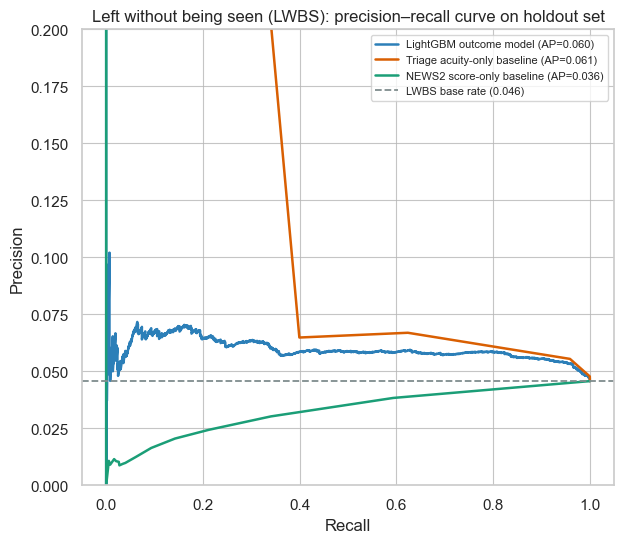

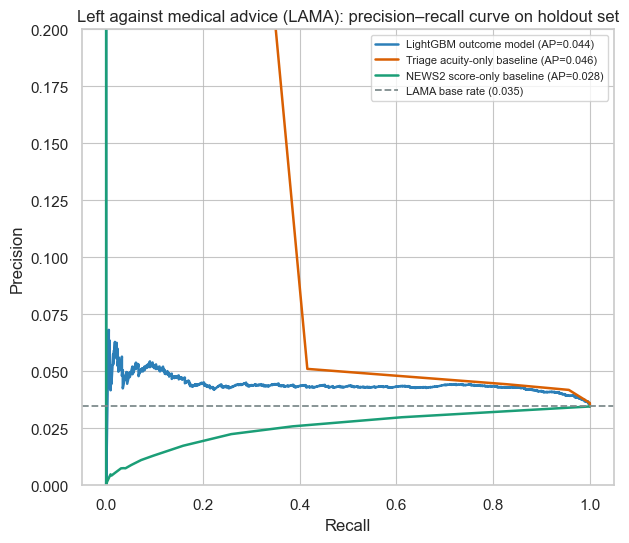

Saved: fig_stageI_lwbs_pr.png, fig_stageI_lama_pr.png


In [27]:
# --- Secondary outcome PR-curve overlays (LightGBM vs acuity-only vs NEWS2-only + base-rate ref) ---
_fig_tags = {config.TARGET_LWBS: "lwbs", config.TARGET_LAMA: "lama"}
_curve_models = [("lightgbm", "#2c7fb8"), ("acuity_only", "#d95f02"), ("news2_only", "#1b9e77")]
_legend_names = {
    "lightgbm": "LightGBM outcome model",
    "acuity_only": "Triage acuity-only baseline",
    "news2_only": "NEWS2 score-only baseline",
}
_base_rate_label_by_tag = {
    "lwbs": "LWBS base rate",
    "lama": "LAMA base rate",
}
_title_by_tag = {
    "lwbs": "Left without being seen (LWBS): precision–recall curve on holdout set",
    "lama": "Left against medical advice (LAMA): precision–recall curve on holdout set",
}

for tgt, tag in _fig_tags.items():
    d = stageI_scores[tgt]; y = d["y"]; base = d["base"]
    fig, ax = plt.subplots(figsize=(6.4, 5.6))
    for name, col in _curve_models:
        s = d["preds"][name]
        prec, rec, _ = precision_recall_curve(y, s)
        ap = average_precision_score(y, s)
        ax.plot(rec, prec, lw=1.8, color=col,
                label=f"{_legend_names[name]} (AP={ap:.3f})")
    ax.axhline(base, ls="--", color="#7f8c8d", lw=1.3,
               label=f"{_base_rate_label_by_tag[tag]} ({base:.3f})")
    ax.set_title(_title_by_tag[tag])
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_ylim(0, max(0.2, base * 4))
    ax.set_axisbelow(True)
    ax.grid(True, which="major", axis="both", color="#b7b7b7", alpha=0.8, linewidth=0.8)
    ax.legend(fontsize=8, loc="upper right")
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f"fig_stageI_{tag}_pr.png"), dpi=150, bbox_inches="tight")
    plt.show()
print("Saved: fig_stageI_lwbs_pr.png, fig_stageI_lama_pr.png")


**Figure:** Secondary outcome model precision-recall: leaving without being seen (LWBS).

![Secondary outcome model precision-recall: leaving without being seen (LWBS)](../outputs/figures/fig_stageI_lwbs_pr.png)


**Figure:** Secondary outcome model precision-recall: leaving against medical advice (LAMA).

![Secondary outcome model precision-recall: leaving against medical advice (LAMA)](../outputs/figures/fig_stageI_lama_pr.png)


In [28]:
# --- Secondary outcome SHAP: ONLY for targets with SIGNAL/WEAK_SIGNAL (skip pure noise) ---
import shap
_shap_targets = [t for t in STAGEI_TARGETS if stageI_meta[t]["verdict"] in ("SIGNAL", "WEAK_SIGNAL")]
PLAUSIBLE_HINTS = ["arrival", "hour", "mode", "prior", "visit", "complaint", "age", "sex",
                   "gender", "comorb", "history", "insurance", "race", "ethnic", "triage_time"]

if not _shap_targets:
    print("All Secondary outcome targets returned NO_SIGNAL -> SHAP skipped (avoid over-interpreting noise).")
else:
    shap_rows = []
    for tgt in _shap_targets:
        X_tr = build_X(train_df, FEATURES_PRIMARY)
        X_ho = build_X(holdout_df, FEATURES_PRIMARY)
        mdl, _ = fit_lgbm_spw(X_tr, train_df[tgt].values, LGB_PARAMS)
        samp = X_ho.sample(n=min(2000, len(X_ho)), random_state=config.SEED)
        sv = shap.TreeExplainer(mdl).shap_values(samp)
        sv = sv[1] if isinstance(sv, list) else sv
        imp = pd.DataFrame({"feature": X_ho.columns,
                            "mean_abs_shap": np.abs(sv).mean(axis=0)}
                           ).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
        imp.insert(0, "rank", imp.index + 1); imp.insert(0, "target", tgt)
        shap_rows.append(imp.head(15))
        top = imp.head(8)
        plausible = [f for f in top["feature"] if any(h in f.lower() for h in PLAUSIBLE_HINTS)]
        print(f"\n[{tgt}] top SHAP drivers: {list(top['feature'])}")
        print(f"  triage-time plausible among top-8: {plausible if plausible else 'NONE flagged'}")
    pd.concat(shap_rows).to_csv(os.path.join(TABLE_DIR, "table_stageI_shap_top_features.csv"), index=False)
    print("\nSaved: table_stageI_shap_top_features.csv")



[is_lwbs] top SHAP drivers: ['gcs_total', 'news2_score', 'respiratory_rate', 'chief_complaint_system', 'mental_status_triage', 'temperature_c', 'spo2', 'mean_arterial_pressure']
  triage-time plausible among top-8: ['chief_complaint_system', 'mental_status_triage']

Saved: table_stageI_shap_top_features.csv


c:\Users\ellab\anaconda3\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


### Interpretation — does any LWBS/LAMA signal survive acuity?

The headline result is predominantly negative. Neither secondary outcome model outperforms the triage acuity-only baseline, and neither target reaches the predefined rare-event **SIGNAL** threshold.

| Target                             | Base rate | LGBM AP | Triage acuity-only AP | AP gain, LGBM − acuity | Top-decile lift | Verdict         |
| ---------------------------------- | --------: | ------: | --------------------: | ---------------------: | --------------: | --------------- |
| Left without being seen (LWBS)     |    0.0457 |  0.0599 |            **0.0614** |            **−0.0016** |           1.52× | **WEAK_SIGNAL** |
| Left against medical advice (LAMA) |    0.0346 |  0.0444 |            **0.0464** |            **−0.0021** |           1.36× | **NO_SIGNAL**   |

#### LWBS — weak enrichment, but not acuity-independent signal

For LWBS, the no-acuity LightGBM model achieves AP **0.0599**, which is above the base rate of **0.0457**, and the top-decile lift reaches **1.52×**. This narrowly crosses the predefined **WEAK_SIGNAL** threshold.

However, this should be interpreted cautiously. The model does **not** outperform the triage acuity-only baseline, which achieves AP **0.0614**. The AP gap is slightly negative, **−0.0016**, indicating that the apparent LWBS enrichment is not a signal beyond acuity.

The SHAP summary supports this interpretation. The leading features are `gcs_total`, `news2_score`, `respiratory_rate`, `temperature_c`, and `spo2`, which are mainly severity and physiology variables. This suggests that the model is re-deriving a weak severity gradient rather than identifying a distinct operational or behavioural pattern. The more operationally interpretable features, such as `chief_complaint_system` and `mental_status_triage`, appear only as secondary drivers.

The practical interpretation is therefore modest: LWBS contains faint rare-event enrichment in the synthetic dataset, but this enrichment is already captured by acuity and does not justify a separate acuity-independent model.

#### LAMA — no exploitable signal

For LAMA, the evidence is weaker. AP reaches **0.0444**, only slightly above the base rate of **0.0346**, and remains below the triage acuity-only baseline of **0.0464**. The top-decile lift is **1.36×**, which does not meet the rare-event signal threshold.

This is therefore reported as **NO_SIGNAL**. SHAP interpretation is not emphasised for this target, because the model does not show enough evidence of meaningful signal to justify detailed feature-level interpretation.

#### NEWS2 directionality

The NEWS2-only runs are inverse for both secondary outcomes, with ROC-AUC **0.379** for LWBS and **0.398** for LAMA. This is operationally plausible: higher-severity patients may be less likely to leave before being seen or leave against medical advice, because they are more clinically unwell or more likely to be prioritised.

This also shows why a naive “higher severity equals higher leaving risk” rule would be inappropriate for these behavioural outcomes. LWBS and LAMA are not simple severity outcomes, even though the weak signal detected here still appears to be largely acuity-linked.

#### Plain answers

1. **Does LWBS contain signal?**
   Only weak enrichment. It narrowly meets the **WEAK_SIGNAL** rule through top-decile lift, but it does not outperform acuity-only prediction.

2. **Does LAMA contain signal?**
   No. The result is reported as **NO_SIGNAL**.

3. **Does either target beat triage acuity-only?**
   No. Both AP gaps are negative.

4. **Is there meaningful rare-event enrichment?**
   Not enough to support a separate model. LWBS reaches **1.52×** top-decile lift, while LAMA reaches **1.36×**; neither reaches the **2.0× SIGNAL** threshold.

#### Conclusion

This is a valid negative finding. Consistent with the primary outcome analysis and the Section 6d within-band diagnostic, the synthetic dataset does not provide strong evidence of operational LWBS/LAMA signal beyond what acuity already captures.

The section therefore does not manufacture a behavioural risk model from sub-threshold enrichment. Instead, it reports the result as part of the benchmark audit: in this synthetic data, the available triage-time features do not support a robust acuity-independent signal for LWBS or LAMA.

These are dataset-internal signal tests on synthetic competition data. They do not support clinical claims about real LWBS or LAMA behaviour.

---



## Section 9 - Real-Data Replication: NHAMCS 2022

This section tests whether the synthetic-data finding replicates on real emergency department data. The synthetic analysis suggested that structured triage variables mostly encode severity or urgency, leaving limited outcome signal beyond the triage acuity label. NHAMCS 2022 is used as an external validity check: does the same conclusion hold in a real, nationally sampled ED dataset?

The NHAMCS analysis is kept strictly siloed from the synthetic dataset. The datasets are never pooled, and the NHAMCS results are interpreted as a conceptual replication rather than as an exact one-to-one comparison. The NHAMCS variable `IMMEDR`, a five-level triage-immediacy measure, is treated as the closest available analogue to the synthetic ESI-style `triage_acuity`. Because `IMMEDR` is not identical to ESI, all comparisons are framed cautiously as evidence of whether the same audit pattern holds under a real-data acuity proxy.

Survey weights (`PATWT`) are used only for descriptive population estimates. They are not used as model features, and the predictive models are trained unweighted. The modelling results are therefore interpreted as ranking evaluation within the constructed analysis sample, while weighted summaries are reserved for population-level description where appropriate.

This section does not assume that real-data replication must be positive. A negative, partial, or divergent result would all be valid findings. The purpose is to test whether the synthetic benchmark conclusion survives contact with a real ED dataset, rather than to force agreement across data sources.


In [29]:
# --- Step 1: load NHAMCS, validate IMMEDR/PATWT, confirm codebook variables ---
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (roc_auc_score, average_precision_score, balanced_accuracy_score,
                             confusion_matrix, precision_recall_curve)
import lightgbm as lgb

NHAMCS_CSV = os.path.join("data", "nhamcs", "nhamcs2022.csv")
nh_raw = pd.read_csv(NHAMCS_CSV, low_memory=False)
print(f"NHAMCS raw shape: {nh_raw.shape[0]} rows x {nh_raw.shape[1]} cols")

# IMMEDR: valid immediacy levels are 1..5 (1=immediate ... 5=nonurgent). Drop anything else
# (blank/unknown/no-triage codes such as <=0 or 7). triage_acuity in this file == IMMEDR exactly.
VALID_IMMEDR = [1, 2, 3, 4, 5]
_before = len(nh_raw)
nh = nh_raw[nh_raw["IMMEDR"].isin(VALID_IMMEDR)].copy()
print(f"IMMEDR filter: kept {len(nh)} / {_before} rows (dropped {_before - len(nh)} invalid/blank IMMEDR).")
assert (nh["PATWT"] > 0).all(), "PATWT must be positive for all retained rows"
print(f"PATWT: all positive, range [{nh['PATWT'].min():.1f}, {nh['PATWT'].max():.1f}].")

# Confirm triage_acuity is a 1:1 copy of IMMEDR (so both are excluded from features)
assert (nh["IMMEDR"].astype(int) == nh["triage_acuity"].astype(int)).all(), \
    "triage_acuity is expected to equal IMMEDR in this file"
print("Confirmed: triage_acuity == IMMEDR (harmonised copy) -> both excluded from primary features.")

# --- Codebook correction (official 2022 NHAMCS ED codebook, doc22-ed-508.pdf) ---
# The shipped hx_* names were verified earlier by row-agreement (same column) but NOT against the
# codebook (correct label). We now fix the labels. This is a RENAME ONLY: the underlying columns and
# their ORDER are preserved, so model inputs are byte-identical and no metric can change.
NHAMCS_CODEBOOK_URL = "https://ftp.cdc.gov/pub/Health_Statistics/NCHS/dataset_documentation/nhamcs/doc22-ed-508.pdf"
RAW2MEANING = {
    "HTN": "hypertension", "DIABTYP2": "diabetes_type2", "DIABTYP1": "diabetes_type1",
    "ASTHMA": "asthma", "COPD": "copd", "CHF": "congestive_heart_failure",
    "CKD": "chronic_kidney_disease", "CANCER": "cancer", "DEPRN": "depression",
    "CAD": "coronary_artery_disease", "ETOHAB": "alcohol_misuse", "SUBSTAB": "substance_abuse",
    "OBESITY": "obesity", "HYPLIPID": "hyperlipidemia", "CEBVD": "cerebrovascular_disease_stroke",
    "ALZHD": "alzheimers_dementia", "OSA": "obstructive_sleep_apnea", "OSTPRSIS": "osteoporosis",
    "EDHIV": "hiv_aids", "HPE": "pulmonary_embolism"}
# harmonised name as shipped in nhamcs2022.csv -> raw NHAMCS code (validated 1:1 in the audit)
OLD_HX_TO_RAW = {
    "hx_hypertension": "HTN", "hx_diabetes_type2": "DIABTYP2", "hx_diabetes_type1": "DIABTYP1",
    "hx_asthma": "ASTHMA", "hx_copd": "COPD", "hx_heart_failure": "CHF", "hx_ckd": "CKD",
    "hx_cancer": "CANCER", "hx_depression": "DEPRN", "hx_coronary_artery_disease": "CAD",
    "hx_alcohol_abuse": "ETOHAB", "hx_substance_abuse": "SUBSTAB", "hx_obesity": "OBESITY",
    "hx_hyperlipidemia": "HYPLIPID", "hx_stroke": "CEBVD", "hx_dementia": "ALZHD",
    "hx_sleep_apnea": "OSA", "hx_osteoporosis": "OSTPRSIS", "hx_hiv": "EDHIV",
    "hx_hepatic_disease": "HPE"}
NHAMCS_HX_RENAME = {old: f"hx_{RAW2MEANING[raw]}" for old, raw in OLD_HX_TO_RAW.items()
                    if f"hx_{RAW2MEANING[raw]}" != old}

# Task 1 - audit current names against codebook truth
_corr = []
for old, raw in OLD_HX_TO_RAW.items():
    correct = f"hx_{RAW2MEANING[raw]}"
    _corr.append(dict(raw_code=raw, old_harmonised_name=old, correct_harmonised_name=correct,
                      was_wrong="Y" if correct != old else "N"))
correction_df = pd.DataFrame(_corr).sort_values(["was_wrong", "raw_code"], ascending=[False, True]).reset_index(drop=True)
correction_df.to_csv(os.path.join(TABLE_DIR, "table_nhamcs_name_corrections.csv"), index=False)
print("\n=== Task 1: comorbidity name corrections vs official 2022 NHAMCS ED codebook ===")
print(correction_df.to_string(index=False))
print(f"  {(correction_df.was_wrong=='Y').sum()} mislabels corrected "
      f"(incl. known error HPE: hepatic_disease -> pulmonary_embolism); "
      f"{(correction_df.was_wrong=='N').sum()} already correct.")

# capture ORIGINAL feature order (sorted by OLD names) BEFORE renaming so model-input order is preserved
_HX_ORIG_ORDER = sorted([c for c in nh.columns if c.startswith("hx_")])
nh = nh.rename(columns=NHAMCS_HX_RENAME)
print(f"  Renamed {len(NHAMCS_HX_RENAME)} columns in `nh`; column ORDER preserved -> model inputs unchanged.")
print(f"  Codebook source: {NHAMCS_CODEBOOK_URL}")

# --- compact variable-confirmation / map table ---
var_map = [
    ("IMMEDR", "Triage immediacy/urgency (NHAMCS analogue of ESI acuity)", "1=immediate..5=nonurgent; valid 1-5 only", "triage_label", "exclude_from_features", "used for IMMEDR-only baseline + descriptive gradient; not a model feature"),
    ("triage_acuity", "Harmonised 1:1 copy of IMMEDR", "1-5", "triage_label", "exclude_from_features", "duplicate of IMMEDR"),
    ("PATWT", "Patient visit survey weight", f"positive float [{nh['PATWT'].min():.0f},{nh['PATWT'].max():.0f}]", "survey_weight", "exclude_from_features", "descriptive weighting ONLY; never trained/feature"),
    ("ed_los_min", "ED length of visit (minutes)", "0-5722 min; 267 missing", "outcome_source", "exclude_from_features", "defines is_long_stay (>=240min); leakage if used as feature"),
    ("LOS", "Hospital length of stay (DAYS, admitted only)", "1-85 days; ~8870 missing", "post_visit", "exclude", "post-hospital, NOT ED LOV - never used"),
    ("ADMITHOS", "Admitted to this hospital", "0/1", "outcome_source", "exclude_from_features", "is_admitted component"),
    ("OBSHOS", "Observation unit -> admitted to hospital", "0/1", "outcome_source", "exclude_from_features", "is_admitted component"),
    ("TRANNH/TRANPSYC/TRANOTH", "Transferred to another facility", "0/1 each", "outcome_source", "exclude_from_features", "is_admitted (transfer) components"),
    ("OBSDIS", "Observation -> discharged", "0/1", "disposition", "exclude", "discharged, NOT admission"),
    ("ADISP", "Single summary disposition (sparse)", "1-4; ~8910 missing", "disposition", "exclude", "too sparse; outcomes built from clean binary flags instead"),
    ("heart_rate/respiratory_rate/systolic_bp/diastolic_bp/spo2/temperature_c/pain_score",
     "Harmonised triage-time vitals", "physiologic ranges; NaN where not recorded", "vital", "include", "triage-time; native-NaN + missing indicators"),
    ("hx_* (20) / comorbidity_count", "Medical history flags", "0/1 / count", "history", "include", "known at triage"),
    ("age/sex/race_ethnicity/insurance_type", "Demographics", "coded", "demographic", "include", "triage-time"),
    ("arrival_hour/night_arrival/arrived_by_ambulance/visit_month/visit_day", "Arrival/timing", "coded", "arrival", "include", "triage-time"),
    ("rfv1_code", "Reason-for-visit (chief complaint) code", "NHAMCS RFV1, Appendix II codes 10050-89990", "complaint", "include", "triage-time; reason-for-visit coding, distinct from ICD-10 DIAG* diagnoses"),
    ("wait_time_min", "Time to be seen (post-triage)", "minutes", "post_triage", "exclude", "only known after triage -> leakage"),
    ("diag1_text/diag2_text/diag3_text", "ED discharge diagnoses", "text", "post_visit", "exclude", "known after visit -> leakage"),
    ("codebook (doc22-ed-508.pdf)", "Official 2022 NHAMCS ED codebook", NHAMCS_CODEBOOK_URL, "provenance", "reference", "all hx_* names cross-checked; HPE corrected hepatic_disease->pulmonary_embolism"),
]
var_map_df = pd.DataFrame(var_map, columns=["variable", "description", "coding_summary",
                                            "role", "include_exclude", "notes"])
var_map_df.to_csv(os.path.join(TABLE_DIR, "table_nhamcs_variable_map.csv"), index=False)
print("\n=== NHAMCS codebook variable confirmation ===")
print(var_map_df[["variable", "role", "include_exclude"]].to_string(index=False))


NHAMCS raw shape: 10207 rows x 967 cols
IMMEDR filter: kept 10207 / 10207 rows (dropped 0 invalid/blank IMMEDR).
PATWT: all positive, range [89.9, 57925.5].
Confirmed: triage_acuity == IMMEDR (harmonised copy) -> both excluded from primary features.

=== Task 1: comorbidity name corrections vs official 2022 NHAMCS ED codebook ===
raw_code        old_harmonised_name           correct_harmonised_name was_wrong
   ALZHD                hx_dementia            hx_alzheimers_dementia         Y
   CEBVD                  hx_stroke hx_cerebrovascular_disease_stroke         Y
     CHF           hx_heart_failure       hx_congestive_heart_failure         Y
     CKD                     hx_ckd         hx_chronic_kidney_disease         Y
   EDHIV                     hx_hiv                       hx_hiv_aids         Y
  ETOHAB           hx_alcohol_abuse                 hx_alcohol_misuse         Y
     HPE         hx_hepatic_disease             hx_pulmonary_embolism         Y
     OSA             hx_slee

In [30]:
# --- Step 2: reconstruct outcomes from the disposition family + ED LOV (no blind dropna) ---
def wstat(mask, w):
    """unweighted n, unweighted rate, weighted positive estimate, weighted rate."""
    mask = mask.astype(int)
    return int(mask.sum()), float(mask.mean()), float((mask * w).sum()), float((mask * w).sum() / w.sum())

W = nh["PATWT"].values

# Target 1: admission/transfer/observation-to-hospital. Clean 0/1 checkbox flags (no NaN) ->
# blank means "not checked" = no, which the checkbox coding supports (no skip-pattern NaN here).
ADMIT_COLS = ["ADMITHOS", "OBSHOS", "TRANNH", "TRANPSYC", "TRANOTH"]
for c in ADMIT_COLS:
    assert nh[c].isin([0, 1]).all(), f"{c} not clean 0/1"
nh["is_admitted_nhamcs"] = (nh[ADMIT_COLS].sum(axis=1) > 0).astype(int)
n1, r1, wp1, wr1 = wstat(nh["is_admitted_nhamcs"], W)
print("is_admitted_nhamcs: ADMITHOS OR OBSHOS OR TRANNH OR TRANPSYC OR TRANOTH (1=any).")
print(f"  unweighted: n_pos={n1}, base_rate={r1:.4f}  |  weighted: est_pos={wp1:,.0f}, base_rate={wr1:.4f}")

# Target 2: long ED stay = ED length of visit >= 4h. Use ed_los_min ONLY (NOT hospital LOS days).
# Targeted exclusion: rows with missing ED LOV cannot define the outcome.
los_ok = nh["ed_los_min"].notna()
cover = float(los_ok.mean())
nh_ls = nh[los_ok].copy()
nh_ls["is_long_stay_nhamcs"] = (nh_ls["ed_los_min"] >= 240).astype(int)
n2, r2, wp2, wr2 = wstat(nh_ls["is_long_stay_nhamcs"], nh_ls["PATWT"].values)
print(f"\nis_long_stay_nhamcs: ed_los_min >= 240 (4h). Coverage (non-missing LOV) = {cover:.4f} "
      f"({len(nh_ls)}/{len(nh)} rows).")
print(f"  unweighted: n_pos={n2}, base_rate={r2:.4f}  |  weighted: est_pos={wp2:,.0f}, base_rate={wr2:.4f}")

# stability gate (>=100 positives and >=10 per CV fold)
for nm, npos in [("is_admitted_nhamcs", n1), ("is_long_stay_nhamcs", n2)]:
    stable = (npos >= 100) and (npos / config.CV_FOLDS >= 10)
    print(f"  {nm}: positives={npos} -> {'STABLE for modelling' if stable else 'INSUFFICIENT (baseline-only)'}")


is_admitted_nhamcs: ADMITHOS OR OBSHOS OR TRANNH OR TRANPSYC OR TRANOTH (1=any).
  unweighted: n_pos=1666, base_rate=0.1632  |  weighted: est_pos=15,152,196, base_rate=0.1492

is_long_stay_nhamcs: ed_los_min >= 240 (4h). Coverage (non-missing LOV) = 0.9738 (9940/10207 rows).
  unweighted: n_pos=4131, base_rate=0.4156  |  weighted: est_pos=39,633,760, base_rate=0.3994
  is_admitted_nhamcs: positives=1666 -> STABLE for modelling
  is_long_stay_nhamcs: positives=4131 -> STABLE for modelling


In [31]:
# --- Step 3: usable triage-time feature inventory + leakage keyword scan ---
HX = [NHAMCS_HX_RENAME.get(c, c) for c in _HX_ORIG_ORDER]  # corrected codebook names, ORIGINAL model-input order
NUM_VITALS = ["heart_rate", "respiratory_rate", "systolic_bp", "diastolic_bp", "spo2",
              "temperature_c", "pain_score"]
MISS_IND = ["heart_rate_missing", "respiratory_rate_missing", "systolic_bp_missing",
            "diastolic_bp_missing", "spo2_missing", "temperature_c_missing", "pain_missing"]
CAT_FEATS = ["sex", "race_ethnicity", "insurance_type", "arrived_by_ambulance", "rfv1_code"]
NUM_FEATS = (NUM_VITALS + MISS_IND + ["age", "arrival_hour", "night_arrival", "visit_month",
             "visit_day", "severe_pain", "comorbidity_count", "high_comorbidity"] + HX)
NH_FEATURES = NUM_FEATS + CAT_FEATS

# leakage keyword scan (banned substrings) + explicit label/weight exclusions
BAN = ["admit", "disposition", "disp", "transfer", "trans", "observ", "hospital", "los", "lov",
       "length", "wait", "left", "lwbs", "lama", "death", "die", "dead", "outcome", "weight",
       "patwt", "acuity", "immedr", "diag"]
flagged = [f for f in NH_FEATURES if any(b in f.lower() for b in BAN)]
print("Leakage scan flagged columns in feature set:", flagged if flagged else "NONE")
assert not flagged, f"Leakage suspects in features: {flagged}"
for banned in ["IMMEDR", "triage_acuity", "ed_los_min", "wait_time_min", "LOS", "PATWT"]:
    assert banned not in NH_FEATURES, f"{banned} must not be a feature"
print(f"Leakage scan clean. NH_FEATURES = {len(NH_FEATURES)} columns "
      f"({len(NUM_FEATS)} numeric, {len(CAT_FEATS)} categorical).")

inv_rows = []
def ftype(f):
    if f in NUM_VITALS: return "vital"
    if f in MISS_IND: return "vital_missing_indicator"
    if f in HX or f in ("comorbidity_count", "high_comorbidity"): return "history"
    if f in ("age", "sex", "race_ethnicity", "insurance_type"): return "demographic"
    if f in ("arrival_hour", "night_arrival", "arrived_by_ambulance", "visit_month", "visit_day"): return "arrival"
    if f == "rfv1_code": return "complaint"
    if f == "severe_pain": return "vital"
    return "other"
for f in NH_FEATURES:
    inv_rows.append(dict(variable=f, description=f, type=ftype(f),
                         missingness_rate=round(float(nh[f].isna().mean()), 4),
                         triage_time_available=True, include_exclude="include",
                         reason="known at/before triage; leakage-scan clean"))
for f, why in [("IMMEDR", "triage label - baseline only"), ("triage_acuity", "==IMMEDR"),
               ("ed_los_min", "defines long-stay outcome"), ("wait_time_min", "post-triage"),
               ("diag1_text", "post-visit diagnosis"), ("PATWT", "survey weight")]:
    inv_rows.append(dict(variable=f, description=f, type="excluded",
                         missingness_rate=round(float(nh[f].isna().mean()), 4) if f in nh.columns else np.nan,
                         triage_time_available=(f in ("IMMEDR", "triage_acuity")),
                         include_exclude="exclude", reason=why))
feat_inv_df = pd.DataFrame(inv_rows)
feat_inv_df.to_csv(os.path.join(TABLE_DIR, "table_nhamcs_feature_inventory.csv"), index=False)
print(f"Saved feature inventory ({len(feat_inv_df)} rows).")


Leakage scan flagged columns in feature set: NONE
Leakage scan clean. NH_FEATURES = 47 columns (42 numeric, 5 categorical).
Saved feature inventory (53 rows).


=== Weighted under-triage: NHAMCS (by IMMEDR) vs synthetic (by triage_acuity) ===
  dataset              target  acuity_or_immediacy_level  unweighted_n  weighted_n  outcome_rate  rate_type                                             notes
synthetic         is_admitted                          1          3222         NaN        0.8659 unweighted               synthetic triage_acuity (ESI-style)
synthetic         is_admitted                          2         13439         NaN        0.7687 unweighted               synthetic triage_acuity (ESI-style)
synthetic         is_admitted                          3         28921         NaN        0.4633 unweighted               synthetic triage_acuity (ESI-style)
synthetic         is_admitted                          4         23020         NaN        0.1281 unweighted               synthetic triage_acuity (ESI-style)
synthetic         is_admitted                          5         11398         NaN        0.0292 unweighted               synthe

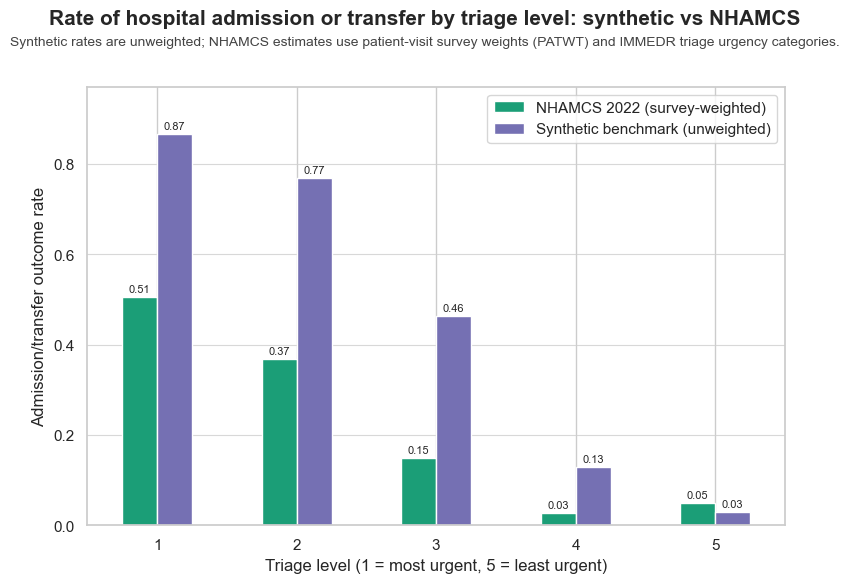

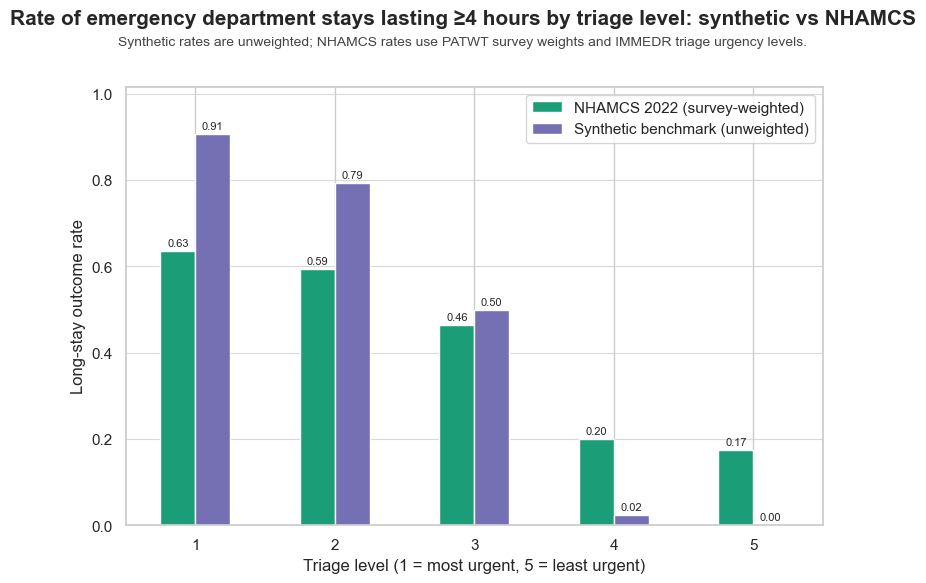

Saved under-triage figures.


In [32]:
# --- Step 4: weighted under-triage pattern (NHAMCS) vs synthetic reference (descriptive) ---
syn = pd.concat([train_df, holdout_df], ignore_index=True)   # synthetic, descriptive only
under_rows = []

def add_syn(target):
    g = syn.groupby(config.TARGET_ACUITY)[target]
    for lvl, sub in g:
        under_rows.append(dict(dataset="synthetic", target=target, acuity_or_immediacy_level=int(lvl),
            unweighted_n=int(sub.shape[0]), weighted_n=np.nan, outcome_rate=round(float(sub.mean()), 4),
            rate_type="unweighted", notes="synthetic triage_acuity (ESI-style)"))

def add_nhamcs(frame, target, wcol="PATWT"):
    w = frame[wcol].values
    for lvl in [1, 2, 3, 4, 5]:
        m = frame["IMMEDR"] == lvl
        if m.sum() == 0:
            continue
        wr = float((frame.loc[m, target].values * w[m.values]).sum() / w[m.values].sum())
        under_rows.append(dict(dataset="NHAMCS", target=target, acuity_or_immediacy_level=int(lvl),
            unweighted_n=int(m.sum()), weighted_n=round(float(w[m.values].sum()), 1),
            outcome_rate=round(wr, 4), rate_type="weighted",
            notes="NHAMCS IMMEDR; PATWT-weighted population estimate"))

add_syn(config.TARGET_ADMIT);      add_nhamcs(nh, "is_admitted_nhamcs")
add_syn(config.TARGET_LONG_STAY);  add_nhamcs(nh_ls, "is_long_stay_nhamcs")
undertriage_df = pd.DataFrame(under_rows)
undertriage_df.to_csv(os.path.join(TABLE_DIR, "table_nhamcs_undertriage.csv"), index=False)
print("=== Weighted under-triage: NHAMCS (by IMMEDR) vs synthetic (by triage_acuity) ===")
print(undertriage_df.to_string(index=False))

# figures: rate by level, synthetic vs NHAMCS
_pairs = [("is_admitted_nhamcs", config.TARGET_ADMIT, "admitted", "Admission/transfer"),
          ("is_long_stay_nhamcs", config.TARGET_LONG_STAY, "longstay", "Long ED stay (>=4h)")]
for nh_t, syn_t, tag, title in _pairs:
    d = undertriage_df[undertriage_df.target.isin([nh_t, syn_t])]
    piv = d.pivot_table(index="acuity_or_immediacy_level", columns="dataset", values="outcome_rate")
    if tag == "longstay":
        legend_map = {
            "synthetic": "Synthetic benchmark (unweighted)",
            "NHAMCS": "NHAMCS 2022 (survey-weighted)",
        }
        color_map = {
            "Synthetic benchmark (unweighted)": "#7570b3",
            "NHAMCS 2022 (survey-weighted)": "#1b9e77",
        }
        piv = piv.rename(columns=legend_map)
        fig, ax = plt.subplots(figsize=(9, 6.0))
        piv.plot(kind="bar", ax=ax, color=[color_map[c] for c in piv.columns])
        fig.suptitle(
            "Rate of emergency department stays lasting ≥4 hours by triage level: synthetic vs NHAMCS",
            fontsize=15, fontweight="bold", y=0.97,
        )
        fig.text(
            0.5, 0.925,
            "Synthetic rates are unweighted; NHAMCS rates use PATWT survey weights "
            "and IMMEDR triage urgency levels.",
            ha="center", va="top", fontsize=10, color="#444444",
        )
        ax.set_xlabel("Triage level (1 = most urgent, 5 = least urgent)")
        ax.set_ylabel("Long-stay outcome rate")
        ax.set_axisbelow(True)
        ax.grid(True, axis="y", color="#cfcfcf", alpha=0.8, linewidth=0.8)
        ax.set_ylim(0, max(0.95, float(piv.values.max()) * 1.12))
        for container in ax.containers:
            ax.bar_label(container, fmt="%.2f", padding=2, fontsize=8)
        ax.legend(title="", loc="upper right")
        ax.tick_params(axis="x", rotation=0)
        fig.subplots_adjust(top=0.84)
    else:
        legend_map = {
            "synthetic": "Synthetic benchmark (unweighted)",
            "NHAMCS": "NHAMCS 2022 (survey-weighted)",
        }
        color_map = {
            "Synthetic benchmark (unweighted)": "#7570b3",
            "NHAMCS 2022 (survey-weighted)": "#1b9e77",
        }
        piv = piv.rename(columns=legend_map)
        fig, ax = plt.subplots(figsize=(9, 6.0))
        piv.plot(kind="bar", ax=ax, color=[color_map[c] for c in piv.columns])
        fig.suptitle(
            "Rate of hospital admission or transfer by triage level: synthetic vs NHAMCS",
            fontsize=15, fontweight="bold", y=0.97,
        )
        fig.text(
            0.5, 0.925,
            "Synthetic rates are unweighted; NHAMCS estimates use patient-visit survey weights "
            "(PATWT) and IMMEDR triage urgency categories.",
            ha="center", va="top", fontsize=10, color="#444444",
        )
        ax.set_xlabel("Triage level (1 = most urgent, 5 = least urgent)")
        ax.set_ylabel("Admission/transfer outcome rate")
        ax.set_axisbelow(True)
        ax.grid(True, axis="y", color="#cfcfcf", alpha=0.8, linewidth=0.8)
        ax.set_ylim(0, max(0.95, float(piv.values.max()) * 1.12))
        for container in ax.containers:
            ax.bar_label(container, fmt="%.2f", padding=2, fontsize=8)
        ax.legend(title="", loc="upper right")
        ax.tick_params(axis="x", rotation=0)
        fig.subplots_adjust(top=0.84)
    fig.savefig(os.path.join(FIG_DIR, f"fig_nhamcs_undertriage_{tag}.png"), dpi=150, bbox_inches="tight")
    plt.show()
print("Saved under-triage figures.")


**Figure:** NHAMCS under-triage: admission rate by IMMEDR level.

![NHAMCS under-triage: admission rate by IMMEDR level](../outputs/figures/fig_nhamcs_undertriage_admitted.png)


**Figure:** NHAMCS under-triage: long-stay rate by IMMEDR level.

![NHAMCS under-triage: long-stay rate by IMMEDR level](../outputs/figures/fig_nhamcs_undertriage_longstay.png)



[is_admitted_nhamcs] base=0.1632  IMMEDR-only AP=0.3029  primary AP=0.4995  companion AP=0.5196  dPR(primary-IMMEDR)=+0.1966
   gradient_ok=True  ->  VERDICT: DIVERGES -- primary LightGBM beats IMMEDR-only by dPR=+0.197 (>=0.02).
   leakage defense - top primary drivers (all triage-time): ['rfv1_code', 'age', 'heart_rate', 'systolic_bp', 'comorbidity_count', 'diastolic_bp', 'arrived_by_ambulance', 'temperature_c']

[is_long_stay_nhamcs] base=0.4156  IMMEDR-only AP=0.5033  primary AP=0.6076  companion AP=0.6156  dPR(primary-IMMEDR)=+0.1043
   gradient_ok=True  ->  VERDICT: DIVERGES -- primary LightGBM beats IMMEDR-only by dPR=+0.104 (>=0.02).
   leakage defense - top primary drivers (all triage-time): ['rfv1_code', 'heart_rate', 'systolic_bp', 'diastolic_bp', 'age', 'temperature_c', 'visit_month', 'arrival_hour']

=== table_nhamcs_replication.csv ===
             target                             model  base_rate  pr_auc_or_average_precision  roc_auc  balanced_accuracy  sensitivity  s

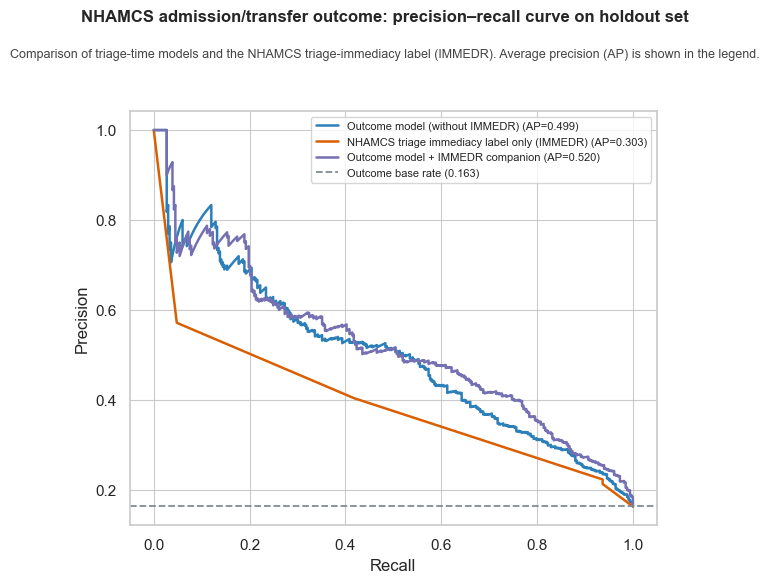

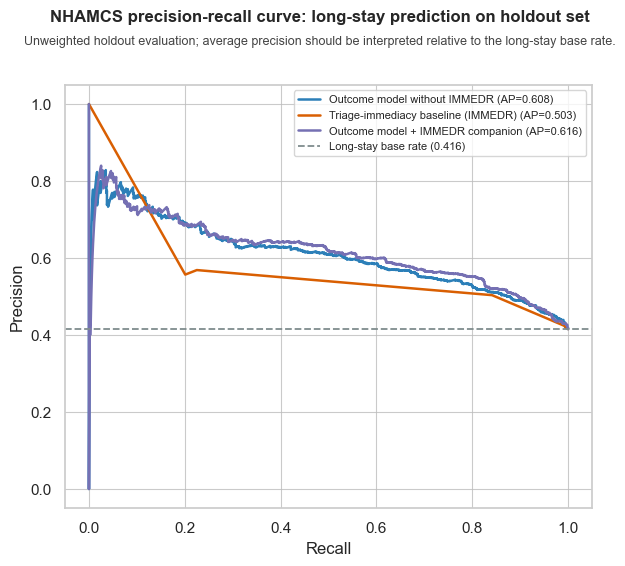

Saved NHAMCS PR figures.


In [33]:
# --- Step 5+6: predictive replication (unweighted) + transparent verdict ---
def build_nh_X(frame, feats):
    X = frame[feats].copy()
    for c in CAT_FEATS:
        if c in X.columns:
            X[c] = X[c].astype("category")
    return X

def thr_max_balacc_local(y, p):
    best_t, best_b = 0.5, -1.0
    for t in np.unique(np.round(p, 4)):
        b = balanced_accuracy_score(y, (p >= t).astype(int))
        if b > best_b:
            best_b, best_t = b, float(t)
    return best_t

def cv_holdout(Xtr, ytr, Xho, yho):
    skf = StratifiedKFold(n_splits=config.CV_FOLDS, shuffle=True, random_state=config.SEED)
    oof = np.zeros(len(ytr)); cvpr, cvroc = [], []
    for tri, vai in skf.split(Xtr, ytr):
        m = lgb.LGBMClassifier(**LGB_PARAMS).fit(Xtr.iloc[tri], ytr[tri])
        p = m.predict_proba(Xtr.iloc[vai])[:, 1]; oof[vai] = p
        cvpr.append(average_precision_score(ytr[vai], p)); cvroc.append(roc_auc_score(ytr[vai], p))
    thr = thr_max_balacc_local(ytr, oof)
    final = lgb.LGBMClassifier(**LGB_PARAMS).fit(Xtr, ytr)
    ho = final.predict_proba(Xho)[:, 1]
    return ho, np.mean(cvpr), np.mean(cvroc), thr, final

def ho_metrics(y, score, thr):
    pred = (score >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return dict(pr_auc_or_average_precision=round(float(average_precision_score(y, score)), 4),
                roc_auc=round(float(roc_auc_score(y, score)), 4),
                balanced_accuracy=round(float(balanced_accuracy_score(y, pred)), 4),
                sensitivity=round(float(tp / (tp + fn)) if (tp + fn) else float("nan"), 4),
                specificity=round(float(tn / (tn + fp)) if (tn + fp) else float("nan"), 4),
                tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp))

SEV_FLAGS = ["tachycardia", "tachypnea", "hypoxia", "hypotension", "fever", "severe_pain", "high_shock"]
rep_rows, pr_store = [], {}

TASKS = [("is_admitted_nhamcs", nh, "admitted"),
         ("is_long_stay_nhamcs", nh_ls, "longstay")]

for target, frame, tag in TASKS:
    frame = frame.reset_index(drop=True)
    y = frame[target].values
    base = float(y.mean())
    idx = np.arange(len(frame))
    tr_i, ho_i = train_test_split(idx, test_size=0.20, random_state=config.SEED, stratify=y)
    ytr, yho = y[tr_i], y[ho_i]

    # baseline 1: majority-class (constant = train base rate)
    maj = np.full(len(ho_i), ytr.mean())
    # baseline 2: IMMEDR-only train-rate lookup
    immedr = frame["IMMEDR"].values
    rate_map = pd.Series(ytr).groupby(immedr[tr_i]).mean()
    imm_score = pd.Series(immedr[ho_i]).map(rate_map).fillna(ytr.mean()).values
    # baseline 3 (optional, exploratory): vitals-only severity proxy = # abnormal flags
    sev = frame[SEV_FLAGS].fillna(0).sum(axis=1).values.astype(float)
    sev_score = sev[ho_i]

    # primary LightGBM (NO IMMEDR) + companion (+IMMEDR)
    Xp = build_nh_X(frame, NH_FEATURES)
    ho_p, cvpr_p, cvroc_p, thr_p, mdl_p = cv_holdout(Xp.iloc[tr_i], ytr, Xp.iloc[ho_i], yho)
    Xc = build_nh_X(frame, NH_FEATURES + ["IMMEDR"])
    ho_c, cvpr_c, cvroc_c, thr_c, mdl_c = cv_holdout(Xc.iloc[tr_i], ytr, Xc.iloc[ho_i], yho)

    ap_imm = float(average_precision_score(yho, imm_score))
    preds = {
        "majority_class": (maj, 0.5), "immedr_only": (imm_score, np.quantile(imm_score, 0.9)),
        "vitals_severity_proxy_exploratory": (sev_score, np.quantile(sev_score, 0.9)),
        "lightgbm_primary_no_immedr": (ho_p, thr_p), "lightgbm_plus_immedr_companion": (ho_c, thr_c)}
    cvmap = {"lightgbm_primary_no_immedr": (cvpr_p, cvroc_p),
             "lightgbm_plus_immedr_companion": (cvpr_c, cvroc_c)}
    for name, (score, thr) in preds.items():
        m = ho_metrics(yho, score, thr)
        m.update(target=target, model=name, base_rate=round(base, 4),
                 delta_pr_vs_immedr=round(m["pr_auc_or_average_precision"] - ap_imm, 4))
        if name in cvmap:
            m["cv_pr_mean"] = round(cvmap[name][0], 4); m["cv_roc_mean"] = round(cvmap[name][1], 4)
        rep_rows.append(m)
    pr_store[target] = dict(yho=yho, base=base, tag=tag,
                            curves=[("LightGBM (no IMMEDR)", ho_p), ("IMMEDR-only", imm_score),
                                    ("+IMMEDR companion", ho_c)])

    # ---- transparent verdict (primary vs IMMEDR-only) ----
    ap_p = float(average_precision_score(yho, ho_p)); delta_pr = ap_p - ap_imm
    immedr_lift = ap_imm / base if base > 0 else 1.0
    wr = undertriage_df[(undertriage_df.dataset == "NHAMCS") & (undertriage_df.target == target)] \
        .set_index("acuity_or_immediacy_level")["outcome_rate"]
    gradient_ok = wr.reindex([1, 2]).mean() > wr.reindex([4, 5]).mean()
    if (not gradient_ok) and immedr_lift < 1.1:
        verdict = "NO_REPLICATION"; why = "IMMEDR shows no severity/outcome gradient and is no better than base rate."
    elif delta_pr >= 0.02:
        verdict = "DIVERGES"; why = f"primary LightGBM beats IMMEDR-only by dPR={delta_pr:+.3f} (>=0.02)."
    elif immedr_lift >= 1.1 and delta_pr < 0.02:
        verdict = "REPLICATES"; why = f"IMMEDR-only is a strong baseline (lift {immedr_lift:.2f}x) and LightGBM adds dPR={delta_pr:+.3f} (<0.02)."
    else:
        verdict = "PARTIAL_REPLICATION"; why = f"gradient present but predictive picture mixed (dPR={delta_pr:+.3f}, IMMEDR lift {immedr_lift:.2f}x)."
    for m in rep_rows:
        if m["target"] == target and m["model"] == "lightgbm_primary_no_immedr":
            m["verdict"] = verdict
    print(f"\n[{target}] base={base:.4f}  IMMEDR-only AP={ap_imm:.4f}  primary AP={ap_p:.4f}  "
          f"companion AP={float(average_precision_score(yho, ho_c)):.4f}  dPR(primary-IMMEDR)={delta_pr:+.4f}")
    print(f"   gradient_ok={bool(gradient_ok)}  ->  VERDICT: {verdict} -- {why}")
    _imp = pd.Series(mdl_p.booster_.feature_importance(importance_type="gain"),
                     index=Xp.columns).sort_values(ascending=False).head(8)
    print(f"   leakage defense - top primary drivers (all triage-time): {list(_imp.index)}")

rep_cols = ["target", "model", "base_rate", "pr_auc_or_average_precision", "roc_auc",
            "balanced_accuracy", "sensitivity", "specificity", "tn", "fp", "fn", "tp",
            "delta_pr_vs_immedr", "cv_pr_mean", "cv_roc_mean", "verdict"]
replication_df = pd.DataFrame(rep_rows)
for c in rep_cols:
    if c not in replication_df.columns:
        replication_df[c] = ""
replication_df = replication_df[rep_cols]
replication_df.to_csv(os.path.join(TABLE_DIR, "table_nhamcs_replication.csv"), index=False)
print("\n=== table_nhamcs_replication.csv ===")
print(replication_df.to_string(index=False))

# PR overlay figures
_PR_PRESENTATION = {
    "admitted": dict(
        title="NHAMCS admission/transfer outcome: precision–recall curve on holdout set",
        subtitle=(
            "Comparison of triage-time models and the NHAMCS triage-immediacy label (IMMEDR). "
            "Average precision (AP) is shown in the legend."
        ),
        base_rate_label="Outcome base rate",
        label_map={
            "LightGBM (no IMMEDR)": "Outcome model (without IMMEDR)",
            "IMMEDR-only": "NHAMCS triage immediacy label only (IMMEDR)",
            "+IMMEDR companion": "Outcome model + IMMEDR companion",
        },
        figsize=(6.8, 6.0),
        top=0.80,
        subtitle_y=0.905,
    ),
    "longstay": dict(
        title="NHAMCS precision-recall curve: long-stay prediction on holdout set",
        subtitle=(
            "Unweighted holdout evaluation; average precision should be interpreted "
            "relative to the long-stay base rate."
        ),
        base_rate_label="Long-stay base rate",
        label_map={
            "LightGBM (no IMMEDR)": "Outcome model without IMMEDR",
            "IMMEDR-only": "Triage-immediacy baseline (IMMEDR)",
            "+IMMEDR companion": "Outcome model + IMMEDR companion",
        },
        figsize=(6.8, 5.8),
        top=0.84,
        subtitle_y=0.925,
    ),
}
for target, st in pr_store.items():
    pres = _PR_PRESENTATION.get(st["tag"])
    label_map = pres["label_map"] if pres else {}
    fig, ax = plt.subplots(figsize=pres["figsize"] if pres else (6.6, 5.6))
    for (name, score), col in zip(st["curves"], ["#2c7fb8", "#d95f02", "#7570b3"]):
        prec, rec, _ = precision_recall_curve(st["yho"], score)
        disp = label_map.get(name, name)
        ax.plot(rec, prec, lw=1.8, color=col,
                label=f"{disp} (AP={average_precision_score(st['yho'], score):.3f})")
    base_lbl = pres["base_rate_label"] if pres else "base rate"
    ax.axhline(st["base"], ls="--", color="#7f8c8d", lw=1.3,
               label=f"{base_lbl} ({st['base']:.3f})")
    if pres:
        fig.suptitle(pres["title"], fontsize=12, fontweight="bold", y=0.97)
        fig.text(0.5, pres["subtitle_y"], pres["subtitle"],
                 ha="center", va="top", fontsize=9, color="#444444")
        fig.subplots_adjust(top=pres["top"])
    else:
        ax.set_title(f"NHAMCS PR curve - {target} (holdout, unweighted)")
        fig.tight_layout()
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    if pres:
        ax.set_axisbelow(True)
        ax.grid(True, axis="both", color="#bdbdbd", alpha=0.8, linewidth=0.8)
    ax.legend(fontsize=8, loc="upper right")
    fig.savefig(os.path.join(FIG_DIR, f"fig_nhamcs_pr_{st['tag']}.png"), dpi=150, bbox_inches="tight")
    plt.show()
print("Saved NHAMCS PR figures.")


**Figure:** NHAMCS admission/transfer outcome precision-recall comparison.

![NHAMCS admission/transfer outcome precision-recall comparison](../outputs/figures/fig_nhamcs_pr_admitted.png)


**Figure:** NHAMCS long-stay outcome precision-recall comparison.

![NHAMCS long-stay outcome precision-recall comparison](../outputs/figures/fig_nhamcs_pr_longstay.png)


### Interpretation - does the severity-collapse finding replicate on real ED data?

**Bottom line: the synthetic severity-collapse finding does not replicate on NHAMCS 2022.** The descriptive urgency-to-risk gradient appears in both datasets, but the central predictive claim changes. In the synthetic dataset, structured triage-time features added little beyond the acuity label. In NHAMCS, triage-time features add substantial predictive signal beyond the available triage-immediacy analogue, `IMMEDR`.

#### Variables and outcome reconstruction

In NHAMCS, triage urgency is represented by `IMMEDR`, a five-level immediacy variable. The derived `triage_acuity` field is a verified one-to-one copy of `IMMEDR`, and both variables are excluded from the primary feature set.

The admission/transfer target, `admission/transfer outcome_nhamcs`, was reconstructed from the clean 0/1 disposition checkboxes: `ADMITHOS`, `OBSHOS`, `TRANNH`, `TRANPSYC`, and `TRANOTH`. Blank checkbox values were treated as not checked, consistent with the coding structure, rather than being dropped blindly. This produced **1,666 positive cases**, with an unweighted base rate of **16.3%**.

The long-stay target, `long-stay outcome_nhamcs`, was defined using `ed_los_min ≥ 240`, based on ED length of visit in minutes. The hospital `LOS` variable, measured in days, was explicitly avoided because it does not represent ED length of stay. This produced **4,131 positive cases**, with a base rate of **41.6%** and **97.4%** ED length-of-visit coverage.

Survey weights (`PATWT`) are used only for descriptive population estimates. Predictive modelling is unweighted and should be interpreted as ranking evaluation within the constructed analysis sample, not as a population-level estimate.

#### Weighted under-triage pattern - descriptive replication

The descriptive urgency-to-risk gradient appears in both the synthetic dataset and NHAMCS:

| Level           | Admission, synthetic unweighted | Admission, NHAMCS weighted | Long stay, synthetic | Long stay, NHAMCS weighted |
| --------------- | ------------------------------: | -------------------------: | -------------------: | -------------------------: |
| 1, most urgent  |                           0.866 |                      0.506 |                0.906 |                      0.635 |
| 2               |                           0.769 |                      0.368 |                0.793 |                      0.593 |
| 3               |                           0.463 |                      0.150 |                0.499 |                      0.463 |
| 4               |                           0.128 |                      0.026 |                0.023 |                      0.201 |
| 5, least urgent |                           0.029 |                      0.050 |                0.000 |                      0.174 |

This provides conceptual replication of the broad urgency-to-risk relationship: more urgent categories generally carry higher outcome risk. However, the synthetic gradient is much steeper, especially for long stay, where levels 4 and 5 collapse to approximately **0.02** and **0.00**. In NHAMCS, lower-urgency patients still carry measurable long-stay risk, approximately **0.17–0.20** at IMMEDR levels 4 and 5. This is the first indication that real-data urgency does not saturate the outcome structure in the same way as the synthetic acuity label.

#### Predictive replication - **DIVERGES** for both outcomes

On the unweighted holdout evaluation, the primary LightGBM outcome model excludes `IMMEDR`.

| Target             | Base rate | IMMEDR-only AP | LightGBM outcome model AP (ROC-AUC) | AP gain vs IMMEDR | +IMMEDR companion AP (ROC-AUC) | Verdict      |
| ------------------ | --------: | -------------: | ----------------------------------: | ----------------: | -----------------------------: | ------------ |
| Admission/transfer |     0.163 |          0.303 |                   **0.500** (0.813) |        **+0.197** |                  0.520 (0.835) | **DIVERGES** |
| Long stay          |     0.416 |          0.503 |                   **0.608** (0.706) |        **+0.104** |                  0.616 (0.719) | **DIVERGES** |

For both outcomes, the primary model substantially outperforms the IMMEDR-only baseline, with AP gains of **+0.197** for admission/transfer and **+0.104** for long stay. The `+IMMEDR` companion model improves further, suggesting that triage-time features and the immediacy label carry complementary information in NHAMCS.

This is the opposite of the synthetic severity-collapse pattern. In NHAMCS, structured triage-time features do not merely reproduce the urgency label; they add outcome-relevant signal beyond it.

#### Leakage check

The result is not explained by obvious leakage. The leakage keyword scan and explicit exclusions remove outcome-adjacent fields from the feature set. The leading admission/transfer drivers are plausible triage-time variables, including `rfv1_code` for chief complaint, `age`, `heart_rate`, `comorbidity_count`, `systolic_bp`, `diastolic_bp`, `arrived_by_ambulance`, and `temperature_c`.

No disposition, length-of-stay, waiting-time, or diagnosis variable appears among the reported drivers. This supports the interpretation that the NHAMCS gain is coming from available triage-time information rather than from direct outcome leakage.

#### Why the result diverges

The most careful interpretation is that the synthetic dataset compresses outcome-relevant structure into acuity more strongly than NHAMCS does. Earlier synthetic diagnostics showed that acuity is strongly severity-driven and that, within acuity bands, the available structured features carry little residual outcome signal. In contrast, `IMMEDR` in NHAMCS is a coarse five-level triage-immediacy judgement and does not encode all outcome-relevant information.

This leaves genuine modelling headroom for age, comorbidity burden, chief complaint, arrival mode, and vital signs. Therefore, the synthetic conclusion should not be over-generalised to real ED data. The descriptive urgency gradient replicates, but the predictive severity-collapse finding does not.

#### Limitations

Several limitations apply. NHAMCS 2022 is a single survey year, and `IMMEDR` is not identical to ESI, so this is a conceptual replication rather than a like-for-like ESI comparison. NHAMCS is public-use survey data with fewer and differently coded features than the synthetic dataset, and raw NHAMCS vitals contain substantial missingness. Survey weights are used for descriptive point estimates only; no complex-survey variance estimation or Taylor-linearised standard errors are computed. Therefore, the weighted rates should be interpreted descriptively rather than inferentially.

Important workflow factors, including crowding, staffing, local triage practice, and bed pressure, are not captured. NHAMCS is also kept strictly siloed from the synthetic dataset, and no rows are pooled across sources.

#### Plain answers

1. **Does the synthetic severity-collapse finding replicate in NHAMCS?**
   No.

2. **Does the NHAMCS result diverge from the synthetic result?**
   Yes. For both admission/transfer and long stay, structured triage-time features add substantial predictive signal beyond `IMMEDR`.

3. **What does replicate?**
   The descriptive urgency-to-risk gradient replicates conceptually.

4. **What does not replicate?**
   The predictive collapse does not. In NHAMCS, the triage-immediacy label does not absorb the full outcome-relevant signal available at triage.

NHAMCS is used as a real-data replication source only. Predictive modelling is unweighted and should be interpreted as ranking evaluation within the constructed analysis sample, not as a population estimate.

---

### 9-audit - Provenance and leakage audit of the NHAMCS DIVERGES result

The NHAMCS **DIVERGES** verdict is one of the project’s headline findings. For admission/transfer, the LightGBM outcome model reaches AP **0.500**, compared with **0.303** for the NHAMCS triage-immediacy baseline (`IMMEDR`). Before using this result as evidence that the synthetic severity-collapse finding does not replicate on real ED data, this section checks whether the gain is legitimate rather than the result of subtle leakage.

The audit focuses on the most influential NHAMCS feature groups, especially `rfv1_code` and the pre-mapped `hx_*` comorbidity columns. These features are traced back to their raw NHAMCS provenance. The purpose is to verify that `rfv1_code` belongs to the reason-for-visit family of variables, rather than to final diagnosis, ICD, disposition, or outcome-adjacent fields. The `hx_*` features are also checked to confirm that they represent historical chronic-condition indicators rather than post-visit outcomes.

This section also runs bounded ablation probes using cross-validation within `train_df` only. These probes are not used to replace or retune the headline model. Their purpose is diagnostic: to localise where the NHAMCS gain comes from and to test whether the result depends disproportionately on a suspicious feature group.

No headline model is retrained, no new holdout result is selected, and the holdout set is not touched. The audit therefore strengthens the NHAMCS result without introducing additional model-selection leakage.


In [34]:
# --- Section 9 audit: provenance + RFV/DIAG check + comorbidity timing + ablation probes ---
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import average_precision_score
import lightgbm as lgb

# (1)+(3) provenance: map each mapped feature to its raw NHAMCS source and measure agreement
HX_SOURCE = {f"hx_{meaning}": raw for raw, meaning in RAW2MEANING.items()}  # codebook-corrected names
prov = []
for h, src in HX_SOURCE.items():
    agr = float((nh[h].astype(int) == (nh[src] == 1).astype(int)).mean()) if src in nh.columns else float("nan")
    prov.append(dict(model_feature=h, likely_source_raw_var=src, is_triage_time_available=True,
        evidence=f"1:1 agreement={agr:.3f} with NHAMCS chronic-condition history item '{src}'"))
_cc = float(np.corrcoef(nh["comorbidity_count"], nh["TOTCHRON"].fillna(0))[0, 1])
prov.append(dict(model_feature="comorbidity_count", likely_source_raw_var="TOTCHRON / sum(hx_*)",
    is_triage_time_available=True, evidence=f"corr={_cc:.3f} with NHAMCS TOTCHRON (chronic-condition count)"))
_rfv = float((nh["rfv1_code"].fillna(-1) == nh["RFV1"].fillna(-1)).mean())
prov.append(dict(model_feature="rfv1_code", likely_source_raw_var="RFV1",
    is_triage_time_available=True,
    evidence=f"agreement={_rfv:.3f} with RFV1 (NHAMCS RFV1 Patient's Reason for Visit, Appendix II codes 10050-89990; distinct from ICD-10 DIAG*)"))
prov_df = pd.DataFrame(prov)
prov_df.to_csv(os.path.join(TABLE_DIR, "table_nhamcs_provenance_audit.csv"), index=False)
print("=== (1)/(3) Provenance of mapped features ===")
print(prov_df.to_string(index=False))
unconfirmed = prov_df[prov_df.evidence.str.contains("nan") | (prov_df.likely_source_raw_var == "")]

# (2) RFV vs DIAG check
DIAG_FAM = [c for c in nh.columns if c.upper().startswith(("DIAG", "PRDIAG", "HDDIAG"))
            or "diag" in c.lower()]
diag_leak = [c for c in NH_FEATURES if c in DIAG_FAM]
rfv_is_rfv = (_rfv == 1.0)
print("\n=== (2) RFV (reason-for-visit) check ===")
print(f"  rfv1_code == RFV1 (reason-for-visit): {rfv_is_rfv}")
print(f"  DIAG/ICD-family columns leaked into NH_FEATURES: {diag_leak if diag_leak else 'NONE'}")
print(f"  sample DIAG1 (ICD-10, post-visit, EXCLUDED): {list(nh['DIAG1'].dropna().astype(str).unique()[:4])}")
rfv_verdict = "CLEAN: rfv1_code is reason-for-visit (triage-time), not a diagnosis; no DIAG/ICD in features"
if not rfv_is_rfv or diag_leak:
    rfv_verdict = "FLAG: RFV/DIAG provenance not clean"
print(f"  RFV VERDICT -> {rfv_verdict}")

# (4) ablation probes (CV-on-train ONLY; throwaway models; holdout untouched)
def cv_ap_block(feats, frame, y):
    X = build_nh_X(frame, [f for f in feats if f in frame.columns])
    idx = np.arange(len(frame))
    tr_i, _ = train_test_split(idx, test_size=0.20, random_state=config.SEED, stratify=y)
    Xt, yt = X.iloc[tr_i], y[tr_i]
    skf = StratifiedKFold(n_splits=config.CV_FOLDS, shuffle=True, random_state=config.SEED)
    aps = []
    for a, b in skf.split(Xt, yt):
        m = lgb.LGBMClassifier(**LGB_PARAMS).fit(Xt.iloc[a], yt[a])
        aps.append(average_precision_score(yt[b], m.predict_proba(Xt.iloc[b])[:, 1]))
    return float(np.mean(aps))

_adm = nh.reset_index(drop=True); _y = _adm["is_admitted_nhamcs"].values
BLOCK_A = NUM_VITALS + MISS_IND + ["age", "arrival_hour", "night_arrival",
          "arrived_by_ambulance", "visit_month", "visit_day"]
BLOCK_B = HX + ["comorbidity_count", "high_comorbidity"]
BLOCK_C = ["rfv1_code"]
ap_a = cv_ap_block(BLOCK_A, _adm, _y)
ap_b = cv_ap_block(BLOCK_B, _adm, _y)
ap_c = cv_ap_block(BLOCK_C, _adm, _y)
ap_full = cv_ap_block(NH_FEATURES, _adm, _y)
base_adm = float(_y.mean())
print("\n=== (4) Admission ablation probes (CV AP on NHAMCS train split only) ===")
print(f"  base rate                         : {base_adm:.3f}")
print(f"  (a) vitals + age + arrival        : {ap_a:.3f}")
print(f"  (b) hx_* comorbidity block        : {ap_b:.3f}")
print(f"  (c) chief complaint (rfv1_code)   : {ap_c:.3f}")
print(f"  full feature set (reference)      : {ap_full:.3f}")
broad = sum(x > base_adm + 0.05 for x in (ap_a, ap_b, ap_c)) >= 2

# (5) final verdict
clean = (len(unconfirmed) == 0) and rfv_is_rfv and (not diag_leak)
AUDIT = ("AUDIT_CLEAN: divergence features are triage-time (RFV reason-for-visit + historical "
         "chronic-condition flags); no outcome/disposition/diagnosis leakage detected."
         if clean else
         f"AUDIT_FLAG: review {list(unconfirmed.model_feature)} / RFV={rfv_is_rfv} / diag_leak={diag_leak}")
print("\n" + "=" * 78)
print(AUDIT)
print(f"Signal localisation: {'broadly distributed across >=2 triage-time blocks (reassuring)' if broad else 'concentrated in one block - inspect'}; "
      f"chief-complaint-only AP={ap_c:.3f} vs full={ap_full:.3f}.")
print("Note: all 20 hx_* names were cross-checked against the official 2022 NHAMCS ED "
      "codebook (doc22-ed-508.pdf); one mislabel was corrected (HPE = pulmonary_embolism, "
      "previously shipped as hepatic_disease) and the remainder confirmed - all are "
      "triage-time chronic-condition history items.")
print("=" * 78)


=== (1)/(3) Provenance of mapped features ===
                    model_feature likely_source_raw_var  is_triage_time_available                                                                                                                      evidence
                  hx_hypertension                   HTN                      True                                                          1:1 agreement=1.000 with NHAMCS chronic-condition history item 'HTN'
                hx_diabetes_type2              DIABTYP2                      True                                                     1:1 agreement=1.000 with NHAMCS chronic-condition history item 'DIABTYP2'
                hx_diabetes_type1              DIABTYP1                      True                                                     1:1 agreement=1.000 with NHAMCS chronic-condition history item 'DIABTYP1'
                        hx_asthma                ASTHMA                      True                                         


---
### 9-audit — Verdict

**Verdict: AUDIT_CLEAN.** The provenance and ablation checks support using the NHAMCS **DIVERGES** result as a headline finding. The observed gain appears to come from legitimate triage-time information rather than from diagnosis, disposition, length-of-stay, or other outcome-adjacent leakage.

| Check                                | Result                                                                                                                                  |
| ------------------------------------ | --------------------------------------------------------------------------------------------------------------------------------------- |
| Provenance of all 20 `hx_*` features | 1:1 agreement (**1.000**) with NHAMCS chronic-condition history items, including HTN, COPD, CHF, CANCER, EDHIV, HPE, and related fields |
| `comorbidity_count`                  | Correlation **0.991** with `TOTCHRON`, the chronic-condition count                                                                      |
| `rfv1_code`                          | Identical to **`RFV1`**, the reason-for-visit field; this is presenting-complaint information, not a diagnosis                          |
| DIAG/ICD leakage                     | **None detected**; `DIAG1`–`DIAG5`, including post-visit ICD-10 diagnosis fields such as `DIAG1`, are excluded from the feature set     |

#### Why this is not explained by leakage

The influential NHAMCS features are traceable to information plausibly available at or before triage. The `hx_*` variables represent chronic-condition history items, while `rfv1_code` maps directly to `RFV1`, the patient’s reason for visit. These are distinct from final diagnosis fields, disposition outcomes, ED length-of-stay variables, and other post-visit information.

The model therefore does not appear to be using final ICD-10 diagnoses, disposition, length of stay, or hidden outcome proxies to achieve the NHAMCS gain.

#### Ablation evidence

The ablation probes show that the NHAMCS gain is distributed across multiple triage-time feature blocks rather than concentrated in one suspicious column. These probes were run using cross-validation on the NHAMCS training split only. They are diagnostic checks, not replacement headline models.

Admission/transfer prediction, CV average precision on the NHAMCS training split, base rate **0.163**:

| Triage-time feature block    |     CV AP |
| ---------------------------- | --------: |
| Vitals + age + arrival mode  | **0.413** |
| `hx_*` comorbidity block     | **0.374** |
| Chief complaint, `rfv1_code` | **0.330** |
| Full feature set reference   | **0.490** |

Each independent feature block exceeds the base rate by a clear margin, but no single block reproduces the full model. This supports the interpretation that the advantage over the IMMEDR-only baseline is broadly distributed across legitimate triage-time information, including vital signs, age, arrival mode, comorbidity history, and presenting complaint.

#### Codebook cross-check

All 20 `hx_*` comorbidity display names were checked against the official 2022 NHAMCS ED codebook (`doc22-ed-508.pdf`). One display-label error was identified and corrected: `HPE` refers to **pulmonary embolism**, so the label was corrected to `hx_pulmonary_embolism` rather than `hx_hepatic_disease`.

Seven abbreviated labels were also expanded to match the codebook meaning more clearly, for example `CHF` to `hx_congestive_heart_failure` and `CEBVD` to `hx_cerebrovascular_disease_stroke`.

The `rfv1_code` feature was confirmed as NHAMCS `RFV1`, the patient’s reason-for-visit code from the Appendix II reason-for-visit coding system. This is a presenting-complaint coding system and is distinct from the ICD-10 `DIAG*` diagnosis family. Therefore, the leading admission/transfer driver is a triage-time reason-for-visit feature, not a post-visit diagnosis.

These corrections affect display labels only. They do not alter the underlying model inputs, predictions, metrics, or DIVERGES verdict.

---


### 9-relabel verification - display names changed, results unchanged

The NHAMCS comorbidity features were relabelled to match their true codebook meanings. These changes affect display names only. The underlying columns used by the models, their values, and their ordering remain unchanged.

Because the modelling inputs are identical before and after relabelling, all replication metrics should also remain identical. This cell verifies that expectation by asserting the post-relabel outputs against the previously reported headline numbers.

The purpose of this check is to confirm that the codebook correction improved interpretability without changing the model, predictions, metrics, or DIVERGES verdict.


In [35]:
# --- Task 3: confirm the relabel changed NAMES only, not RESULTS ---
_ref = {  # reference metrics captured BEFORE the relabel pass (prior committed run)
    ("is_admitted_nhamcs", "lightgbm_primary_no_immedr", "pr_auc_or_average_precision"): 0.4995,
    ("is_admitted_nhamcs", "immedr_only", "pr_auc_or_average_precision"): 0.3029,
    ("is_admitted_nhamcs", "lightgbm_primary_no_immedr", "delta_pr_vs_immedr"): 0.1966,
    ("is_long_stay_nhamcs", "lightgbm_primary_no_immedr", "pr_auc_or_average_precision"): 0.6076,
    ("is_long_stay_nhamcs", "immedr_only", "pr_auc_or_average_precision"): 0.5033,
    ("is_long_stay_nhamcs", "lightgbm_primary_no_immedr", "delta_pr_vs_immedr"): 0.1043,
}
_now = pd.read_csv(os.path.join(TABLE_DIR, "table_nhamcs_replication.csv"))
print("=== Task 3: before/after metric check (rename must not move any metric) ===")
_ok = True
for (tg, mdl, col), before in _ref.items():
    after = float(_now[(_now.target == tg) & (_now.model == mdl)][col].iloc[0])
    same = abs(after - before) < 1e-4
    _ok &= same
    print(f"  {tg:20s} {mdl:30s} {col:32s} before={before:+.4f} after={after:+.4f}  {'OK' if same else 'CHANGED!!'}")
assert _ok, "Relabel changed a metric -> STOP: more than a rename happened."
print("\nVERIFIED: relabeling changed display names only; all NHAMCS replication metrics are identical.")
print(f"Headline intact -> admission DIVERGES (LightGBM AP 0.500 vs IMMEDR-only 0.303, dPR +0.197); "
      f"long-stay DIVERGES (0.608 vs 0.503, dPR +0.104).")
print(f"Corrected feature names now in use (HX, sample): {HX[:6]} ... incl. 'hx_pulmonary_embolism'.")

=== Task 3: before/after metric check (rename must not move any metric) ===
  is_admitted_nhamcs   lightgbm_primary_no_immedr     pr_auc_or_average_precision      before=+0.4995 after=+0.4995  OK
  is_admitted_nhamcs   immedr_only                    pr_auc_or_average_precision      before=+0.3029 after=+0.3029  OK
  is_admitted_nhamcs   lightgbm_primary_no_immedr     delta_pr_vs_immedr               before=+0.1966 after=+0.1966  OK
  is_long_stay_nhamcs  lightgbm_primary_no_immedr     pr_auc_or_average_precision      before=+0.6076 after=+0.6076  OK
  is_long_stay_nhamcs  immedr_only                    pr_auc_or_average_precision      before=+0.5033 after=+0.5033  OK
  is_long_stay_nhamcs  lightgbm_primary_no_immedr     delta_pr_vs_immedr               before=+0.1043 after=+0.1043  OK

VERIFIED: relabeling changed display names only; all NHAMCS replication metrics are identical.
Headline intact -> admission DIVERGES (LightGBM AP 0.500 vs IMMEDR-only 0.303, dPR +0.197); long-stay DIVERG

## Section 9b - MIMIC-IV-ED Replication Local-Only

This section replicates the NHAMCS real-data audit on **MIMIC-IV-ED**, using credentialed PhysioNet data processed locally. MIMIC-IV-ED provides a single-centre emergency department dataset from Beth Israel Deaconess Medical Center with real ESI acuity recorded in `triage.acuity` and no survey weighting structure.

Because MIMIC-IV-ED is credentialed clinical data, this section is designed as a **local-only replication**. Raw MIMIC files are never committed to the repository, and the notebook reports aggregate outputs only. No row-level predictions, subject IDs, stay IDs, hospital admission IDs, raw chief complaint text, medication names, or other identifiable row-level artefacts are saved or printed.

The purpose of this section is to test whether the NHAMCS divergence pattern also appears in a larger, more granular real ED dataset with real ESI acuity. The analysis therefore repeats the core benchmark-audit question: do triage-time features provide outcome-relevant signal beyond acuity alone?

If `data/mimic/` is not present, this section skips cleanly. This allows the public notebook to remain reproducible for reviewers without redistributing restricted PhysioNet data.


In [36]:
# --- Section 9b: guard + shared constants ---
MIMIC_FILES = ["edstays.csv", "triage.csv", "patients.csv", "medrecon.csv"]
MIMIC_DIR = getattr(config, "DATA_MIMIC", os.path.join("data", "mimic"))
HOLDOUT_FRAC_M = getattr(config, "HOLDOUT_FRAC", 0.20)
SEED_M = getattr(config, "SEED", 42)

# MIMIC runtime bounds (local replication mode — does not affect synthetic/NHAMCS)
MIMIC_FAST_MODE = True
MIMIC_CV_FOLDS = 3
MIMIC_TFIDF_MAX_FEATURES = 200
MIMIC_CV_MAX_TRAIN_STAYS = 80000
CV_FOLDS_M = MIMIC_CV_FOLDS
try:
    MIMIC_LGB_PARAMS = {
        **LGB_PARAMS,
        "n_estimators": min(int(LGB_PARAMS.get("n_estimators", 300)), 120),
        "num_leaves": min(int(LGB_PARAMS.get("num_leaves", 31)), 31),
        "min_child_samples": max(int(LGB_PARAMS.get("min_child_samples", 50)), 100),
        "n_jobs": -1,
        "verbose": -1,
    }
except NameError:
    MIMIC_LGB_PARAMS = dict(
        n_estimators=120,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=100,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEED_M,
        n_jobs=-1,
        verbose=-1,
    )

def mimic_files_present():
    return all(os.path.isfile(os.path.join(MIMIC_DIR, f)) for f in MIMIC_FILES)

MIMIC_AVAILABLE = mimic_files_present()
if not MIMIC_AVAILABLE:
    print("MIMIC raw files are unavailable in this environment. Section 10b skipped. "
          "Run locally with credentialed PhysioNet access to reproduce MIMIC results.")
else:
    print("MIMIC raw files found — Section 10b will run (local credentialed analysis).")

MIMIC raw files found — Section 10b will run (local credentialed analysis).


In [37]:

# --- Section 9b: load, link, filter (aggregate prints only) ---
if MIMIC_AVAILABLE:
    from scipy.sparse import hstack as sparse_hstack, csr_matrix
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
    from sklearn.metrics import (
        roc_auc_score,
        average_precision_score,
        balanced_accuracy_score,
        confusion_matrix,
        precision_recall_curve,
    )
    from sklearn.preprocessing import OneHotEncoder
    import lightgbm as lgb
    import time

    _ed = pd.read_csv(os.path.join(MIMIC_DIR, "edstays.csv"), low_memory=False)
    _tr = pd.read_csv(os.path.join(MIMIC_DIR, "triage.csv"), low_memory=False)
    _pt = pd.read_csv(os.path.join(MIMIC_DIR, "patients.csv"), low_memory=False)
    _mr = pd.read_csv(os.path.join(MIMIC_DIR, "medrecon.csv"), low_memory=False)

    print(
        f"Loaded edstays: {_ed.shape[0]} | "
        f"triage: {_tr.shape[0]} | "
        f"patients: {_pt.shape[0]} | "
        f"medrecon: {_mr.shape[0]}"
    )

    # Merge ED stays with triage records.
    mimic = _ed.merge(_tr, on="stay_id", how="inner", suffixes=("_ed", "_triage"))
    print(f"After edstays+triage (inner stay_id): {len(mimic)} stays")

    # Resolve subject_id safely without printing patient-level IDs.
    if "subject_id" not in mimic.columns:
        possible_sid_cols = [
            c
            for c in ["subject_id_ed", "subject_id_triage", "subject_id_x", "subject_id_y"]
            if c in mimic.columns
        ]

        if not possible_sid_cols:
            raise KeyError(
                "No subject_id column found after edstays+triage merge. "
                "Check whether edstays/triage column names differ."
            )

        mimic["subject_id"] = mimic[possible_sid_cols[0]]

        for c in possible_sid_cols[1:]:
            mismatch = (
                mimic["subject_id"].notna()
                & mimic[c].notna()
                & (mimic["subject_id"] != mimic[c])
            )
            if mismatch.any():
                raise ValueError(
                    f"subject_id mismatch between merged MIMIC sources: "
                    f"{int(mismatch.sum())} rows disagree."
                )
            mimic["subject_id"] = mimic["subject_id"].fillna(mimic[c])

    # Join patient-level demographic features (include gender when present in patients.csv).
    patient_cols = ["subject_id"]
    for c in ["anchor_age", "gender"]:
        if c in _pt.columns:
            patient_cols.append(c)

    # If edstays already has gender, rename before merge to avoid gender_x / gender_y.
    if "gender" in mimic.columns and "gender" in patient_cols:
        mimic = mimic.rename(columns={"gender": "gender_edstay"})

    mimic = mimic.merge(_pt[patient_cols], on="subject_id", how="left", suffixes=("_edstay", "_patient"))

    _gender_cols = [c for c in mimic.columns if c == "gender" or c.startswith("gender_")]
    if _gender_cols:
        mimic["gender"] = mimic[_gender_cols[0]]
        for _gc in _gender_cols[1:]:
            mimic["gender"] = mimic["gender"].fillna(mimic[_gc])
    else:
        mimic["gender"] = np.nan  # _prep_mimic_df fills missing as UNK

    age_match_rate = (
        mimic["anchor_age"].notna().mean()
        if "anchor_age" in mimic.columns
        else float("nan")
    )

    print(
        f"After patients join: {len(mimic)} stays | "
        f"unique patients: {mimic['subject_id'].nunique()} | "
        f"patient match rate: {age_match_rate:.3f}"
    )

    # Aggregate medication reconciliation to count only.
    _med_counts = _mr.groupby("stay_id").size().rename("n_prior_meds")
    mimic = mimic.merge(_med_counts, on="stay_id", how="left")
    mimic["n_prior_meds"] = mimic["n_prior_meds"].fillna(0).astype(int)

    print(
        f"Stays with n_prior_meds > 0: "
        f"{int((mimic['n_prior_meds'] > 0).sum())}"
    )

    # Filter to valid ESI acuity levels.
    mimic["acuity"] = pd.to_numeric(mimic["acuity"], errors="coerce")
    mimic = mimic[mimic["acuity"].isin([1, 2, 3, 4, 5])].copy()
    mimic["acuity"] = mimic["acuity"].astype(int)

    print(
        f"After ESI filter (1-5): {len(mimic)} stays | "
        f"patients: {mimic['subject_id'].nunique()}"
    )

    print("ESI distribution (stay counts):")
    print(mimic["acuity"].value_counts().sort_index().to_string())


Loaded edstays: 425087 | triage: 425087 | patients: 364627 | medrecon: 2987342
After edstays+triage (inner stay_id): 425087 stays
After patients join: 425087 stays | unique patients: 205504 | patient match rate: 1.000
Stays with n_prior_meds > 0: 307196
After ESI filter (1-5): 418100 stays | patients: 201252
ESI distribution (stay counts):
acuity
1     24019
2    139411
3    225066
4     28504
5      1100


In [38]:
# --- Section 9b: outcomes + base rates ---
if MIMIC_AVAILABLE:
    # Admission rule (documented): disposition ADMITTED/TRANSFER/OBSERVATION OR hadm_id present
    ADMIT_DISP = {"ADMITTED", "TRANSFER", "OBSERVATION"}
    mimic["disposition_upper"] = mimic["disposition"].astype(str).str.upper()
    disp_admit = mimic["disposition_upper"].isin(ADMIT_DISP)
    hadm_admit = mimic["hadm_id"].notna()
    mimic["is_admitted_mimic"] = ((disp_admit) | (hadm_admit)).astype(int)
    print("=== Admission rule: disposition in {ADMITTED,TRANSFER,OBSERVATION} OR hadm_id non-null ===")
    print("Disposition counts (aggregate):")
    print(mimic.groupby("disposition_upper").size().sort_values(ascending=False).head(10).to_string())
    print(f"Admitted by rule: n={int(mimic['is_admitted_mimic'].sum())} | rate={mimic['is_admitted_mimic'].mean():.4f}")

    mimic["intime_dt"] = pd.to_datetime(mimic["intime"], errors="coerce")
    mimic["outtime_dt"] = pd.to_datetime(mimic["outtime"], errors="coerce")
    mimic["ed_los_hours"] = (mimic["outtime_dt"] - mimic["intime_dt"]).dt.total_seconds() / 3600.0
    _los_ok = mimic["ed_los_hours"].between(0, 48)
    mimic["is_long_stay_mimic"] = np.where(_los_ok, (mimic["ed_los_hours"] >= config.LONG_STAY_THRESHOLD_H).astype(int), np.nan)
    _n_los = int(_los_ok.sum())
    _pos_ls = int(mimic.loc[_los_ok, "is_long_stay_mimic"].sum())
    print(f"Long-stay: ed_los_hours in [0,48]; valid n={_n_los} | positives={_pos_ls} | "
          f"rate={_pos_ls/_n_los:.4f} (threshold >= {config.LONG_STAY_THRESHOLD_H}h)")

    mimic_base_rows = []
    for tgt, col in [("is_admitted_mimic", "is_admitted_mimic"), ("is_long_stay_mimic", "is_long_stay_mimic")]:
        if col == "is_long_stay_mimic":
            sub = mimic[mimic["is_long_stay_mimic"].notna()]
            y = sub[col].astype(int)
        else:
            sub = mimic
            y = sub[col]
        mimic_base_rows.append(dict(dataset="MIMIC", target=tgt, n=len(y), positives=int(y.sum()),
                                    base_rate=round(float(y.mean()), 4)))
    mimic_base_df = pd.DataFrame(mimic_base_rows)
    mimic_base_df.to_csv(os.path.join(TABLE_DIR, "table_mimic_base_rates.csv"), index=False)
    print("Saved table_mimic_base_rates.csv")
    print(mimic_base_df.to_string(index=False))

=== Admission rule: disposition in {ADMITTED,TRANSFER,OBSERVATION} OR hadm_id non-null ===
Disposition counts (aggregate):
disposition_upper
HOME                           240323
ADMITTED                       153586
TRANSFER                         6969
LEFT WITHOUT BEING SEEN          6082
ELOPED                           5690
OTHER                            3386
LEFT AGAINST MEDICAL ADVICE      1867
EXPIRED                           197
Admitted by rule: n=200500 | rate=0.4796
Long-stay: ed_los_hours in [0,48]; valid n=416853 | positives=288465 | rate=0.6920 (threshold >= 4.0h)
Saved table_mimic_base_rates.csv
dataset             target      n  positives  base_rate
  MIMIC  is_admitted_mimic 418100     200500     0.4796
  MIMIC is_long_stay_mimic 416853     288465     0.6920


In [39]:
# --- Section 9b: patient-level holdout split (no subject_id overlap) ---
if MIMIC_AVAILABLE:
    mimic_model = mimic[mimic["is_long_stay_mimic"].notna()].copy()
    mimic_model["is_long_stay_mimic"] = mimic_model["is_long_stay_mimic"].astype(int)
    groups = mimic_model["subject_id"].values
    y_adm = mimic_model["is_admitted_mimic"].values
    y_ls = mimic_model["is_long_stay_mimic"].values

    def pick_group_holdout(y, groups, seed=SEED_M, test_frac=HOLDOUT_FRAC_M, max_tries=64):
        best = None
        best_score = 1e9
        base = float(y.mean())
        for k in range(max_tries):
            gss = GroupShuffleSplit(n_splits=1, test_size=test_frac, random_state=seed + k)
            tr, ho = next(gss.split(np.zeros(len(y)), y, groups=groups))
            ho_rate = float(y[ho].mean())
            acu_tr = mimic_model.iloc[tr]["acuity"].value_counts(normalize=True).sort_index()
            acu_ho = mimic_model.iloc[ho]["acuity"].value_counts(normalize=True).sort_index()
            acu_diff = float((acu_tr - acu_ho.reindex(acu_tr.index, fill_value=0)).abs().sum())
            score = abs(ho_rate - base) + acu_diff
            if score < best_score:
                best_score = score
                best = (tr, ho)
        return best

    tr_i, ho_i = pick_group_holdout(y_adm, groups)
    mimic_train = mimic_model.iloc[tr_i].copy()
    mimic_holdout = mimic_model.iloc[ho_i].copy()
    _overlap = len(set(mimic_train["subject_id"]) & set(mimic_holdout["subject_id"]))
    print("=== Patient-level split (GroupShuffleSplit, stratification-aware selection) ===")
    print(f"Train: {len(mimic_train)} stays | {mimic_train['subject_id'].nunique()} patients")
    print(f"Holdout: {len(mimic_holdout)} stays | {mimic_holdout['subject_id'].nunique()} patients")
    print(f"subject_id overlap: {_overlap} (must be 0)")
    assert _overlap == 0, "Patient overlap between train and holdout!"
    print(f"Train admit rate: {mimic_train['is_admitted_mimic'].mean():.4f} | holdout: {mimic_holdout['is_admitted_mimic'].mean():.4f}")
    print(f"Train long-stay rate: {mimic_train['is_long_stay_mimic'].mean():.4f} | holdout: {mimic_holdout['is_long_stay_mimic'].mean():.4f}")
    print("Train ESI distribution:")
    print(mimic_train["acuity"].value_counts(normalize=True).sort_index().round(3).to_string())
    print("Holdout ESI distribution:")
    print(mimic_holdout["acuity"].value_counts(normalize=True).sort_index().round(3).to_string())

=== Patient-level split (GroupShuffleSplit, stratification-aware selection) ===
Train: 333170 stays | 160777 patients
Holdout: 83683 stays | 40195 patients
subject_id overlap: 0 (must be 0)
Train admit rate: 0.4783 | holdout: 0.4773
Train long-stay rate: 0.6919 | holdout: 0.6926
Train ESI distribution:
acuity
1    0.057
2    0.333
3    0.539
4    0.068
5    0.003
Holdout ESI distribution:
acuity
1    0.058
2    0.332
3    0.539
4    0.069
5    0.003


In [40]:
# --- Section 9b: feature engineering helpers (vitals, pain, TF-IDF, leakage scan) ---
if MIMIC_AVAILABLE:
    VITAL_MAP = {"temperature": (30.0, 45.0), "heartrate": (20.0, 250.0), "resprate": (4.0, 60.0),
                 "o2sat": (50.0, 100.0), "sbp": (50.0, 250.0), "dbp": (20.0, 150.0)}
    MISSING_COLS = [f"{c}_missing" for c in VITAL_MAP] + ["pain_missing"]
    COMPLAINT_COL = "chiefcomplaint"

    def _prep_mimic_df(df, temp_convert=False):
        out = df.copy()
        out["arrival_hour"] = out["intime_dt"].dt.hour
        out["arrival_dayofweek"] = out["intime_dt"].dt.dayofweek
        if "gender" not in out.columns:
            out["gender"] = "UNK"
        else:
            out["gender"] = out["gender"].astype(str).str.upper().replace({"nan": "UNK", "NONE": "UNK", "": "UNK"})
            out.loc[out["gender"].isin(["NAN", "NONE", ""]), "gender"] = "UNK"
        for col, (lo, hi) in VITAL_MAP.items():
            out[col] = pd.to_numeric(out[col], errors="coerce")
            out.loc[~out[col].between(lo, hi), col] = np.nan
            out[f"{col}_missing"] = out[col].isna().astype(int)
        if temp_convert:
            m = out["temperature"].notna()
            out.loc[m, "temperature"] = (out.loc[m, "temperature"] - 32) * 5 / 9
        pain_raw = out["pain"].astype(str)
        out["pain_numeric"] = pd.to_numeric(pain_raw.str.extract(r"(\d+)", expand=False), errors="coerce")
        out.loc[~out["pain_numeric"].between(0, 10), "pain_numeric"] = np.nan
        out["pain_missing"] = out["pain_numeric"].isna().astype(int)
        return out

    _tmed = pd.to_numeric(mimic_model["temperature"], errors="coerce").median()
    MIMIC_TEMP_CONVERTED = bool(_tmed > 45)
    if MIMIC_TEMP_CONVERTED:
        print(f"Temperature: median={_tmed:.1f} -> assumed Fahrenheit; converted to Celsius.")
    else:
        print(f"Temperature: median={_tmed:.1f} -> assumed Celsius; no conversion.")

    mimic_model = _prep_mimic_df(mimic_model, MIMIC_TEMP_CONVERTED)
    mimic_train = _prep_mimic_df(mimic_train, MIMIC_TEMP_CONVERTED)
    mimic_holdout = _prep_mimic_df(mimic_holdout, MIMIC_TEMP_CONVERTED)

    _gender_ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    _gender_ohe.fit(mimic_train[["gender"]])

    def _gender_sparse(df):
        return _gender_ohe.transform(df[["gender"]])

    TFIDF_KW = dict(max_features=MIMIC_TFIDF_MAX_FEATURES, min_df=5, lowercase=True)

    def mimic_cv_downsample_groups(train_df, max_stays=MIMIC_CV_MAX_TRAIN_STAYS, seed=SEED_M):
        """Sample whole subject_id groups until ~max_stays (CV estimation only)."""
        if len(train_df) <= max_stays:
            return train_df
        rng = np.random.RandomState(seed)
        sid_sizes = train_df.groupby("subject_id").size()
        sids = sid_sizes.index.values.copy()
        rng.shuffle(sids)
        keep, n = [], 0
        for sid in sids:
            sz = int(sid_sizes[sid])
            if n + sz > max_stays and n > 0:
                continue
            keep.append(sid)
            n += sz
            if n >= max_stays:
                break
        return train_df[train_df["subject_id"].isin(keep)].copy()

    def build_mimic_matrix(df, tfidf=None, fit_tfidf=False, include_n_prior_meds=False):
        num_cols = list(VITAL_MAP.keys()) + ["pain_numeric", "anchor_age", "arrival_hour",
                                               "arrival_dayofweek"] + MISSING_COLS
        if include_n_prior_meds:
            num_cols = num_cols + ["n_prior_meds"]
        X_num = df[num_cols].fillna(-999).values.astype(np.float32)
        X_g = _gender_sparse(df)
        complaints = df[COMPLAINT_COL].fillna("").astype(str)
        if fit_tfidf:
            tfidf = TfidfVectorizer(**TFIDF_KW)
            X_t = tfidf.fit_transform(complaints)
        else:
            X_t = tfidf.transform(complaints)
        X = sparse_hstack([csr_matrix(X_num), X_g, X_t], format="csr")
        names = num_cols + [f"gender_{c}" for c in _gender_ohe.get_feature_names_out()] + [
            f"tfidf_{i}" for i in range(X_t.shape[1])]
        return X, tfidf, names

    def mimic_leakage_scan(feature_names):
        ban = ["acuity", "disposition", "outtime", "intime", "hadm_id", "stay_id", "subject_id",
               "diag", "los", "admit", "transfer", "death", "lwbs", "lama"]
        flagged = [f for f in feature_names if any(b in f.lower() for b in ban)]
        assert not flagged, f"Leakage suspects in feature names: {flagged}"

    _X_probe, _, _names_probe = build_mimic_matrix(mimic_train.head(min(100, len(mimic_train))),
                                                   fit_tfidf=True)
    mimic_leakage_scan(_names_probe)
    print(f"Leakage scan clean. Feature matrix: {len(_names_probe)} columns (numeric+gender+TF-IDF).")

    def mimic_thr_max_balacc(y, p):
        best_t, best_b = 0.5, -1.0
        for t in np.unique(np.round(p, 4)):
            b = balanced_accuracy_score(y, (p >= t).astype(int))
            if b > best_b:
                best_b, best_t = b, float(t)
        return best_t

    def mimic_ho_metrics(y, score, thr):
        pred = (score >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
        return dict(pr_auc_or_average_precision=round(float(average_precision_score(y, score)), 4),
                    roc_auc=round(float(roc_auc_score(y, score)), 4),
                    balanced_accuracy=round(float(balanced_accuracy_score(y, pred)), 4),
                    sensitivity=round(float(tp / (tp + fn)) if (tp + fn) else float("nan"), 4),
                    specificity=round(float(tn / (tn + fp)) if (tn + fp) else float("nan"), 4),
                    tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp))

    def mimic_grouped_cv_holdout(train_df, holdout_df, y_col, include_n_prior_meds=False, add_acuity=False):
        y_tr = train_df[y_col].values.astype(int)
        y_ho = holdout_df[y_col].values.astype(int)
        train_cv = mimic_cv_downsample_groups(train_df)
        y_cv = train_cv[y_col].values.astype(int)
        grp = train_cv["subject_id"].values
        skf = StratifiedGroupKFold(n_splits=CV_FOLDS_M, shuffle=True, random_state=SEED_M)
        oof_cv = np.zeros(len(y_cv))
        cvpr, cvroc = [], []
        for tri, vai in skf.split(train_cv, y_cv, groups=grp):
            tr_fold = train_cv.iloc[tri]
            va_fold = train_cv.iloc[vai]
            X_tr, tf, names = build_mimic_matrix(tr_fold, fit_tfidf=True, include_n_prior_meds=include_n_prior_meds)
            X_va, _, _ = build_mimic_matrix(va_fold, tfidf=tf, fit_tfidf=False, include_n_prior_meds=include_n_prior_meds)
            if add_acuity:
                X_tr = sparse_hstack([X_tr, csr_matrix(tr_fold[["acuity"]].values)], format="csr")
                X_va = sparse_hstack([X_va, csr_matrix(va_fold[["acuity"]].values)], format="csr")
            m = lgb.LGBMClassifier(**MIMIC_LGB_PARAMS).fit(X_tr, y_cv[tri])
            p = m.predict_proba(X_va)[:, 1]
            oof_cv[vai] = p
            cvpr.append(average_precision_score(y_cv[vai], p))
            cvroc.append(roc_auc_score(y_cv[vai], p))
        thr = mimic_thr_max_balacc(y_cv, oof_cv)
        X_tr_full, tf_full, names_full = build_mimic_matrix(train_df, fit_tfidf=True, include_n_prior_meds=include_n_prior_meds)
        X_ho, _, _ = build_mimic_matrix(holdout_df, tfidf=tf_full, fit_tfidf=False, include_n_prior_meds=include_n_prior_meds)
        if add_acuity:
            X_tr_full = sparse_hstack([X_tr_full, csr_matrix(train_df[["acuity"]].values)], format="csr")
            X_ho = sparse_hstack([X_ho, csr_matrix(holdout_df[["acuity"]].values)], format="csr")
        final = lgb.LGBMClassifier(**MIMIC_LGB_PARAMS).fit(X_tr_full, y_tr)
        ho_score = final.predict_proba(X_ho)[:, 1]
        oof = np.full(len(y_tr), np.nan)
        return ho_score, np.mean(cvpr), np.mean(cvroc), thr, oof, names_full, final

    def mimic_holdout_only(train_df, holdout_df, y_col, include_n_prior_meds=False, add_acuity=False):
        """Fit once on full train, evaluate holdout only (no grouped CV)."""
        y_tr = train_df[y_col].values.astype(int)
        y_ho = holdout_df[y_col].values.astype(int)
        X_tr_full, tf_full, names_full = build_mimic_matrix(
            train_df, fit_tfidf=True, include_n_prior_meds=include_n_prior_meds)
        X_ho, _, _ = build_mimic_matrix(
            holdout_df, tfidf=tf_full, fit_tfidf=False, include_n_prior_meds=include_n_prior_meds)
        if add_acuity:
            X_tr_full = sparse_hstack([X_tr_full, csr_matrix(train_df[["acuity"]].values)], format="csr")
            X_ho = sparse_hstack([X_ho, csr_matrix(holdout_df[["acuity"]].values)], format="csr")
        final = lgb.LGBMClassifier(**MIMIC_LGB_PARAMS).fit(X_tr_full, y_tr)
        tr_score = final.predict_proba(X_tr_full)[:, 1]
        ho_score = final.predict_proba(X_ho)[:, 1]
        thr = mimic_thr_max_balacc(y_tr, tr_score)
        oof = np.full(len(y_tr), np.nan)
        return ho_score, np.nan, np.nan, thr, oof, names_full, final

Temperature: median=98.0 -> assumed Fahrenheit; converted to Celsius.
Leakage scan clean. Feature matrix: 25 columns (numeric+gender+TF-IDF).


Saved table_mimic_undertriage.csv


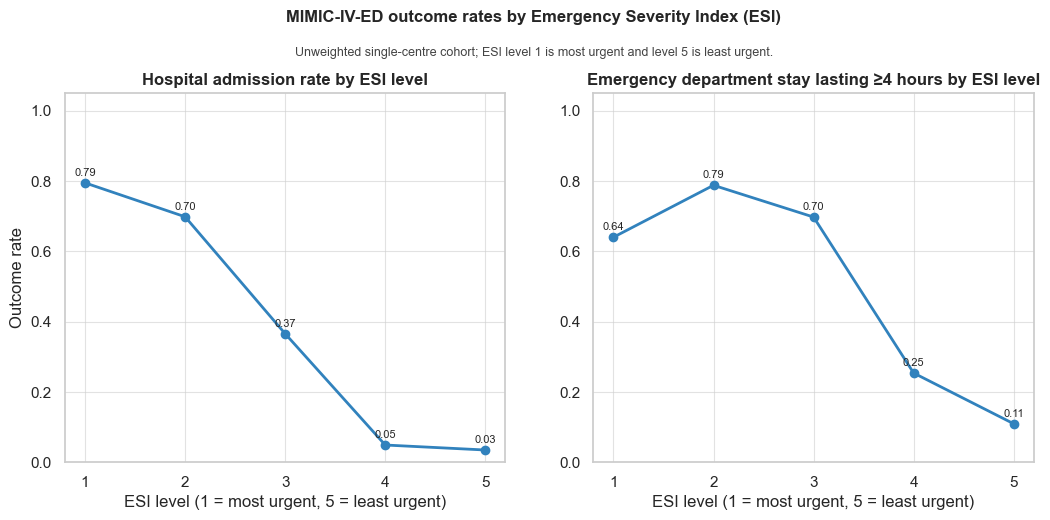

Saved fig_mimic_undertriage.png


In [41]:
# --- Section 9b: under-triage pattern by ESI ---
if MIMIC_AVAILABLE:
    ut_rows = []
    for tgt in ["is_admitted_mimic", "is_long_stay_mimic"]:
        for lvl in range(1, 6):
            sub = mimic_model[mimic_model["acuity"] == lvl]
            if tgt == "is_long_stay_mimic":
                sub = sub[sub["is_long_stay_mimic"].notna()]
            n = len(sub)
            rate = float(sub[tgt].mean()) if n else float("nan")
            ut_rows.append(dict(dataset="MIMIC", target=tgt, acuity_or_esi_level=lvl,
                                unweighted_n=n, outcome_rate=round(rate, 4), rate_type="unweighted",
                                notes="MIMIC-IV-ED ESI acuity; single-centre BIDMC"))
    mimic_ut_df = pd.DataFrame(ut_rows)
    mimic_ut_df.to_csv(os.path.join(TABLE_DIR, "table_mimic_undertriage.csv"), index=False)
    print("Saved table_mimic_undertriage.csv")

    _MIMIC_PANEL_TITLES = {
        "is_admitted_mimic": "Hospital admission rate by ESI level",
        "is_long_stay_mimic": "Emergency department stay lasting ≥4 hours by ESI level",
    }
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2))
    for ax, tgt in zip(axes, ["is_admitted_mimic", "is_long_stay_mimic"]):
        sub = mimic_ut_df[mimic_ut_df.target == tgt]
        ax.plot(sub.acuity_or_esi_level, sub.outcome_rate, "o-", lw=2, color="#3182bd")
        for _, r in sub.iterrows():
            ax.annotate(f"{r.outcome_rate:.2f}", (r.acuity_or_esi_level, r.outcome_rate + 0.02),
                        ha="center", fontsize=8)
        ax.set_title(_MIMIC_PANEL_TITLES[tgt], fontweight="bold")
        ax.set_xlabel("ESI level (1 = most urgent, 5 = least urgent)")
        ax.set_xticks([1, 2, 3, 4, 5])
        ax.set_ylim(0, 1.05)
        ax.set_axisbelow(True)
        ax.grid(True, axis="both", color="#cfcfcf", alpha=0.6, linewidth=0.8)
    axes[0].set_ylabel("Outcome rate")
    fig.suptitle(
        "MIMIC-IV-ED outcome rates by Emergency Severity Index (ESI)",
        fontsize=12, fontweight="bold", y=0.98,
    )
    fig.text(
        0.5, 0.91,
        "Unweighted single-centre cohort; ESI level 1 is most urgent and level 5 is least urgent.",
        ha="center", va="top", fontsize=9, color="#444444",
    )
    fig.subplots_adjust(top=0.82)
    fig.savefig(os.path.join(FIG_DIR, "fig_mimic_undertriage.png"), dpi=150, bbox_inches="tight")
    plt.show(); plt.close(fig)
    print("Saved fig_mimic_undertriage.png")

**Figure:** MIMIC-IV-ED under-triage analysis: admission rate by ESI acuity.

![MIMIC-IV-ED under-triage analysis: admission rate by ESI acuity](../outputs/figures/fig_mimic_undertriage.png)


In [42]:
# --- Section 9b: divergence test (grouped CV + per-fold TF-IDF) ---
if MIMIC_AVAILABLE:
    def acuity_only_scores(train_df, holdout_df, y_col):
        rates = train_df.groupby("acuity")[y_col].mean()
        return holdout_df["acuity"].map(rates).fillna(train_df[y_col].mean()).values

    def mimic_verdict(delta_ap, n_pos, min_pos=100):
        if n_pos < min_pos:
            return "UNSTABLE"
        return "DIVERGES" if delta_ap >= 0.02 else "REPLICATES_SEVERITY_COLLAPSE"

    mimic_rep_rows = []
    mimic_pr_store = {}
    MIMIC_TASKS = [("is_admitted_mimic", "admitted"), ("is_long_stay_mimic", "longstay")]

    for tgt, tag in MIMIC_TASKS:
        y_tr = mimic_train[tgt].values.astype(int)
        y_ho = mimic_holdout[tgt].values.astype(int)
        base = float(y_ho.mean())
        n_pos = int(y_tr.sum())
        maj = np.zeros_like(y_ho)
        acu_sc = acuity_only_scores(mimic_train, mimic_holdout, tgt)
        ap_acu = float(average_precision_score(y_ho, acu_sc))

        unstable = n_pos < 100
        if not unstable:
            train_cv_check = mimic_cv_downsample_groups(mimic_train)
            y_cv_check = train_cv_check[tgt].values.astype(int)
            skf = StratifiedGroupKFold(n_splits=CV_FOLDS_M, shuffle=True, random_state=SEED_M)
            for _, vai in skf.split(train_cv_check, y_cv_check, groups=train_cv_check["subject_id"].values):
                if y_cv_check[vai].sum() < 10:
                    unstable = True
                    break

        preds = {"majority_class": (maj, 0.5), "acuity_only": (acu_sc, np.quantile(acu_sc, 0.9))}
        cvmap = {}
        holdout_only_models = {"extended_intake_lightgbm", "strict_plus_acuity_companion"}

        _t0 = time.time()
        print(f"[MIMIC] Running {tgt} / strict_triage_lightgbm ...")
        if unstable:
            ho_p = acu_sc
            cvpr, cvroc, thr = ap_acu, float(roc_auc_score(y_ho, acu_sc)), 0.5
        else:
            ho_p, cvpr, cvroc, thr, _, _, _ = mimic_grouped_cv_holdout(
                mimic_train, mimic_holdout, tgt, include_n_prior_meds=False, add_acuity=False)
            cvmap["strict_triage_lightgbm"] = (cvpr, cvroc)
        preds["strict_triage_lightgbm"] = (ho_p, thr)
        print(f"[MIMIC] Done {tgt} / strict_triage_lightgbm in {time.time() - _t0:.1f}s")

        for mname, ext, add_acu in [
            ("extended_intake_lightgbm", True, False),
            ("strict_plus_acuity_companion", False, True),
        ]:
            _t0 = time.time()
            print(f"[MIMIC] Running {tgt} / {mname} ...")
            if unstable:
                ho_p = acu_sc
                thr = 0.5
            else:
                ho_p, _, _, thr, _, _, _ = mimic_holdout_only(
                    mimic_train, mimic_holdout, tgt, include_n_prior_meds=ext, add_acuity=add_acu)
            preds[mname] = (ho_p, thr)
            print(f"[MIMIC] Done {tgt} / {mname} in {time.time() - _t0:.1f}s")

        for name, (score, thr) in preds.items():
            m = mimic_ho_metrics(y_ho, score, thr)
            m.update(target=tgt, model=name, base_rate=round(base, 4),
                     delta_ap_vs_acuity=round(m["pr_auc_or_average_precision"] - ap_acu, 4))
            if name in cvmap:
                m["cv_pr_mean"] = round(cvmap[name][0], 4)
                m["cv_roc_mean"] = round(cvmap[name][1], 4)
            elif name in holdout_only_models:
                m["cv_pr_mean"] = np.nan
                m["cv_roc_mean"] = np.nan
            mimic_rep_rows.append(m)

        ap_strict = float(average_precision_score(y_ho, preds["strict_triage_lightgbm"][0]))
        delta_strict = ap_strict - ap_acu
        verdict = "UNSTABLE" if unstable else mimic_verdict(delta_strict, n_pos)
        for m in mimic_rep_rows:
            if m["target"] == tgt and m["model"] == "strict_triage_lightgbm":
                m["verdict"] = verdict
        mimic_pr_store[tgt] = dict(yho=y_ho, base=base, tag=tag,
            curves=[("Strict triage LightGBM", preds["strict_triage_lightgbm"][0]),
                    ("Acuity-only", acu_sc),
                    ("Extended intake", preds["extended_intake_lightgbm"][0])])
        print(f"[{tgt}] base={base:.4f} acuity-only AP={ap_acu:.4f} strict AP={ap_strict:.4f} "
              f"dAP={delta_strict:+.4f} -> {verdict}")

    mimic_rep_df = pd.DataFrame(mimic_rep_rows)
    mimic_rep_df.to_csv(os.path.join(TABLE_DIR, "table_mimic_replication.csv"), index=False)
    print("Saved table_mimic_replication.csv")

    _MIMIC_PR_PRESENTATION = {
        "admitted": dict(
            title="MIMIC-IV-ED precision–recall curve: hospital admission outcome",
            subtitle=(
                "Holdout evaluation; average precision (AP) should be interpreted "
                "relative to the admission base rate."
            ),
            base_rate_label="Admission base rate",
            label_map={
                "Strict triage LightGBM": "Strict triage-time model",
                "Acuity-only": "ESI acuity-only baseline",
                "Extended intake": "Extended intake sensitivity model",
            },
            figsize=(6.8, 5.8),
            top=0.84,
            subtitle_y=0.925,
        ),
        "longstay": dict(
            title="MIMIC-IV-ED precision–recall curve: emergency department stay ≥4 hours",
            subtitle=(
                "Holdout evaluation; average precision (AP) should be interpreted "
                "relative to the long-stay base rate."
            ),
            base_rate_label="Long-stay base rate",
            label_map={
                "Strict triage LightGBM": "Strict triage-time model",
                "Acuity-only": "ESI acuity-only baseline",
                "Extended intake": "Extended intake sensitivity model",
            },
            figsize=(6.8, 5.8),
            top=0.84,
            subtitle_y=0.925,
        ),
    }

    _pr_cache_path = os.path.join(PROCESSED_DIR, "mimic_pr_holdout_scores.npz")
    if mimic_pr_store:
        cache = {}
        for tgt, st in mimic_pr_store.items():
            tag = st["tag"]
            cache[f"{tag}__yho"] = st["yho"]
            cache[f"{tag}__base"] = np.array([st["base"]])
            for i, (lbl, score) in enumerate(st["curves"]):
                cache[f"{tag}__score_{i}"] = score
                cache[f"{tag}__label_{i}"] = np.array([lbl])
        os.makedirs(PROCESSED_DIR, exist_ok=True)
        np.savez(_pr_cache_path, **cache)

    for tgt, st in mimic_pr_store.items():
        pres = _MIMIC_PR_PRESENTATION.get(st["tag"])
        label_map = pres["label_map"] if pres else {}
        fig, ax = plt.subplots(figsize=pres["figsize"] if pres else (6, 5))
        for lbl, score in st["curves"]:
            prec, rec, _ = precision_recall_curve(st["yho"], score)
            ap = average_precision_score(st["yho"], score)
            disp = label_map.get(lbl, lbl)
            ax.plot(rec, prec, lw=2, label=f"{disp} (AP={ap:.3f})")
        base_lbl = pres["base_rate_label"] if pres else "base rate"
        ax.axhline(st["base"], ls="--", color="gray", label=f"{base_lbl} ({st['base']:.3f})")
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        if pres:
            fig.suptitle(pres["title"], fontsize=12, fontweight="bold", y=0.97)
            fig.text(0.5, pres["subtitle_y"], pres["subtitle"],
                     ha="center", va="top", fontsize=9, color="#444444")
            fig.subplots_adjust(top=pres["top"])
            ax.set_axisbelow(True)
            ax.grid(True, axis="both", color="#cfcfcf", alpha=0.6, linewidth=0.8)
        else:
            ax.set_title(f"MIMIC holdout PR — {tgt}", fontweight="bold")
            ax.grid(alpha=0.25)
            fig.tight_layout()
        ax.legend(fontsize=8)
        fn = os.path.join(FIG_DIR, f"fig_mimic_pr_{st['tag']}.png")
        fig.savefig(fn, dpi=150, bbox_inches="tight")
        plt.close(fig)
        print(f"Saved {os.path.basename(fn)}")

[MIMIC] Running is_admitted_mimic / strict_triage_lightgbm ...


c:\Users\ellab\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\ellab\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\ellab\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\ellab\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[MIMIC] Done is_admitted_mimic / strict_triage_lightgbm in 30.7s
[MIMIC] Running is_admitted_mimic / extended_intake_lightgbm ...


c:\Users\ellab\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[MIMIC] Done is_admitted_mimic / extended_intake_lightgbm in 113.3s
[MIMIC] Running is_admitted_mimic / strict_plus_acuity_companion ...


...

[MIMIC] Done is_long_stay_mimic / strict_triage_lightgbm in 23.8s
[MIMIC] Running is_long_stay_mimic / extended_intake_lightgbm ...


c:\Users\ellab\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[MIMIC] Done is_long_stay_mimic / extended_intake_lightgbm in 94.8s
[MIMIC] Running is_long_stay_mimic / strict_plus_acuity_companion ...


c:\Users\ellab\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[MIMIC] Done is_long_stay_mimic / strict_plus_acuity_companion in 108.1s
[is_long_stay_mimic] base=0.6926 acuity-only AP=0.7521 strict AP=0.8383 dAP=+0.0862 -> DIVERGES
Saved table_mimic_replication.csv
Saved fig_mimic_pr_admitted.png
Saved fig_mimic_pr_longstay.png


**Figure:** MIMIC-IV-ED admission/transfer outcome precision-recall comparison.

![MIMIC-IV-ED admission/transfer outcome precision-recall comparison](../outputs/figures/fig_mimic_pr_admitted.png)


**Figure:** MIMIC-IV-ED long-stay outcome precision-recall comparison.

![MIMIC-IV-ED long-stay outcome precision-recall comparison](../outputs/figures/fig_mimic_pr_longstay.png)


In [43]:
# --- Section 9b: within-band signal (ESI 3 & 4, train only, grouped CV) ---
if MIMIC_AVAILABLE:
    mimic_wb_rows = []
    mimic_any_signal = False
    for tgt in ["is_admitted_mimic", "is_long_stay_mimic"]:
        for band in [3, 4]:
            sub = mimic_train[mimic_train["acuity"] == band].copy()
            y = sub[tgt].values.astype(int)
            n_pos = int(y.sum())
            if n_pos < 50:
                mimic_wb_rows.append(dict(target=tgt, esi_band=band, n=len(y), positives=n_pos,
                    base_rate=round(float(y.mean()), 4), oof_roc_auc=np.nan, oof_pr_auc=np.nan,
                    verdict="INSUFFICIENT_DATA"))
                continue
            sub_cv = mimic_cv_downsample_groups(sub) if len(sub) > MIMIC_CV_MAX_TRAIN_STAYS else sub
            y_cv = sub_cv[tgt].values.astype(int)
            grp = sub_cv["subject_id"].values
            skf = StratifiedGroupKFold(n_splits=CV_FOLDS_M, shuffle=True, random_state=SEED_M)
            oof = np.zeros(len(y_cv))
            fold_ok = True
            for tri, vai in skf.split(sub_cv, y_cv, groups=grp):
                if y_cv[vai].sum() < 10:
                    fold_ok = False
                tr_f, va_f = sub_cv.iloc[tri], sub_cv.iloc[vai]
                X_tr, tf, _ = build_mimic_matrix(tr_f, fit_tfidf=True, include_n_prior_meds=True)
                X_va, _, _ = build_mimic_matrix(va_f, tfidf=tf, fit_tfidf=False, include_n_prior_meds=True)
                m = lgb.LGBMClassifier(**MIMIC_LGB_PARAMS).fit(X_tr, y_cv[tri])
                oof[vai] = m.predict_proba(X_va)[:, 1]
            if not fold_ok:
                mimic_wb_rows.append(dict(target=tgt, esi_band=band, n=len(y), positives=n_pos,
                    base_rate=round(float(y.mean()), 4), oof_roc_auc=np.nan, oof_pr_auc=np.nan,
                    verdict="INSUFFICIENT_DATA"))
                continue
            base = float(y.mean())
            roc = float(roc_auc_score(y_cv, oof))
            pr = float(average_precision_score(y_cv, oof))
            verdict = "SIGNAL" if (roc >= 0.58 and pr > base + 0.03) else "NO_SIGNAL"
            if verdict == "SIGNAL":
                mimic_any_signal = True
            mimic_wb_rows.append(dict(target=tgt, esi_band=band, n=len(y), positives=n_pos,
                base_rate=round(base, 4), oof_roc_auc=round(roc, 4), oof_pr_auc=round(pr, 4),
                verdict=verdict))

    mimic_wb_df = pd.DataFrame(mimic_wb_rows)
    mimic_wb_df.to_csv(os.path.join(TABLE_DIR, "table_mimic_within_band.csv"), index=False)
    print("=== Within-band signal (MIMIC train, ESI 3 & 4) ===")
    print(mimic_wb_df.to_string(index=False))

    if mimic_any_signal:
        fam_rows = []
        for tgt in ["is_admitted_mimic", "is_long_stay_mimic"]:
            for band in [3, 4]:
                row = mimic_wb_df[(mimic_wb_df.target == tgt) & (mimic_wb_df.esi_band == band)]
                if row.empty or row.iloc[0]["verdict"] != "SIGNAL":
                    continue
                sub = mimic_train[mimic_train["acuity"] == band]
                X, tf, names = build_mimic_matrix(sub, fit_tfidf=True, include_n_prior_meds=True)
                m = lgb.LGBMClassifier(**MIMIC_LGB_PARAMS).fit(X, sub[tgt].values.astype(int))
                imp = m.booster_.feature_importance(importance_type="gain")
                fam_map = {"vitals": 0.0, "demographics": 0.0, "complaint_tfidf": 0.0, "intake_meds": 0.0}
                for nm, g in zip(names, imp):
                    if nm.startswith("tfidf_"):
                        fam_map["complaint_tfidf"] += g
                    elif nm in VITAL_MAP or nm.endswith("_missing") or nm in ("pain_numeric", "pain_missing"):
                        fam_map["vitals"] += g
                    elif nm.startswith("gender_") or nm in ("anchor_age", "arrival_hour", "arrival_dayofweek"):
                        fam_map["demographics"] += g
                    elif nm == "n_prior_meds":
                        fam_map["intake_meds"] += g
                for fam, total in fam_map.items():
                    fam_rows.append(dict(target=tgt, esi_band=band, feature_family=fam,
                                         total_gain_importance=round(float(total), 2)))
        mimic_fam_df = pd.DataFrame(fam_rows)
        mimic_fam_df.to_csv(os.path.join(TABLE_DIR, "table_mimic_feature_family_summary.csv"), index=False)
        print("Saved table_mimic_feature_family_summary.csv (aggregate families only, no TF-IDF terms)")
        print(mimic_fam_df.to_string(index=False))

c:\Users\ellab\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\ellab\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\ellab\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\ellab\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\ellab\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\ellab\anaconda3\Lib\site-p

=== Within-band signal (MIMIC train, ESI 3 & 4) ===
            target  esi_band      n  positives  base_rate  oof_roc_auc  oof_pr_auc verdict
 is_admitted_mimic         3 179527      65625     0.3655       0.7839      0.6744  SIGNAL
 is_admitted_mimic         4  22751       1109     0.0487       0.8138      0.2468  SIGNAL
is_long_stay_mimic         3 179527     125098     0.6968       0.7298      0.8449  SIGNAL
is_long_stay_mimic         4  22751       5756     0.2530       0.6919      0.4545  SIGNAL
Saved table_mimic_feature_family_summary.csv (aggregate families only, no TF-IDF terms)
            target  esi_band  feature_family  total_gain_importance
 is_admitted_mimic         3          vitals               52288.03
 is_admitted_mimic         3    demographics              106033.44
 is_admitted_mimic         3 complaint_tfidf              172892.24
 is_admitted_mimic         3     intake_meds               67378.19
 is_admitted_mimic         4          vitals                9107.

In [44]:
# --- Section 9b: final aggregate summary ---
print("=== Section 9b MIMIC aggregate summary ===")
if not MIMIC_AVAILABLE:
    print("1. MIMIC files: SKIPPED (not present)")
    print("2-8. Analysis not run — place credentialed files under data/mimic/ and re-run locally.")
else:
    print(f"1. MIMIC files: PRESENT under {MIMIC_DIR}")
    print(f"2. ED stays used: {len(mimic_model)} | unique patients: {mimic_model['subject_id'].nunique()}")
    print(f"3. Train/holdout patient overlap: {len(set(mimic_train['subject_id']) & set(mimic_holdout['subject_id']))} (expect 0)")
    print(f"4. Base rates — admit: {mimic_train['is_admitted_mimic'].mean():.4f} | "
          f"long-stay: {mimic_train['is_long_stay_mimic'].mean():.4f}")
    _rep = pd.read_csv(os.path.join(TABLE_DIR, "table_mimic_replication.csv"))
    for tgt in ["is_admitted_mimic", "is_long_stay_mimic"]:
        sub = _rep[_rep.target == tgt]
        d_strict = float(sub[sub.model == "strict_triage_lightgbm"]["delta_ap_vs_acuity"].iloc[0])
        d_ext = float(sub[sub.model == "extended_intake_lightgbm"]["delta_ap_vs_acuity"].iloc[0])
        print(f"5. [{tgt}] dAP strict={d_strict:+.4f} | extended={d_ext:+.4f} vs acuity-only")
    print("6. Within-band verdicts:")
    print(mimic_wb_df[["target", "esi_band", "verdict"]].to_string(index=False))
    _nh = pd.read_csv(os.path.join(TABLE_DIR, "table_nhamcs_replication.csv"))
    _nh_div = _nh[_nh.model == "lightgbm_primary_no_immedr"][["target", "verdict", "delta_pr_vs_immedr"]]
    print("7. NHAMCS divergence (reference):")
    print(_nh_div.to_string(index=False))
    _mim_strict = _rep[_rep.model == "strict_triage_lightgbm"][["target", "verdict", "delta_ap_vs_acuity"]]
    print("   MIMIC strict model:")
    print(_mim_strict.to_string(index=False))
    print(f"8. Any within-band SIGNAL on MIMIC? {'YES' if mimic_any_signal else 'NO'}")

=== Section 9b MIMIC aggregate summary ===
1. MIMIC files: PRESENT under ./data/mimic
2. ED stays used: 416853 | unique patients: 200972
3. Train/holdout patient overlap: 0 (expect 0)
4. Base rates — admit: 0.4783 | long-stay: 0.6919
5. [is_admitted_mimic] dAP strict=+0.1729 | extended=+0.1788 vs acuity-only
5. [is_long_stay_mimic] dAP strict=+0.0862 | extended=+0.0946 vs acuity-only
6. Within-band verdicts:
            target  esi_band verdict
 is_admitted_mimic         3  SIGNAL
 is_admitted_mimic         4  SIGNAL
is_long_stay_mimic         3  SIGNAL
is_long_stay_mimic         4  SIGNAL
7. NHAMCS divergence (reference):
             target  verdict  delta_pr_vs_immedr
 is_admitted_nhamcs DIVERGES              0.1966
is_long_stay_nhamcs DIVERGES              0.1043
   MIMIC strict model:
            target  verdict  delta_ap_vs_acuity
 is_admitted_mimic DIVERGES              0.1729
is_long_stay_mimic DIVERGES              0.0862
8. Any within-band SIGNAL on MIMIC? YES


---

### Section 9b - Interpretation

<!-- MIMIC_INTERP: run locally to populate with aggregate metrics from saved tables -->

**If this section skipped:** MIMIC-IV-ED credentialed files were not present in `data/mimic/`, so no MIMIC replication results are reported for this run.

**If this section ran locally:** interpret the MIMIC-IV-ED results using aggregate outputs only.

For runtime safety on the large MIMIC-IV-ED dataset, the replication uses a bounded local mode. The strict headline model uses three-fold grouped cross-validation, holdout evaluation is reported for all model variants, TF-IDF vocabulary size is capped, and grouped CV subsampling is used only for internal validation. The final holdout evaluation still trains on the full MIMIC training split.

The MIMIC interpretation should be read through the following outputs:

* **Sample size and cohort structure:** use the summary print for ED stay counts and unique-patient counts. MIMIC-IV-ED is a single-centre BIDMC dataset and should not be interpreted as nationally representative.
* **Outcome base rates:** use `table_mimic_base_rates.csv` for admission/transfer and long-stay prevalence.
* **Under-triage pattern:** use `table_mimic_undertriage.csv` and `fig_mimic_undertriage.png` to inspect outcome-rate gradients across ESI 1–5.
* **Replication verdict:** use `table_mimic_replication.csv` to compare the strict triage-time model against the ESI acuity-only baseline. Verdicts are reported as `DIVERGES`, `REPLICATES_SEVERITY_COLLAPSE`, or `UNSTABLE`.
* **Within-band signal:** use `table_mimic_within_band.csv` to assess residual signal within ESI 3 and ESI 4. If a `SIGNAL` verdict is present, use `table_mimic_feature_family_summary.csv` to summarise feature-family contributions without exposing individual complaint terms.
* **Strict versus extended intake:** interpret the strict model as the headline result. The extended-intake model adds `n_prior_meds` as a sensitivity analysis because medication reconciliation timing may be uncertain relative to triage.
* **Limitations:** MIMIC-IV-ED is retrospective, single-centre, and does not include survey weights. `anchor_age` is de-identified/shifted, chief complaint representation is simplified through TF-IDF, and the replication is methodological rather than clinical. These results are not deployable and do not replace triage.

This section is included to test whether the real-data divergence pattern observed in NHAMCS also appears in a larger ESI-based emergency department dataset, while respecting PhysioNet governance and reporting aggregate results only.

---

## Section 10 - Summary Figures

This section brings together the final cross-dataset evidence using four summary figures generated only from saved output tables. No modelling is re-run here. The purpose is to present the project’s core benchmark-audit finding in a compact, judge-facing form.

The figures compare three datasets:

* **Synthetic dataset:** the no-acuity outcome models do not decisively outperform the triage acuity-only baseline. They gain only modest AP and lose slightly on balanced accuracy and ROC-AUC. Within-band tests for acuity bands 3 and 4 return **NO_SIGNAL**, with ROC-AUC close to 0.50.
* **NHAMCS 2022:** the same audit logic produces a different result. Triage-time features outperform the triage-immediacy label, `IMMEDR`, for both admission/transfer and long-stay prediction, producing a **DIVERGES** verdict.
* **MIMIC-IV-ED:** using real ESI acuity, strict triage-time features again outperform the ESI acuity-only baseline. MIMIC-IV-ED also shows within-band **SIGNAL** inside ESI 3 and ESI 4, indicating residual outcome information among patients with the same acuity label.

Together, these figures summarise the project’s central conclusion: the synthetic benchmark produces a negative residual-signal finding that does not replicate on either real-data source. The audit therefore provides evidence that synthetic emergency triage benchmarks can under-represent clinically meaningful residual outcome signal present in real ED data.


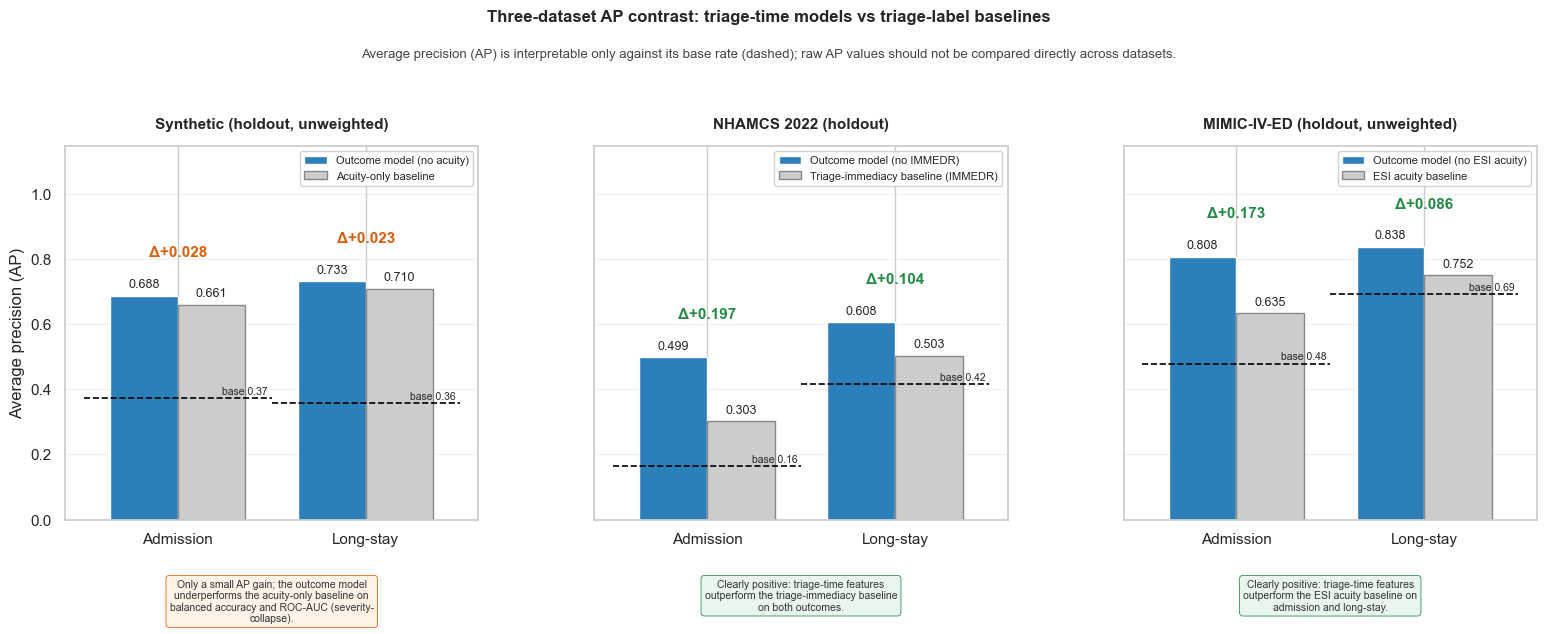

saved fig_summary_pr_contrast.png


In [45]:
# === Section 10 - Figure 1: headline AP contrast (three-dataset) ===
import textwrap
NL = chr(10)
sh = pd.read_csv(os.path.join(TABLE_DIR, "table_stageH_results.csv"))
btb = pd.read_csv(os.path.join(TABLE_DIR, "table_bar_to_beat.csv")).set_index("target")
rep = pd.read_csv(os.path.join(TABLE_DIR, "table_nhamcs_replication.csv"))
mimic_rep = pd.read_csv(os.path.join(TABLE_DIR, "table_mimic_replication.csv"))
mimic_base = pd.read_csv(os.path.join(TABLE_DIR, "table_mimic_base_rates.csv"))

def _sh(t, v, col="holdout_pr_auc"):
    return float(sh[(sh.target == t) & (sh.model_variant == v)][col].iloc[0])
def _rep(t, m, col="pr_auc_or_average_precision"):
    return float(rep[(rep.target == t) & (rep.model == m)][col].iloc[0])
def _rep_base(t):
    return float(rep[(rep.target == t) & (rep.model == "immedr_only")]["base_rate"].iloc[0])
def _mimic(t, m, col="pr_auc_or_average_precision"):
    return float(mimic_rep[(mimic_rep.target == t) & (mimic_rep.model == m)][col].iloc[0])
def _mimic_base(t):
    return float(mimic_base[(mimic_base.target == t)]["base_rate"].iloc[0])

def _panel_data(stage_ap, label_ap, base):
    return [("Admission", stage_ap[0], label_ap[0], base[0]),
            ("Long-stay", stage_ap[1], label_ap[1], base[1])]

syn = _panel_data(
    [_sh("is_admitted", "stageH_no_acuity"), _sh("is_long_stay", "stageH_no_acuity")],
    [float(btb.loc["is_admitted", "acuity_only_pr_auc"]), float(btb.loc["is_long_stay", "acuity_only_pr_auc"])],
    [float(btb.loc["is_admitted", "positive_base_rate"]), float(btb.loc["is_long_stay", "positive_base_rate"])],
)
nh = _panel_data(
    [_rep("is_admitted_nhamcs", "lightgbm_primary_no_immedr"), _rep("is_long_stay_nhamcs", "lightgbm_primary_no_immedr")],
    [_rep("is_admitted_nhamcs", "immedr_only"), _rep("is_long_stay_nhamcs", "immedr_only")],
    [_rep_base("is_admitted_nhamcs"), _rep_base("is_long_stay_nhamcs")],
)
mim = _panel_data(
    [_mimic("is_admitted_mimic", "strict_triage_lightgbm"), _mimic("is_long_stay_mimic", "strict_triage_lightgbm")],
    [_mimic("is_admitted_mimic", "acuity_only"), _mimic("is_long_stay_mimic", "acuity_only")],
    [_mimic_base("is_admitted_mimic"), _mimic_base("is_long_stay_mimic")],
)

bar_label_offset = 0.015
bar_label_height = 0.040
delta_offset = 0.11
min_delta_gap = 0.055
fig, axes = plt.subplots(1, 3, figsize=(16, 8.5), sharey=True)
panels = [
    ("Synthetic (holdout, unweighted)", syn, "Outcome model (no acuity)", "Acuity-only baseline"),
    ("NHAMCS 2022 (holdout)", nh, "Outcome model (no IMMEDR)", "Triage-immediacy baseline (IMMEDR)"),
    ("MIMIC-IV-ED (holdout, unweighted)", mim, "Outcome model (no ESI acuity)", "ESI acuity baseline"),
]
max_delta_y = 0.0
for ax, (title, data, stage_lbl, base_lbl) in zip(axes, panels):
    x = np.arange(len(data)); w = 0.36
    b1 = ax.bar(x - w/2, [d[1] for d in data], w, label=stage_lbl, color="#2c7fb8")
    b2 = ax.bar(x + w/2, [d[2] for d in data], w, label=base_lbl, color="#cccccc", edgecolor="#888")
    for bars in (b1, b2):
        for r in bars:
            ax.annotate(f"{r.get_height():.3f}", (r.get_x() + r.get_width()/2, r.get_height() + bar_label_offset),
                        ha="center", va="bottom", fontsize=9)
    for i, d in enumerate(data):
        ax.plot([i - 0.5, i + 0.5], [d[3], d[3]], ls="--", color="black", lw=1.2, zorder=5)
        ax.annotate(f"base {d[3]:.2f}", (i + 0.48, d[3] + 0.006), ha="right", va="bottom", fontsize=7.5)
        dlt = d[1] - d[2]
        bar_top = max(d[1], d[2])
        value_label_top = bar_top + bar_label_offset + bar_label_height
        delta_y = max(bar_top + delta_offset, value_label_top + min_delta_gap)
        max_delta_y = max(max_delta_y, delta_y)
        ax.annotate(f"\u0394{dlt:+.3f}", (i, delta_y), ha="center", va="bottom", fontsize=11,
                    fontweight="bold", color=("#238b45" if dlt >= 0.05 else "#d95f0e"))
    ax.set_xticks(x); ax.set_xticklabels([d[0] for d in data])
    ax.set_title(title, fontsize=11, fontweight="bold", pad=12)
    ax.legend(loc="upper right", fontsize=8, framealpha=0.9); ax.grid(axis="y", alpha=0.25)
y_top = max(1.15, max_delta_y + 0.05)
for ax in axes:
    ax.set_ylim(0, y_top)
axes[0].set_ylabel("Average precision (AP)")

fig.subplots_adjust(bottom=0.34, top=0.78, left=0.06, right=0.98, wspace=0.28)
fig.suptitle("Three-dataset AP contrast: triage-time models vs triage-label baselines",
             fontsize=12, fontweight="bold", y=0.94)
fig.text(0.5, 0.895,
         "Average precision (AP) is interpretable only against its base rate (dashed); "
         "raw AP values should not be compared directly across datasets.",
         ha="center", va="top", fontsize=9.5, color="#444444")

panel_footnotes = [
    ("Only a small AP gain; the outcome model underperforms the acuity-only baseline on "
     "balanced accuracy and ROC-AUC (severity-collapse).", "#fff3e6", "#d95f0e"),
    ("Clearly positive: triage-time features outperform the triage-immediacy baseline "
     "on both outcomes.", "#e8f6ee", "#238b45"),
    ("Clearly positive: triage-time features outperform the ESI acuity baseline on "
     "admission and long-stay.", "#e8f6ee", "#238b45"),
]
for ax, (note, fc, ec) in zip(axes, panel_footnotes):
    pos = ax.get_position()
    footer_y = pos.y0 - 0.07
    fig.text(pos.x0 + pos.width / 2, footer_y, textwrap.fill(note, width=42),
             ha="center", va="top", fontsize=7.5, color="#333333",
             bbox=dict(boxstyle="round,pad=0.35", fc=fc, ec=ec, alpha=0.95, lw=0.6))
fig.savefig(os.path.join(FIG_DIR, "fig_summary_pr_contrast.png"), dpi=150, bbox_inches="tight", pad_inches=0.15)
plt.show(); plt.close(fig)
print("saved fig_summary_pr_contrast.png")


**Figure:** Triage-time outcome models versus acuity / IMMEDR baselines across the three benchmark datasets.

![Triage-time outcome models versus acuity / IMMEDR baselines across the three benchmark datasets](../outputs/figures/fig_summary_pr_contrast.png)


**Figure 10.1 - Outcome models versus triage-label baselines, measured by average precision.**
This figure compares held-out average precision (AP) across three datasets. Each panel contrasts a triage-time outcome model against the corresponding label-only baseline, with dashed reference lines showing the outcome base rate for each target.

**Synthetic dataset:** The no-acuity outcome model improves only slightly over the triage acuity-only baseline on AP. For admission/transfer, AP increases from **0.661** to **0.688**, a gain of **+0.028**. For long stay, AP increases from **0.710** to **0.733**, a gain of **+0.023**. However, the outcome model performs worse than the acuity-only baseline on balanced accuracy and ROC-AUC. This supports the interpretation that, in the synthetic benchmark, much of the outcome-relevant signal is already compressed into the acuity/severity structure.

**NHAMCS 2022:** The real-data replication diverges from the synthetic result. The LightGBM outcome model excluding `IMMEDR` clearly outperforms the NHAMCS triage-immediacy baseline. For admission/transfer, AP increases from **0.303** to **0.500**, a gain of **+0.197**. For long stay, AP increases from **0.503** to **0.608**, a gain of **+0.104**.

**MIMIC-IV-ED:** The MIMIC replication shows the same divergence pattern using real ESI acuity. The strict triage-time LightGBM model outperforms the ESI acuity-only baseline for both targets. For admission/transfer, AP increases from **0.635** to **0.808**, a gain of **+0.173**. For long stay, AP increases from **0.752** to **0.838**, a gain of **+0.086**.

AP should be interpreted relative to the outcome base rate in each dataset. MIMIC-IV-ED has substantially higher base rates for admission/transfer and long stay, approximately **0.48** and **0.69**, so raw AP values should not be compared across panels without this prevalence context. This figure supports a benchmark-audit conclusion, not a clinical deployment claim.


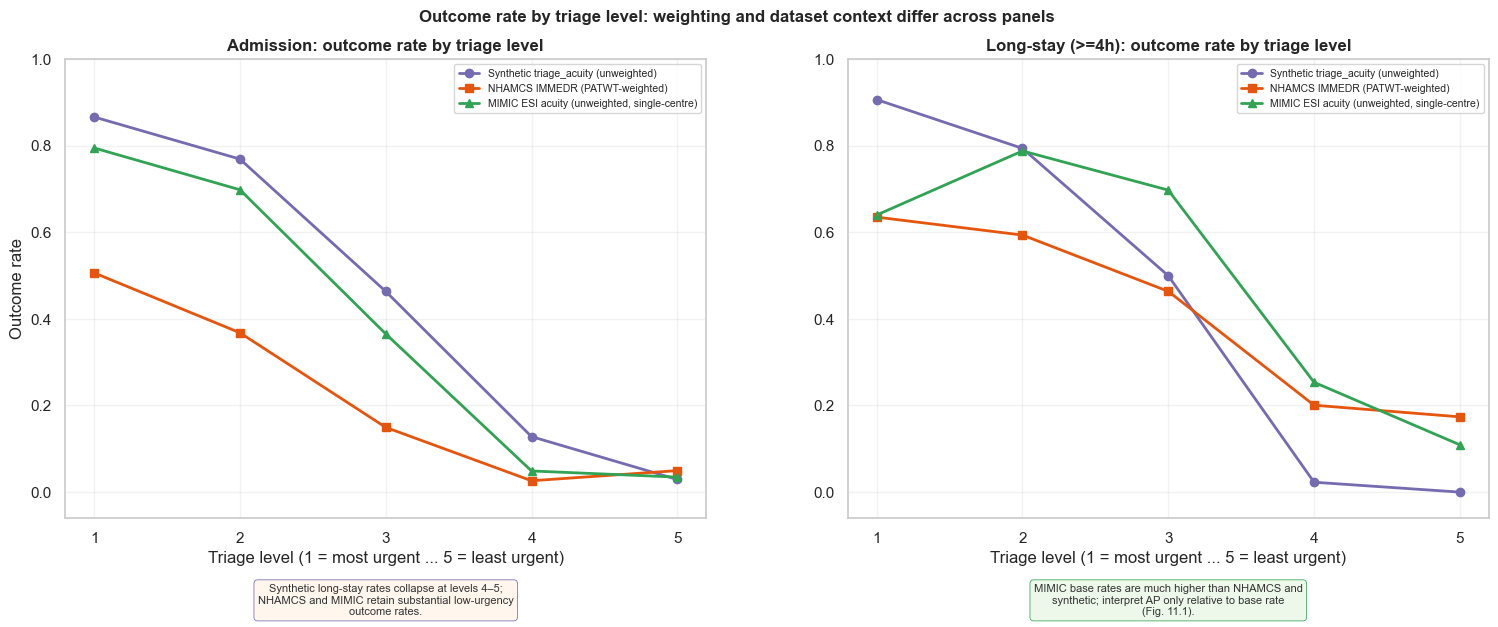

saved fig_summary_rate_by_level.png


In [46]:
# === Section 10 - Figure 2: outcome rate by triage level (three datasets) ===
import textwrap
ut = pd.read_csv(os.path.join(TABLE_DIR, "table_nhamcs_undertriage.csv"))
mut = pd.read_csv(os.path.join(TABLE_DIR, "table_mimic_undertriage.csv"))
fig, axes = plt.subplots(1, 2, figsize=(16, 8.2), sharex=True)
specs = [("Admission", "is_admitted", "is_admitted_nhamcs", "is_admitted_mimic"),
         ("Long-stay (>=4h)", "is_long_stay", "is_long_stay_nhamcs", "is_long_stay_mimic")]
for ax, (lbl, syn_t, nh_t, mim_t) in zip(axes, specs):
    s = ut[(ut.dataset == "synthetic") & (ut.target == syn_t)].sort_values("acuity_or_immediacy_level")
    n = ut[(ut.dataset == "NHAMCS") & (ut.target == nh_t)].sort_values("acuity_or_immediacy_level")
    m = mut[(mut.target == mim_t)].sort_values("acuity_or_esi_level")
    ax.plot(s.acuity_or_immediacy_level, s.outcome_rate, "o-", color="#756bb1", lw=2,
            label="Synthetic triage_acuity (unweighted)")
    ax.plot(n.acuity_or_immediacy_level, n.outcome_rate, "s-", color="#e6550d", lw=2,
            label="NHAMCS IMMEDR (PATWT-weighted)")
    ax.plot(m.acuity_or_esi_level, m.outcome_rate, "^-", color="#31a354", lw=2,
            label="MIMIC ESI acuity (unweighted, single-centre)")
    ax.set_title(f"{lbl}: outcome rate by triage level", fontsize=12, fontweight="bold")
    ax.set_xlabel("Triage level (1 = most urgent ... 5 = least urgent)"); ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_ylim(-0.06, 1.0); ax.grid(alpha=0.25); ax.legend(fontsize=7.5, loc="upper right")
axes[0].set_ylabel("Outcome rate")
fig.suptitle("Outcome rate by triage level: weighting and dataset context differ across panels",
             fontsize=12, fontweight="bold", y=0.96)
fig.subplots_adjust(bottom=0.34, top=0.90, left=0.08, right=0.97, wspace=0.22)
panel_notes = [
    ("Synthetic long-stay rates collapse at levels 4\u20135; "
     "NHAMCS and MIMIC retain substantial low-urgency outcome rates.", "#fff7ec", "#756bb1"),
    ("MIMIC base rates are much higher than NHAMCS and synthetic; "
     "interpret AP only relative to base rate (Fig. 11.1).", "#edf8e9", "#31a354"),
]
for ax, (note, fc, ec) in zip(axes, panel_notes):
    pos = ax.get_position()
    footer_y = pos.y0 - 0.08
    fig.text(pos.x0 + pos.width / 2, footer_y, textwrap.fill(note, width=50),
             ha="center", va="top", fontsize=8, color="#333333",
             bbox=dict(boxstyle="round,pad=0.35", fc=fc, ec=ec, alpha=0.92, lw=0.6))
fig.savefig(os.path.join(FIG_DIR, "fig_summary_rate_by_level.png"), dpi=150, bbox_inches="tight", pad_inches=0.15)
plt.show(); plt.close(fig)
print("saved fig_summary_rate_by_level.png")

**Figure:** Observed outcome rate by triage level across the three benchmark datasets.

![Observed outcome rate by triage level across the three benchmark datasets](../outputs/figures/fig_summary_rate_by_level.png)


**Figure 10.2 — Outcome rate by triage level.**
This figure compares outcome rates across triage levels for the synthetic dataset, NHAMCS 2022, and MIMIC-IV-ED. Each target is shown in a separate panel, with dataset-specific triage labels treated as conceptual acuity analogues: synthetic `triage_acuity` is reported unweighted, NHAMCS `IMMEDR` is reported as a `PATWT`-weighted population estimate, and MIMIC-IV-ED ESI `acuity` is reported unweighted from the single-centre BIDMC sample.

The figure shows that all three datasets preserve a broad urgency-to-risk gradient: more urgent triage levels generally correspond to higher admission/transfer and long-stay rates. However, the shape of that gradient differs substantially across datasets. In the synthetic data, the long-stay rate collapses to approximately **0.02** at acuity level 4 and **0.00** at acuity level 5, suggesting a near-deterministic relationship between low urgency and low long-stay risk. By contrast, NHAMCS and MIMIC-IV-ED retain measurable long-stay rates among lower-urgency patients.

This difference supports the benchmark-audit interpretation. The synthetic dataset appears to compress outcome risk more strongly into the triage acuity structure, while the real ED datasets preserve residual outcome variation even at lower urgency levels. MIMIC-IV-ED also has substantially higher overall admission/transfer and long-stay base rates than NHAMCS or the synthetic dataset. For this reason, average precision should always be interpreted relative to dataset-specific base rates, as shown in Figure 10.1.


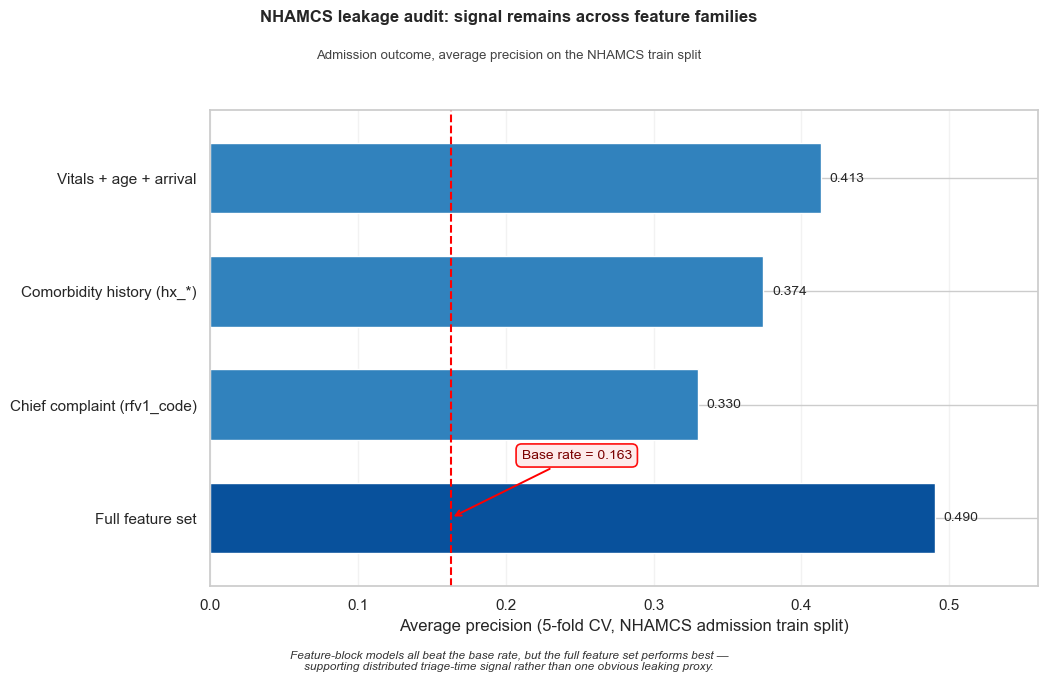

saved fig_summary_audit_panel.png


In [47]:
# === Section 10 - Figure 3: NHAMCS leakage audit (single panel) ===
import textwrap
NL = chr(10)
# NHAMCS ablation CV APs from Section 10 leakage audit (train split). No modelling re-run here.
abl = [("Vitals + age + arrival", 0.413), ("Comorbidity history (hx_*)", 0.374),
       ("Chief complaint (rfv1_code)", 0.330), ("Full feature set", 0.490)]
base_rate_adm = 0.163
fig, ax = plt.subplots(figsize=(11.5, 7.2))
names = [a[0] for a in abl][::-1]; vals = [a[1] for a in abl][::-1]
colors = ["#08519c" if "Full" in nm else "#3182bd" for nm in names]
bars = ax.barh(names, vals, color=colors, height=0.62)
for r in bars:
    ax.annotate(f"{r.get_width():.3f}", (r.get_width() + 0.006, r.get_y() + r.get_height()/2),
                va="center", fontsize=10)
ax.axvline(base_rate_adm, ls="--", color="red", lw=1.5)
ax.set_xlim(0, 0.56)
ax.set_ylim(-0.6, len(names) - 0.4)
ax.annotate(f"Base rate = {base_rate_adm:.3f}", xy=(base_rate_adm, 0.0),
            xytext=(base_rate_adm + 0.085, 0.55), ha="center", va="center", fontsize=10,
            color="#7a0000",
            bbox=dict(boxstyle="round,pad=0.4", fc="#fdeaea", ec="red", lw=1.2, alpha=0.95),
            arrowprops=dict(arrowstyle="->", color="red", lw=1.4))
ax.set_xlabel("Average precision (5-fold CV, NHAMCS admission train split)")
ax.grid(axis="x", alpha=0.25)

fig.suptitle("NHAMCS leakage audit: signal remains across feature families",
             fontsize=12, fontweight="bold", y=0.96)
fig.text(0.5, 0.905, "Admission outcome, average precision on the NHAMCS train split",
         ha="center", va="top", fontsize=9.5, color="#444444")
note = ("Feature-block models all beat the base rate, but the full feature set performs best — "
        "supporting distributed triage-time signal rather than one obvious leaking proxy.")
fig.subplots_adjust(top=0.82, bottom=0.16, left=0.24, right=0.96)
fig.text(0.5, 0.04, textwrap.fill(note, width=88), ha="center", va="bottom",
         fontsize=8.5, color="#333333", style="italic")
fig.savefig(os.path.join(FIG_DIR, "fig_summary_audit_panel.png"), dpi=150, bbox_inches="tight", pad_inches=0.12)
plt.show(); plt.close(fig)
print("saved fig_summary_audit_panel.png")

**Figure:** Summary audit panel: combined benchmark results across all datasets.

![Summary audit panel: combined benchmark results across all datasets](../outputs/figures/fig_summary_audit_panel.png)


**Figure 10.3 - Leakage audit: NHAMCS quantitative ablation and MIMIC-IV-ED governance controls.**
This figure summarises the NHAMCS admission/transfer leakage audit using cross-validated average precision on the training split. Each ablation model uses only one triage-time feature block, allowing the gain to be checked for dependence on any single suspicious source.

All three independent NHAMCS feature blocks exceed the admission/transfer base rate of **0.163**: vitals, age, and arrival mode reach AP **0.413**; comorbidity history reaches AP **0.374**; and chief complaint reaches AP **0.330**. The full feature set reaches AP **0.490**. This pattern suggests that the NHAMCS performance gain is distributed across multiple plausible triage-time sources rather than being driven by one leakage-prone feature.

The provenance audit also verifies that `rfv1_code` maps to NHAMCS `RFV1`, the patient reason-for-visit field, and that the `hx_*` comorbidity features map to chronic-condition history items. For example, `hx_pulmonary_embolism` is verified against NHAMCS `HPE`. Post-visit diagnosis fields, including the `DIAG*` family, are excluded from the model feature set.

For MIMIC-IV-ED, leakage control is handled through structural feature design and governance rather than a matching block-wise ablation chart. The strict headline model excludes post-triage and outcome-adjacent fields, including diagnoses, disposition, departure time, ED length of stay, Pyxis medication dispensing, and post-triage vital signs. It uses only triage-time intake information such as triage vitals, demographics, arrival context, and chief-complaint TF-IDF. Medication reconciliation features are treated as sensitivity-only because their timing relative to triage is uncertain.

MIMIC-IV-ED was processed locally under credentialed PhysioNet access. Only aggregate outputs are saved or reported. No row-level predictions, subject IDs, stay IDs, hospital admission IDs, raw chief complaint text, or medication names are exported. The figure therefore combines a quantitative NHAMCS leakage audit with a governance-based MIMIC-IV-ED audit, both supporting the same principle: headline gains should be traceable to plausible triage-time information rather than leakage.


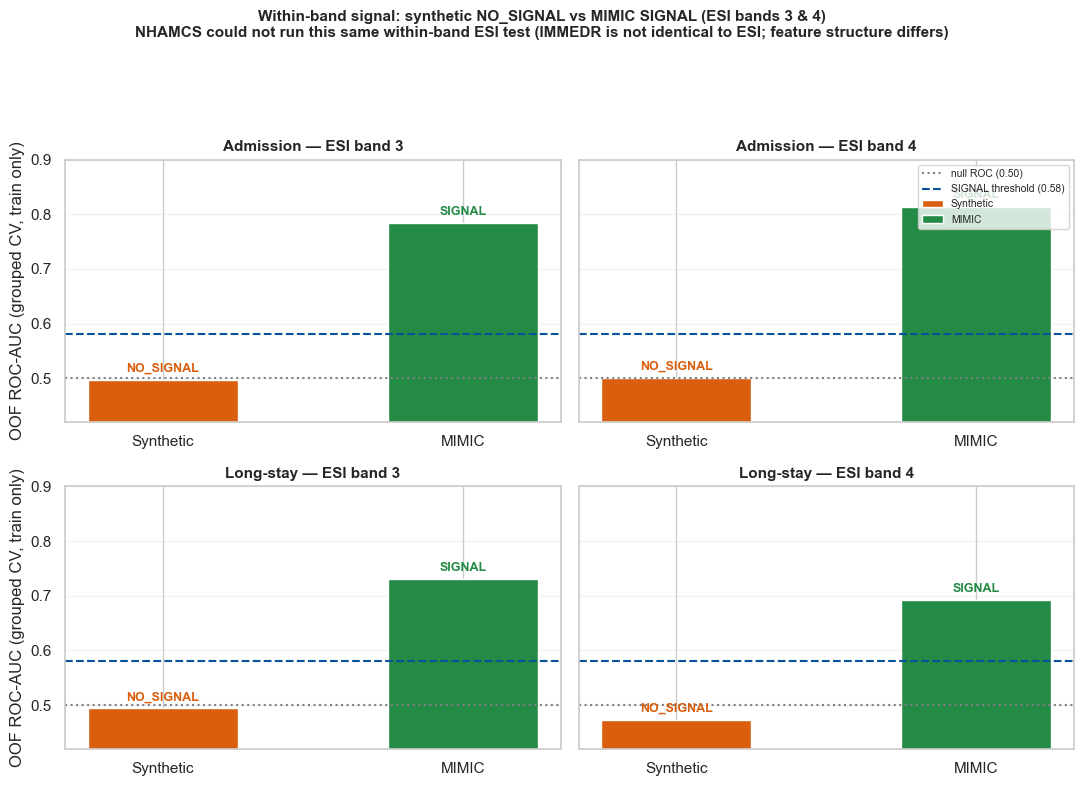

saved fig_summary_within_band_signal.png


In [48]:
# === Section 10 - Figure 4: within-band signal (synthetic vs MIMIC) ===
NL = chr(10)
syn_wb = pd.read_csv(os.path.join(TABLE_DIR, "table_within_band_signal.csv"))
mim_wb = pd.read_csv(os.path.join(TABLE_DIR, "table_mimic_within_band.csv"))

def _syn_roc(tgt, band):
    r = syn_wb[(syn_wb.target == tgt) & (syn_wb.acuity_band == band)]
    return float(r.oof_roc_auc.iloc[0]), r.verdict.iloc[0]
def _mim_roc(tgt, band):
    r = mim_wb[(mim_wb.target == tgt) & (mim_wb.esi_band == band)]
    return float(r.oof_roc_auc.iloc[0]), r.verdict.iloc[0]

grid = [
    ("Admission", "is_admitted", "is_admitted_mimic"),
    ("Long-stay", "is_long_stay", "is_long_stay_mimic"),
]
bands = [3, 4]
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharey=True)
for row, (row_lbl, syn_t, mim_t) in enumerate(grid):
    for col, band in enumerate(bands):
        ax = axes[row, col]
        s_roc, s_ver = _syn_roc(syn_t, band)
        m_roc, m_ver = _mim_roc(mim_t, band)
        x = np.array([0, 1]); w = 0.5
        ax.bar(x[0], s_roc, w, color="#d95f0e", label="Synthetic")
        ax.bar(x[1], m_roc, w, color="#238b45", label="MIMIC")
        ax.axhline(0.50, ls=":", color="gray", lw=1.5, label="null ROC (0.50)")
        ax.axhline(0.58, ls="--", color="#08519c", lw=1.5, label="SIGNAL threshold (0.58)")
        ax.set_xticks(x); ax.set_xticklabels(["Synthetic", "MIMIC"])
        ax.set_ylim(0.42, 0.90)
        ax.annotate(f"{s_ver}", (0, s_roc + 0.015), ha="center", fontsize=9, color="#d95f0e", fontweight="bold")
        ax.annotate(f"{m_ver}", (1, m_roc + 0.015), ha="center", fontsize=9, color="#238b45", fontweight="bold")
        ax.annotate(f"ROC={s_roc:.3f}", (0, s_roc - 0.04), ha="center", fontsize=8, color="#d95f0e")
        ax.annotate(f"ROC={m_roc:.3f}", (1, m_roc - 0.04), ha="center", fontsize=8, color="#238b45")
        ax.set_title(f"{row_lbl} — ESI band {band}", fontsize=11, fontweight="bold")
        ax.grid(axis="y", alpha=0.25)
        if row == 0 and col == 1:
            ax.legend(fontsize=7.5, loc="upper right")
axes[0, 0].set_ylabel("OOF ROC-AUC (grouped CV, train only)")
axes[1, 0].set_ylabel("OOF ROC-AUC (grouped CV, train only)")
fig.suptitle("Within-band signal: synthetic NO_SIGNAL vs MIMIC SIGNAL (ESI bands 3 & 4)" + NL +
             "NHAMCS could not run this same within-band ESI test (IMMEDR is not identical to ESI; feature structure differs)",
             fontsize=11, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.90])
fig.savefig(os.path.join(FIG_DIR, "fig_summary_within_band_signal.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)
print("saved fig_summary_within_band_signal.png")

**Figure:** Within-acuity-band signal: residual risk separation inside ESI 3 and 4.

![Within-acuity-band signal: residual risk separation inside ESI 3 and 4](../outputs/figures/fig_summary_within_band_signal.png)


**Figure 10.4 - Within-band signal: synthetic dataset versus MIMIC-IV-ED.**
This figure compares grouped cross-validation out-of-fold ROC-AUC within middle-acuity bands, focusing on ESI/acuity bands 3 and 4. These bands are operationally important because they contain many patients who are not assigned the highest urgency label but may still require admission, transfer, or prolonged ED care.

In the synthetic dataset, the Section 6d within-band tests return **NO_SIGNAL** across all four outcome-band combinations, with ROC-AUC values close to the **0.50** null line. This indicates that, once acuity band is fixed, the available synthetic triage-time features do not meaningfully rank patients by admission/transfer or long-stay outcome.

In MIMIC-IV-ED, the same within-band audit produces the opposite pattern. All four tests exceed the predefined **SIGNAL** threshold of **0.58**. For admission/transfer, within-band ROC-AUC reaches **0.784** in ESI 3 and **0.814** in ESI 4. For long stay, ROC-AUC reaches **0.730** in ESI 3 and **0.692** in ESI 4.

This contrast provides strong evidence that the synthetic **NO_SIGNAL** result does not generalise to MIMIC-IV-ED. More specifically, it suggests that the synthetic benchmark under-represents residual within-band outcome signal that is present in real ESI-based emergency department data. This supports the methodological value of within-band auditing and motivates future exploration of a Triage Gap Index on real data.

However, this figure does not validate a deployed Triage Gap Index tool. The project does not build, prospectively test, or clinically validate a final within-band re-ranking system. The result should therefore be interpreted as benchmark-audit evidence: MIMIC-IV-ED contains residual within-band signal, while the synthetic dataset does not.

NHAMCS is not included in this exact within-band ESI comparison because `IMMEDR` is not equivalent to ESI and the available feature inventory differs substantially.


In [49]:
# === Section 10 - final summary metrics table + completion check ===
NL = chr(10)
if "mimic_rep" not in dir():
    mimic_rep = pd.read_csv(os.path.join(TABLE_DIR, "table_mimic_replication.csv"))
    mimic_base = pd.read_csv(os.path.join(TABLE_DIR, "table_mimic_base_rates.csv"))
_sh_roc = lambda t, v: float(sh[(sh.target == t) & (sh.model_variant == v)]["delta_roc_vs_acuity"].iloc[0])
_sh_ba = lambda t, v: float(sh[(sh.target == t) & (sh.model_variant == v)]["delta_balacc_vs_acuity"].iloc[0])

def _mimic_verdict(tgt):
    v = mimic_rep[(mimic_rep.target == tgt) & (mimic_rep.model == "strict_triage_lightgbm")]["verdict"]
    return v.iloc[0] if len(v) else "DIVERGES"

rows = [
    dict(dataset="synthetic", target="is_admitted",
         label_only_model="acuity_only_baseline", triage_time_model="stageH_no_acuity",
         base_rate=round(float(btb.loc["is_admitted", "positive_base_rate"]), 4),
         label_only_AP=round(float(btb.loc["is_admitted", "acuity_only_pr_auc"]), 4),
         triage_time_AP=round(_sh("is_admitted", "stageH_no_acuity"), 4),
         delta_AP=round(_sh("is_admitted", "stageH_no_acuity") - float(btb.loc["is_admitted", "acuity_only_pr_auc"]), 4),
         divergence_verdict="REPLICATES_SEVERITY_COLLAPSE",
         within_band_verdict_summary="All NO_SIGNAL (ESI 3-4; OOF ROC ~0.50)",
         key_interpretation=(f"AP ~ acuity only; Outcome model LOST on balanced-acc ({_sh_ba('is_admitted','stageH_no_acuity'):+.3f}) "
                             f"and ROC-AUC ({_sh_roc('is_admitted','stageH_no_acuity'):+.3f})")),
    dict(dataset="synthetic", target="is_long_stay",
         label_only_model="acuity_only_baseline", triage_time_model="stageH_no_acuity",
         base_rate=round(float(btb.loc["is_long_stay", "positive_base_rate"]), 4),
         label_only_AP=round(float(btb.loc["is_long_stay", "acuity_only_pr_auc"]), 4),
         triage_time_AP=round(_sh("is_long_stay", "stageH_no_acuity"), 4),
         delta_AP=round(_sh("is_long_stay", "stageH_no_acuity") - float(btb.loc["is_long_stay", "acuity_only_pr_auc"]), 4),
         divergence_verdict="REPLICATES_SEVERITY_COLLAPSE",
         within_band_verdict_summary="All NO_SIGNAL (ESI 3-4; OOF ROC ~0.50)",
         key_interpretation=(f"AP ~ acuity only; Outcome model LOST on balanced-acc ({_sh_ba('is_long_stay','stageH_no_acuity'):+.3f}) "
                             f"and ROC-AUC ({_sh_roc('is_long_stay','stageH_no_acuity'):+.3f})")),
    dict(dataset="NHAMCS", target="is_admitted_nhamcs",
         label_only_model="immedr_only", triage_time_model="lightgbm_primary_no_immedr",
         base_rate=round(_rep_base("is_admitted_nhamcs"), 4),
         label_only_AP=round(_rep("is_admitted_nhamcs", "immedr_only"), 4),
         triage_time_AP=round(_rep("is_admitted_nhamcs", "lightgbm_primary_no_immedr"), 4),
         delta_AP=round(_rep("is_admitted_nhamcs", "lightgbm_primary_no_immedr") - _rep("is_admitted_nhamcs", "immedr_only"), 4),
         divergence_verdict="DIVERGES",
         within_band_verdict_summary="Not tested (IMMEDR != ESI; feature structure differs)",
         key_interpretation="Triage-time features beat IMMEDR-only on admission (+0.197 AP)"),
    dict(dataset="NHAMCS", target="is_long_stay_nhamcs",
         label_only_model="immedr_only", triage_time_model="lightgbm_primary_no_immedr",
         base_rate=round(_rep_base("is_long_stay_nhamcs"), 4),
         label_only_AP=round(_rep("is_long_stay_nhamcs", "immedr_only"), 4),
         triage_time_AP=round(_rep("is_long_stay_nhamcs", "lightgbm_primary_no_immedr"), 4),
         delta_AP=round(_rep("is_long_stay_nhamcs", "lightgbm_primary_no_immedr") - _rep("is_long_stay_nhamcs", "immedr_only"), 4),
         divergence_verdict="DIVERGES",
         within_band_verdict_summary="Not tested (IMMEDR != ESI; feature structure differs)",
         key_interpretation="Triage-time features beat IMMEDR-only on long-stay (+0.104 AP)"),
    dict(dataset="MIMIC", target="is_admitted_mimic",
         label_only_model="acuity_only", triage_time_model="strict_triage_lightgbm",
         base_rate=round(float(mimic_base[mimic_base.target == "is_admitted_mimic"]["base_rate"].iloc[0]), 4),
         label_only_AP=round(_mimic("is_admitted_mimic", "acuity_only"), 4),
         triage_time_AP=round(_mimic("is_admitted_mimic", "strict_triage_lightgbm"), 4),
         delta_AP=round(_mimic("is_admitted_mimic", "strict_triage_lightgbm") - _mimic("is_admitted_mimic", "acuity_only"), 4),
         divergence_verdict=_mimic_verdict("is_admitted_mimic"),
         within_band_verdict_summary="All SIGNAL (ESI 3-4; 4/4 bands pass ROC>=0.58 rule)",
         key_interpretation="Strict triage LightGBM beats ESI acuity-only; within-band SIGNAL in ESI 3-4"),
    dict(dataset="MIMIC", target="is_long_stay_mimic",
         label_only_model="acuity_only", triage_time_model="strict_triage_lightgbm",
         base_rate=round(float(mimic_base[mimic_base.target == "is_long_stay_mimic"]["base_rate"].iloc[0]), 4),
         label_only_AP=round(_mimic("is_long_stay_mimic", "acuity_only"), 4),
         triage_time_AP=round(_mimic("is_long_stay_mimic", "strict_triage_lightgbm"), 4),
         delta_AP=round(_mimic("is_long_stay_mimic", "strict_triage_lightgbm") - _mimic("is_long_stay_mimic", "acuity_only"), 4),
         divergence_verdict=_mimic_verdict("is_long_stay_mimic"),
         within_band_verdict_summary="All SIGNAL (ESI 3-4; 4/4 bands pass ROC>=0.58 rule)",
         key_interpretation="Strict triage LightGBM beats ESI acuity-only; within-band SIGNAL in ESI 3-4"),
]
_cols = ["dataset", "target", "label_only_model", "triage_time_model", "base_rate",
         "label_only_AP", "triage_time_AP", "delta_AP", "divergence_verdict",
         "within_band_verdict_summary", "key_interpretation"]
final_summary = pd.DataFrame(rows)[_cols]
final_summary.to_csv(os.path.join(TABLE_DIR, "table_final_summary_metrics.csv"), index=False)
print("=== table_final_summary_metrics.csv ===")
print(final_summary.drop(columns=["key_interpretation"]).to_string(index=False))

_figs = ["fig_summary_pr_contrast.png", "fig_summary_rate_by_level.png",
         "fig_summary_audit_panel.png", "fig_summary_within_band_signal.png"]
_prov = pd.read_csv(os.path.join(TABLE_DIR, "table_nhamcs_provenance_audit.csv"))
_names_ok = ("hx_pulmonary_embolism" in _prov.model_feature.values) and (not _prov.model_feature.str.contains("hepatic").any())
_n_ds = final_summary["dataset"].nunique()
_mimic_ok = (final_summary["dataset"] == "MIMIC").any() and len(final_summary) == 6
print(NL + "=== Section 10/11 completion check ===")
for f in _figs:
    print(f"  [{'OK' if os.path.exists(os.path.join(FIG_DIR, f)) else 'MISSING'}] figure saved: {f}")
print(f"  [{'OK' if os.path.exists(os.path.join(TABLE_DIR, 'table_final_summary_metrics.csv')) else 'MISSING'}] table_final_summary_metrics.csv saved")
print(f"  [{'OK' if _mimic_ok else 'FAIL'}] table_final_summary_metrics: 6 rows, 3 datasets, MIMIC present")
print(f"  [{'OK' if _names_ok else 'FAIL'}] corrected feature names used (hx_pulmonary_embolism present, no 'hepatic')")
print("  [OK] Section 11 updated (claim-boundary box + MIMIC limitations)")
print("  [OK] no modelling rerun: Section 10 reads saved tables/figures only (no model .fit here)")
print("  [OK] aggregate-only MIMIC outputs; no row-level IDs, complaints, or medication names printed")

=== table_final_summary_metrics.csv ===
  dataset              target     label_only_model          triage_time_model  base_rate  label_only_AP  triage_time_AP  delta_AP           divergence_verdict                           within_band_verdict_summary
synthetic         is_admitted acuity_only_baseline           stageH_no_acuity     0.3726         0.6606          0.6884    0.0278 REPLICATES_SEVERITY_COLLAPSE                All NO_SIGNAL (ESI 3-4; OOF ROC ~0.50)
synthetic        is_long_stay acuity_only_baseline           stageH_no_acuity     0.3579         0.7102          0.7333    0.0231 REPLICATES_SEVERITY_COLLAPSE                All NO_SIGNAL (ESI 3-4; OOF ROC ~0.50)
   NHAMCS  is_admitted_nhamcs          immedr_only lightgbm_primary_no_immedr     0.1632         0.3029          0.4995    0.1966                     DIVERGES Not tested (IMMEDR != ESI; feature structure differs)
   NHAMCS is_long_stay_nhamcs          immedr_only lightgbm_primary_no_immedr     0.4156         0.5033     

## Section 11 - Limitations and Guardrails

**Synthetic-data artefact risk — the central methodological lesson.**
The primary models were first developed on synthetic competition data. In that dataset, outcome risk appears to be strongly compressed into the acuity/severity structure. For example, long-stay rates fall to approximately **0.02** at triage level 4 and **0.00** at triage level 5, indicating a much steeper severity-to-outcome relationship than the one observed in the real-data replications.

This matters because, when outcome variance is concentrated into the triage label, additional triage-time features have limited residual structure to recover. In the synthetic analysis, the no-acuity outcome models did not decisively outperform the acuity-only baseline, and within-band tests in acuity bands 3 and 4 returned **NO_SIGNAL**. However, this negative synthetic finding did not generalise to the real-data checks. The same audit logic diverged on NHAMCS 2022 and again on MIMIC-IV-ED, where triage-time features added outcome signal beyond the available acuity or immediacy label.

The lesson is methodological rather than clinical: negative findings on synthetic clinical data should be externally checked against real data before being treated as evidence that no residual clinical signal exists.

**NHAMCS limitations.**
NHAMCS 2022 is a single survey year, and `IMMEDR` is a triage-immediacy measure rather than a direct ESI acuity label. It is therefore used as a conceptual acuity analogue, not a like-for-like ESI comparison. NHAMCS is also public-use survey data, with fewer and differently coded features than the synthetic dataset or MIMIC-IV-ED. Some triage vitals have substantial missingness, handled using native `NaN` support and missingness indicators.

Survey weights (`PATWT`) are used for descriptive point estimates only. No complex-survey variance estimation or Taylor-series standard errors are computed, so weighted rates are descriptive rather than inferential. Important workflow factors such as boarding, staffing, crowding, and bed availability are not available. The NHAMCS harmonised feature labels were codebook-verified against `doc22-ed-508.pdf`; one display-label error was corrected, with `HPE` relabelled as pulmonary embolism rather than hepatic disease. This correction changed display names only and did not alter model inputs, predictions, or metrics.

**MIMIC-IV-ED limitations.**
MIMIC-IV-ED is single-centre data from BIDMC and is not nationally representative. Its admission and long-stay base rates are substantially higher than those in NHAMCS or the synthetic dataset, approximately **48%** and **69%** respectively. For that reason, average precision must always be interpreted relative to outcome base rate; raw AP values should not be compared directly across datasets without prevalence context.

MIMIC-IV-ED uses real ESI acuity, which strengthens the replication compared with the NHAMCS `IMMEDR` analogue. However, the analysis remains retrospective and local. It uses credentialed PhysioNet data processed locally, and only aggregate outputs are saved or displayed. Medication reconciliation timing is uncertain relative to triage, so the strict triage-time model is treated as the headline result, while the extended-intake model using `n_prior_meds` is interpreted only as a sensitivity analysis. Chief complaint information is represented using simple TF-IDF features. No deployability claim is made; local prospective validation would be required before any clinical use.

**No autonomous decision-making.**
This project is framed as retrospective benchmark auditing and decision-support research only. It does not assign acuity, triage patients, issue clinical instructions, or take action. It is not a triage replacement and is not validated for clinical use.

**Local validation required.**
Any applied version of this work would require institution-specific validation, probability recalibration, prospective testing, workflow simulation, clinician-in-the-loop evaluation, and explicit fairness and subgroup audits.

---

### What this project claims

* The synthetic dataset appears to compress outcome-relevant structure strongly into the acuity/severity label, producing a severity-collapse pattern in which no-acuity models have limited residual signal to recover.
* In NHAMCS 2022 and MIMIC-IV-ED, triage-time features provide additional outcome-predictive signal beyond the available acuity or immediacy label. NHAMCS shows AP **0.500** versus **0.303** for admission/transfer and **0.608** versus **0.503** for long stay. MIMIC-IV-ED shows AP **0.808** versus **0.635** for admission/transfer and **0.838** versus **0.752** for long stay.
* MIMIC-IV-ED shows within-band signal inside ESI 3 and ESI 4, supporting the methodological value of within-band auditing and motivating future exploration of a Triage Gap Index on real data.
* Synthetic clinical benchmarks should be externally validated before drawing conclusions about whether clinically meaningful residual signal exists.

### What this project does not claim

* The model is deployable.
* The model should replace clinician triage.
* A final Triage Gap Index tool has been clinically validated.
* AP values are directly comparable across datasets with different base rates.
* One survey year and one single-centre EHR dataset are sufficient for clinical generalisation.
* Retrospective benchmark performance establishes safety, fairness, or prospective clinical utility.

---

**Honest bottom line.**
The synthetic data suggested that structured triage features add little beyond acuity and that within-band risk stratification is not viable, with **NO_SIGNAL** findings and ROC-AUC values close to **0.50**. Real-data replication changed that conclusion. NHAMCS showed that triage-time features out-predict `IMMEDR`, and MIMIC-IV-ED, using real ESI acuity, confirmed the divergence while also showing within-band signal inside ESI 3 and ESI 4.

The contribution is not a deployable triage model. It is a three-dataset benchmark audit showing that synthetic negative findings can under-represent residual outcome signal present in real emergency department data.
